In [1]:
%load_ext autoreload 
#hopefully this will reload the modules when they are changed specifically when i change the plotting modules
%autoreload 2

Plot distribution of m200
Save the plot data points in txt
Check what's wrong with bootstrap

In [ ]:
from myproject.redshiftGalaxyAnalysis import GalaxyAnalysis
from myproject.listRedshiftGalaxys import ListRedshiftGalaxy
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.compilingPlottinFunctions import asymetryPlots, getConsistentInconsistentPolarMRLPlots, getConsistentInconsistentAssymetryPlots

from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, NullLocator, MultipleLocator


In [3]:
allSnapshotEnums = SnapshotEnum.getAllSnapshots()
# allSnapshots = [snapshotEnum[0] for snapshotEnum in allSnapshotEnums]

#get rid of snapshots < 50:
allSnapshotEnums = [snapshotEnum for snapshotEnum in allSnapshotEnums if snapshotEnum[0] >= 50]
allSnapshots = [snapshotEnum[0] for snapshotEnum in allSnapshotEnums]
print(allSnapshots)

[99, 91, 84, 78, 72, 67, 59, 50]


In [4]:
mass_bin_labels = [
    '$1e13<M_{200}<1e13.5$',
    '$1e13.5<M_{200}<1e14$',
    '$1e14<M_{200}<1e14.5$',
    '$1e14.5<M_{200}<1e15$',
    '$M_{200}>1e15$',
]

In [5]:
#mass bin colors to keep consistent across all plots
mass_bin_colors = [
    '#1f77b4',  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
]

In [6]:
polarXlabel = r"Polar angle separation, $\Delta(\phi)$ [degrees]"
polarYlabel = r"Probability, P(\Delta \phi)"

mrlXlabel = r"Mean Resultant Length, $\overline{R}$"
mrlYlabel = r"Probability, P($\overline{R}$)"

m200label = r"$\log{\frac{M_{200c}}{M_{\odot}}}$"

In [7]:
numSamples = 10000
num_samples = numSamples

In [8]:
listRedshiftGalaxyAnalysis = ListRedshiftGalaxy()
listRedshiftGalaxyAnalysis.initializeAllGalaxyAnalysis(snapshot_enums=allSnapshots, simulation='TNG300-1, TNG-Cluster', luminosityType='Default', generalErrorbar='poisson', generalRewrite=True)
# galaxyAnalysisZ0 = GalaxyAnalysis(generalRewrite=True)

Progress: 3732/3732
Loaded 3732 galaxy groups from HDF5.
Progress: 352/352
Loaded 352 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
Progress: 3707/3707g Galaxy Group ID 4084 / 4084
Loaded 3707 galaxy groups from HDF5.
Progress: 352/352
Loaded 352 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p1/data/galaxy_data_TNG300-1_.hdf5
Progress: 3643/3643g Galaxy Group ID 4059 / 4059
Loaded 3643 galaxy groups from HDF5.
Progress: 352/352
Loaded 352 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p2/data/galaxy_data_TNG300-1_.hdf5
Progress: 3557/3557g Galaxy Group ID 3995 / 3995
Loaded 3557 galaxy groups from HDF5.
Progress: 360/360
Loaded 360 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p3/data/galaxy_data_TNG300-1_.hdf5
Progress: 3388/3388g Galaxy Group ID 3917 / 3917
Loaded 3388 galaxy groups fr

## what is causing mismatch of gg numbers in each mass group

In [10]:
#print num of clusters and satellites in each snapshot and mass bin:
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup


for snapshotEnum in allSnapshotEnums:
    snapshot = snapshotEnum[0]
    print(f"Snapshot: {snapshot}")
    galaxyAnalysis = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot)
    mass_bins : list[ListGalaxyGroup] = [
        galaxyAnalysis.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysis.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysis.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysis.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysis.filtered_gt15_list_of_galaxy_groups,
    ]
    for mass_bin, mass_bin_label in zip(mass_bins, mass_bin_labels):
        num_clusters = len(mass_bin.getAllGalaxyGroups())
        num_satellites = sum([len(galaxy_group.getSatelliteSubhalos()) for galaxy_group in mass_bin.getAllGalaxyGroups()])
        print(f" Mass bin: {mass_bin_label}, Num clusters: {num_clusters}, Num satellites: {num_satellites}")

Snapshot: 99
 Mass bin: $1e13<M_{200}<1e13.5$, Num clusters: 2586, Num satellites: 22426
 Mass bin: $1e13.5<M_{200}<1e14$, Num clusters: 866, Num satellites: 22694
 Mass bin: $1e14<M_{200}<1e14.5$, Num clusters: 292, Num satellites: 22543
 Mass bin: $1e14.5<M_{200}<1e15$, Num clusters: 242, Num satellites: 52867
 Mass bin: $M_{200}>1e15$, Num clusters: 98, Num satellites: 47946
Snapshot: 91
 Mass bin: $1e13<M_{200}<1e13.5$, Num clusters: 2585, Num satellites: 24093
 Mass bin: $1e13.5<M_{200}<1e14$, Num clusters: 872, Num satellites: 24210
 Mass bin: $1e14<M_{200}<1e14.5$, Num clusters: 291, Num satellites: 24832
 Mass bin: $1e14.5<M_{200}<1e15$, Num clusters: 244, Num satellites: 56008
 Mass bin: $M_{200}>1e15$, Num clusters: 67, Num satellites: 34314
Snapshot: 84
 Mass bin: $1e13<M_{200}<1e13.5$, Num clusters: 2587, Num satellites: 25883
 Mass bin: $1e13.5<M_{200}<1e14$, Num clusters: 831, Num satellites: 24211
 Mass bin: $1e14<M_{200}<1e14.5$, Num clusters: 299, Num satellites: 26614

In [9]:
#for snapshot 99, check how many subhalos have non nan joining redshifts compared to nan joining redshifts:
galaxyAnalysis = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
# loaded_list_of_galaxy = galaxyAnalysis.loaded_list_of_galaxy_groups
loaded_list_of_galaxy = galaxyAnalysis.filtered_gt14_list_of_galaxy_groups
num_subhalos = np.sum([len(galaxy_group.getSatelliteSubhalos()) for galaxy_group in loaded_list_of_galaxy.getAllGalaxyGroups()])
num_subhalos_nan_joining_redshifts = 0
num_subhalos_non_nan_joining_redshifts = 0
for galaxy_group in loaded_list_of_galaxy.getAllGalaxyGroups():
    for satellite_subhalo in galaxy_group.getSatelliteSubhalos():
        if np.isnan(satellite_subhalo.getJoiningRedshift()):
            num_subhalos_nan_joining_redshifts += 1
            # print(satellite_subhalo.getJoiningRedshift())
        else:
            num_subhalos_non_nan_joining_redshifts += 1
print(f"Snapshot 99: Num subhalos: {num_subhalos}, Num subhalos with nan joining redshifts: {num_subhalos_nan_joining_redshifts}, Num subhalos with non-nan joining redshifts: {num_subhalos_non_nan_joining_redshifts}")
print(f"Snapshot 99: Fraction of subhalos with nan joining redshifts: {num_subhalos_nan_joining_redshifts/num_subhalos}, Fraction of subhalos with non-nan joining redshifts: {num_subhalos_non_nan_joining_redshifts/num_subhalos}")

Snapshot 99: Num subhalos: 123356, Num subhalos with nan joining redshifts: 2161, Num subhalos with non-nan joining redshifts: 121195
Snapshot 99: Fraction of subhalos with nan joining redshifts: 0.017518402023411914, Fraction of subhalos with non-nan joining redshifts: 0.9824815979765881


# check snaphot compared to z=0

In [3]:
# galaxyAnalysisZ0 = GalaxyAnalysis(generalRewrite=True, sim='TNG-Cluster',luminosityType='Default')


Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052


In [16]:
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue  # too high redshift

    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    # redshifts.append(galaxyAnalysisSnapshot.snapshot_dic[snapshot[0]][1])
    galaxyAnalysisSnapshot.computeAllPlots()

In [ ]:
#check the number of galaxy groups loaded
print(f'Number of galaxy groups loaded: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f"Number of subhalos in GG 0: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(0).getNumSubhalos()}")
print(f"Number of subhalos in GG 10: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(10).getNumSubhalos()}")
# print(f"Number of subhalos in GG 912: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(912).getNumSubhalos()}")
rangeSat, allNumSat = galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getRangeOfNumSubhalos()
print(f' Range of satellites: {rangeSat}')
print(f' numer of sat == 1: {len(np.where(np.array(allNumSat) < 5)[0])}')

In [17]:
#from galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, save in a txt file
#save all galaxy groups with id, numSat, sum of flags for all satellites, mass, central mass, central flag, central r band, first satellite mass, first satellite flag, first satellite r band
with open('tng_cluster_galaxy_groups_info.txt', 'w') as f:
    f.write('id \t,numSat \t,sumFlags \t,mass \t,centralMass \t,centralFlag \t,centralRband \t,firstSatMass \t,firstSatFlag \t,firstSatRband \n')
    for i in range(galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()):
        gg = galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(i)
        id = gg.getGroupID()
        numSat = len(gg.getSatelliteSubhalos())
        sumFlags = np.sum([int(subhalo.getFlag()) for subhalo in gg.getSatelliteSubhalos()])
        mass = f'{gg.getMCrit200():.2e}'
        centralMass = f'{gg.getCentralSubhalo().getStellarMass():.2e}'
        centralFlag = gg.getCentralSubhalo().getFlag()
        centralRband = f'{gg.getCentralSubhalo().getDefaultRbandMagnitude():.2}'
        firstSatMass = f'{gg.getSatelliteSubhalos()[0].getStellarMass():.2e}'
        firstSatFlag = gg.getSatelliteSubhalos()[0].getFlag()
        firstSatRband = f'{gg.getSatelliteSubhalos()[0].getDefaultRbandMagnitude():.2}'
        f.write(f'{id} \t,{numSat} \t,{sumFlags} \t,{mass} \t,{centralMass} \t,{centralFlag} \t,{centralRband} \t,{firstSatMass} \t,{firstSatFlag} \t,{firstSatRband} \n')

In [ ]:
galaxyAnalysisZ0.computeAllPlots()

In [16]:
galaxyAnalysisZ0.setSnapshot(99, newsim='TNG-Cluster', luminosityType='Default')

Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052


In [ ]:

galaxyAnalysisZ0.MRLDistributionPlots()

In [ ]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    if snapshot[0] > 70:
        continue
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisZ0.setSnapshot(snapshot[0], newsim='TNG-Cluster', luminosityType='Default')
    galaxyAnalysisZ0.computeAllPlots()
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()

In [4]:
galaxyAnalysisZ0TNG300 = GalaxyAnalysis(generalRewrite=True, sim='TNG300-1',luminosityType='SDSS')

Progress: 3733/3733
Loaded 3733 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 3733
total to process: 3732alaxy Group ID 3733 / 3733
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732


In [15]:
print(galaxyAnalysisZ0.sim)

TNG300-1


Processing snapshot 99...
Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=z0p0, TNG-Cluster
Total Galaxy Groups to process: 913 with pairs : 18000496
Processing Subhalo 14/14 in Galaxy Group ID 4254241 with total pairs 91103841COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=0.0, TNG300-1
Total Galaxy Groups to process: 280 with pairs : 1753902
Processing Subhalo 7/550 in Galaxy Group ID 0 with total pairs 150975

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 54/54 in Galaxy Group ID 99 with total pairs 1431606Figure saved to: /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/plots/pairwise_polar_difference_cluster_vs_tng300z0_TNG-Cluster


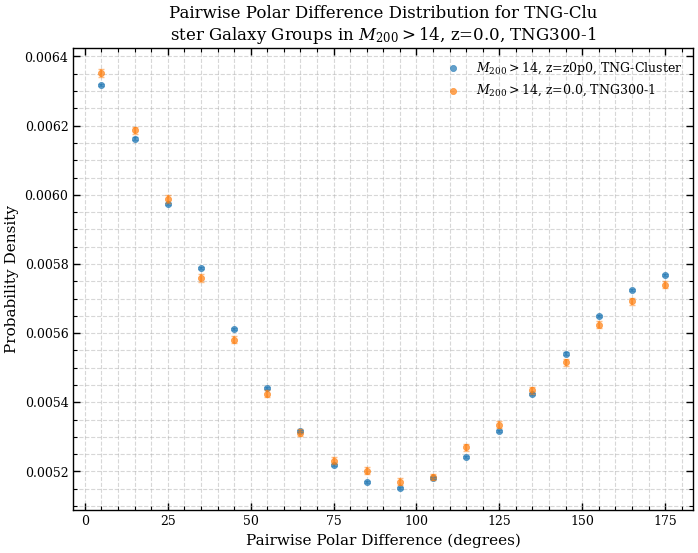

In [18]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] != 99: #already processed these snapshots
        continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")
    listRedshiftGG = []
    galaxyAnalysisZ0.setSnapshot(snapshot[0], newsim='TNG-Cluster', luminosityType='Default')
    groupList = []
    groupList.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG-Cluster'))
    groupList.append((galaxyAnalysisZ0TNG300.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z=0.0, TNG300-1'))
    listRedshiftGG.append(groupList)

    polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlay_polar_pairwise_across_redshifts(listRedshiftGG=listRedshiftGG, mrlOrPolar='polar', oneaxis=True)#, plotRows=2, plotCols=3)
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
    polar_ax.legend(loc='upper right')  # Add legend to the last subplot
    polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/pairwise_polar_difference_cluster_vs_tng300z0_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')

In [5]:
# make a plot of the number of galaxies per unit volume, per unit r-band magnitude.  That’s the luminosity function
L=205*1e3
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
import numpy as np
import matplotlib.pyplot as plt
def plot_luminosity_function(list_gg:ListGalaxyGroup, plot_dirc:str='', label=None,
                             color=None, hist_kwargs=None, ax=None):
    rmags = []
    for gg in list_gg.getAllGalaxyGroups():
        for galaxy in gg.getSubhalos():
            rmags.append(galaxy.getRbandMagnitude()) if label=='SDSS' else rmags.append(galaxy.getDefaultRbandMagnitude())
    
    bins ='auto'
    xlow=-23
    xhigh=-7
    bins = np.linspace(xlow, xhigh, 100)
    volume =L**3
    print(f"unit volume used: {volume}")
    # print(f"rmags: {rmags}")
    
    mags = np.asarray(rmags)
    hist, edges = np.histogram(mags, bins=bins)
    width = np.diff(edges)
    values = hist.astype(float) / width
    if volume is not None:
        values = values / float(volume)
    centers = edges[:-1] + 0.5 * width
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,5))
    hk = {} if hist_kwargs is None else dict(hist_kwargs)
    ax.step(centers, values, where='mid', label=label, color=color, **hk)
    ax.set_xlabel('r-band magnitude')
    ylabel = 'Number / mag / L^3'
    title = 'Luminosity Function'
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper right')
    ax.set_title(title)
    ax.invert_xaxis()
    ax.set_xlim(xlow, xhigh)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    return centers, values

unit volume used: 8615125000000000.0


(array([-22.91919192, -22.75757576, -22.5959596 , -22.43434343,
        -22.27272727, -22.11111111, -21.94949495, -21.78787879,
        -21.62626263, -21.46464646, -21.3030303 , -21.14141414,
        -20.97979798, -20.81818182, -20.65656566, -20.49494949,
        -20.33333333, -20.17171717, -20.01010101, -19.84848485,
        -19.68686869, -19.52525253, -19.36363636, -19.2020202 ,
        -19.04040404, -18.87878788, -18.71717172, -18.55555556,
        -18.39393939, -18.23232323, -18.07070707, -17.90909091,
        -17.74747475, -17.58585859, -17.42424242, -17.26262626,
        -17.1010101 , -16.93939394, -16.77777778, -16.61616162,
        -16.45454545, -16.29292929, -16.13131313, -15.96969697,
        -15.80808081, -15.64646465, -15.48484848, -15.32323232,
        -15.16161616, -15.        , -14.83838384, -14.67676768,
        -14.51515152, -14.35353535, -14.19191919, -14.03030303,
        -13.86868687, -13.70707071, -13.54545455, -13.38383838,
        -13.22222222, -13.06060606, -12.

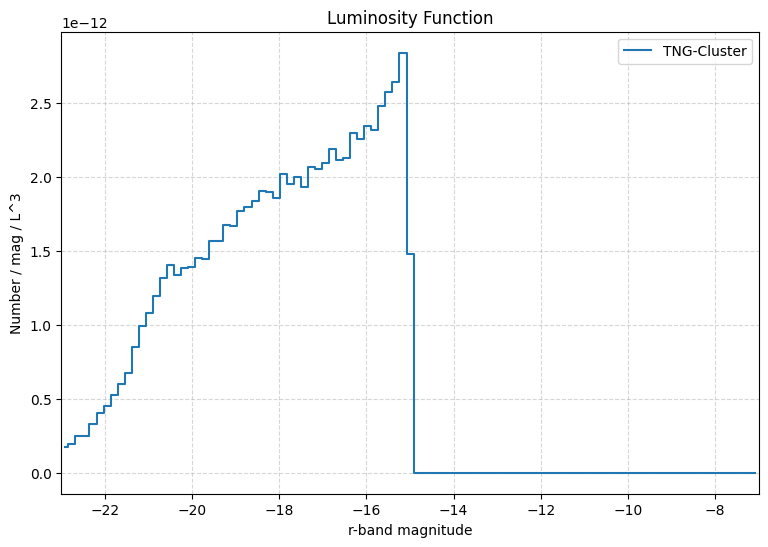

In [7]:
figSDSS, axSDSS = plt.subplots(figsize=(9,6))
plot_luminosity_function(galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, ax=axSDSS, label='TNG-Cluster')


In [9]:
%pwd

'/home/poulin.al/git/sat-lopsidedness/src/myproject'

In [10]:
#given a txt file that looks like:
# '''
# # # TNG-Cluster Catalog (see: https://www.tng-project.org/data/cluster/ and http://arxiv.org/abs/2311.06338)
# # Note: this table is dynamic, and new columns are frequently added. Requests for additions are welcome.
# # If you use quantities from this table, please also cite the relevant paper, when indicated for a column.
# # [352] halos, all properties at [z=0] unless specified otherwise.
# #
# # columns: 
# # [1] origID: Original Parent Halo ID (for reference only)
# # [2] haloID: TNG-Cluster Halo ID (in the group catalog)
# # [3] mhalo_200c: Halo mass within r200c [log M$_\odot$]
# # [4] mhalo_500c: Halo mass within r500c [log M$_\odot$]
# # [5] r200c: Halo radius r200c [Mpc]
# #
#    0        0 15.29 15.13 2.629 1.711 12.58 12.76 11.74 10.51 0.145   nan 45.28 -3.69  34.05 -0.79  8.11 0.49 854 502 248  62  CC  0.45  39.57  -0.93  1.69 0.14 0.64 0  0.23  0.67  0.55  0.60  0.45  0.72 
#    1   252455 15.40 15.27 2.871 1.912 12.16 12.49 11.37  9.35 0.126   nan 44.96 -3.48  11.91 -2.16  8.36 0.38 708 423 202  63 NCC 12.96 566.18  -2.20  0.19 0.01 0.12 0  1.91  2.81  1.84  1.35  1.75  1.93 
#    2   476245 15.16 14.99 2.378 1.541 12.16 12.40 11.82 10.17 0.132   nan 44.59 -3.94   3.61 -2.35  8.17 0.39 718 427 210  68 NCC 16.48 515.67  -2.41  0.19 0.01 0.10 0  1.41  2.29  2.23  1.04  1.26  1.63 
#    3   692426 15.36 15.14 2.782 1.731 12.53 12.72 11.55 10.19 0.149   nan 45.06 -3.61   9.16 -1.33  7.95 0.08 628 363 167  49 WCC  1.13  57.04  -1.44  0.81 0.07 0.26 0  1.02  0.46  0.93  2.68  2.72  2.84 
# '''
   
#read the id's
primary_halo_ids = []
with open('tng-cluster-primaryinfo.txt', 'r') as file:
    lines = file.readlines()
    for line in lines:
        print(line)
        if line.startswith('#') or line.strip() == '':
            continue  # Skip header or empty lines
        parts = line.split()
        if len(parts) > 1:
            primary_halo_ids.append(int(parts[1]))  # Assuming haloID is the second column
        

# TNG-Cluster Catalog (see: https://www.tng-project.org/data/cluster/ and http://arxiv.org/abs/2311.06338)

# Note: this table is dynamic, and new columns are frequently added. Requests for additions are welcome.

# If you use quantities from this table, please also cite the relevant paper, when indicated for a column.

# [352] halos, all properties at [z=0] unless specified otherwise.

#

# columns: 

# [1] origID: Original Parent Halo ID (for reference only)

# [2] haloID: TNG-Cluster Halo ID (in the group catalog)

# [3] mhalo_200c: Halo mass within r200c [log M$_\odot$]

# [4] mhalo_500c: Halo mass within r500c [log M$_\odot$]

# [5] r200c: Halo radius r200c [Mpc]

# [6] r500c: Halo radius r500c [Mpc]

# [7] mstar_30kpc: Stellar mass within 30 kpc [log(M$_\star$ / M$_\odot$]

# [8] mstar_100kpc: Stellar mass within 100 kpc [log(M$_\star$ / M$_\odot$]

# [9] mhi_halo: Neutral HI mass within the (FoF) halo [log M$_\odot$]

# [10] mass_smbh: Mass of central SMBH [log M$_\odot$]

# [11

In [24]:
galaxyAnalysisZ0PrimaryOnly = GalaxyAnalysis(generalRewrite=True, sim='TNG-Cluster',luminosityType='Default')

Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052


In [25]:
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
#now filter to only the primary halo ids that are in our galaxy groups
filtered_primary_gt14_list_of_galaxy_groups = []
for gg in galaxyAnalysisZ0PrimaryOnly.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups():
    if gg.getGroupID() in primary_halo_ids:
        print(f"Galaxy group with primary halo ID {gg.getGroupID()} is in the TNG-Cluster catalog.")
        filtered_primary_gt14_list_of_galaxy_groups.append(gg)
        
galaxyAnalysisZ0PrimaryOnly.filtered_gt14_list_of_galaxy_groups = ListGalaxyGroup(filtered_primary_gt14_list_of_galaxy_groups, headerInformation=galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getHeaderInformation())        

Galaxy group with primary halo ID 0 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4356618 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4461296 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4561713 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4656216 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4753637 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 476245 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4854863 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4959833 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5059214 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5160063 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5251697 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5348819 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5432141 is in the TNG-Cl

In [28]:
print(f'Number of galaxy groups loaded: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f'Number of galaxy groups loaded: {galaxyAnalysisZ0PrimaryOnly.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')


Number of galaxy groups loaded: 352
Number of galaxy groups loaded: 352


COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=z0p0, TNG-Cluster
Total Galaxy Groups to process: 352 with pairs : 17732249
Processing Subhalo 639/639 in Galaxy Group ID 4254230 with total pairs 203841COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=0.0, TNG-Cluster only primaries
Total Galaxy Groups to process: 352 with pairs : 17732249
Processing Subhalo 6/626 in Galaxy Group ID 0 with total pairs 195625

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 639/639 in Galaxy Group ID 4254230 with total pairs 203841Figure saved to: /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/plots/pairwise_polar_difference_cluster_vs_cluster-primaries_TNG-Cluster


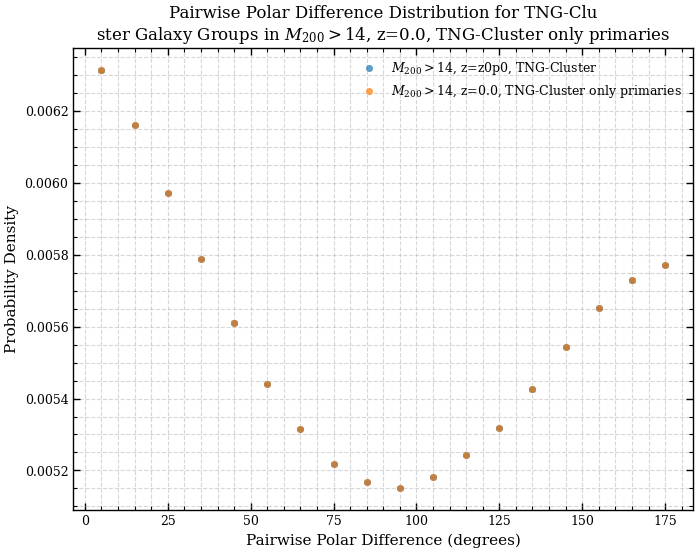

In [27]:
listRedshiftGG = []
# galaxyAnalysisZ0.setSnapshot(snapshot[0], newsim='TNG-Cluster', luminosityType='Default')
snapshot=(99,)
groupList = []
groupList.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG-Cluster'))
groupList.append((galaxyAnalysisZ0PrimaryOnly.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z=0.0, TNG-Cluster only primaries'))
listRedshiftGG.append(groupList)

polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlay_polar_pairwise_across_redshifts(listRedshiftGG=listRedshiftGG, typePlot='polar', oneaxis=True)#, plotRows=2, plotCols=3)
# galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
polar_ax.legend(loc='upper right')  # Add legend to the last subplot
polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/pairwise_polar_difference_cluster_vs_cluster-primaries_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')

# overall change dependence

## consistency plots

In [9]:
# get the percent of clusters below the 99% / 95% / 90% CL of random MRL, and plot it across redshift
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

redshifts = []
fracBelow99 = []
fracBelow95 = []
fracBelow90 = []

errBelow99 = []
errBelow95 = []
errBelow90 = []


def binomial_sigma(p, n):
    p = float(p)
    n = int(n)
    if n <= 0:
        return 0.0
    return float(np.sqrt(p * (1.0 - p) / n))


for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue  # too high redshift

    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    redshifts.append(snapshot[1])

    # Note: getPercentOfClustersAboveRandomMRLCL returns the fraction/count/total *below* the percentile.
    (f99, c99, n99, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=99
    )
    (f95, c95, n95, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=95
    )
    (f90, c90, n90, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=90
    )

    fracBelow99.append(f99)
    fracBelow95.append(f95)
    fracBelow90.append(f90)

    errBelow99.append(binomial_sigma(f99, n99))
    errBelow95.append(binomial_sigma(f95, n95))
    errBelow90.append(binomial_sigma(f90, n90))

Processing snapshot 99...
Fraction of MRL values below the 99th percentile of random MRL values: 0.7278 (1380/1896)th 428 satellites
Fraction of MRL values below the 95th percentile of random MRL values: 0.6171 (1170/1896)th 428 satellites
Fraction of MRL values below the 90th percentile of random MRL values: 0.5374 (1019/1896)th 428 satellites
Processing snapshot 91...
Fraction of MRL values below the 99th percentile of random MRL values: 0.7193 (1299/1806)th 322 satellites
Fraction of MRL values below the 95th percentile of random MRL values: 0.6063 (1095/1806)th 322 satellites
Fraction of MRL values below the 90th percentile of random MRL values: 0.5282 (954/1806)ith 322 satellites
Processing snapshot 84...
Fraction of MRL values below the 99th percentile of random MRL values: 0.7187 (1244/1731)th 374 satellites
Fraction of MRL values below the 95th percentile of random MRL values: 0.6095 (1055/1731)th 374 satellites
Fraction of MRL values below the 90th percentile of random MRL val

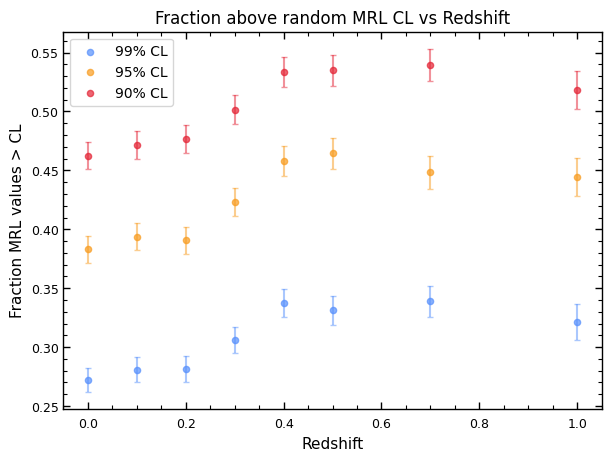

In [15]:
MRL_CL_plotter = AstroPlotter()
MRL_CL_fig, MRL_CL_ax = MRL_CL_plotter.create_figure()

MRL_CL_plotter.scatter_plot(
    redshifts,
    1-np.array(fracBelow99),
    errorBars=errBelow99,
    label='99% CL',
    ax=MRL_CL_ax,
)
MRL_CL_plotter.scatter_plot(
    redshifts,
    1-np.array(fracBelow95),
    errorBars=errBelow95,
    label='95% CL',
    ax=MRL_CL_ax,
)
MRL_CL_plotter.scatter_plot(
    redshifts,
    1-np.array(fracBelow90),
    errorBars=errBelow90,
    label='90% CL',
    ax=MRL_CL_ax,
)

MRL_CL_ax.set_xlabel('Redshift')
MRL_CL_ax.set_ylabel('Fraction MRL values > CL')
MRL_CL_ax.set_title('Fraction above random MRL CL vs Redshift')
MRL_CL_ax.legend(loc='upper left')

MRL_CL_plotter.save_figure(
    MRL_CL_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/percent_clusters_above_random_MRL_CL_vs_redshift_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

plt.show()

In [11]:
# do the same but for the 5 mass groups
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

redshifts = []

mass_bin_labels = [
    '$1e13<M_{200}<1e13.5$',
    '$1e13.5<M_{200}<1e14$',
    '$1e14<M_{200}<1e14.5$',
    '$1e14.5<M_{200}<1e15$',
    '$M_{200}>1e15$',
]

fracBelow99_mass_bins = [[] for _ in range(len(mass_bin_labels))]
fracBelow95_mass_bins = [[] for _ in range(len(mass_bin_labels))]
fracBelow90_mass_bins = [[] for _ in range(len(mass_bin_labels))]

errBelow99_mass_bins = [[] for _ in range(len(mass_bin_labels))]
errBelow95_mass_bins = [[] for _ in range(len(mass_bin_labels))]
errBelow90_mass_bins = [[] for _ in range(len(mass_bin_labels))]

countBelow99_mass_bins = [[] for _ in range(len(mass_bin_labels))]
countBelow95_mass_bins = [[] for _ in range(len(mass_bin_labels))]
countBelow90_mass_bins = [[] for _ in range(len(mass_bin_labels))]

totalCount_mass_bins = [[] for _ in range(len(mass_bin_labels))]


for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue  # too high redshift

    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    

    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]

    redshifts.append(galaxyAnalysisSnapshot.snapshot_dic[snapshot[0]][1])

    for i, mass_bin in enumerate(mass_bins):
        random_MRL_values = mass_bin.compute_MRL_random_distribution_curves_for_LGG(
            parallelize=False, num_samples=10000
        )

        (f99, c99, n99, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=99, random_mrl_values=random_MRL_values
        )
        (f95, c95, n95, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=95, random_mrl_values=random_MRL_values
        )
        (f90, c90, n90, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=90, random_mrl_values=random_MRL_values
        )

        fracBelow99_mass_bins[i].append(f99)
        fracBelow95_mass_bins[i].append(f95)
        fracBelow90_mass_bins[i].append(f90)

        errBelow99_mass_bins[i].append(binomial_sigma(f99, n99))
        errBelow95_mass_bins[i].append(binomial_sigma(f95, n95))
        errBelow90_mass_bins[i].append(binomial_sigma(f90, n90))
        
        countBelow99_mass_bins[i].append(c99)
        countBelow95_mass_bins[i].append(c95)
        countBelow90_mass_bins[i].append(c90)
        
        totalCount_mass_bins[i].append(n99)  # n99, n95, and n90 should all be the same, so just append n99

Processing snapshot 99...
Fraction of MRL values below the 99th percentile of random MRL values: 0.9621 (7464/7758) with 13 satellites
Fraction of MRL values below the 95th percentile of random MRL values: 0.9038 (7012/7758)
Fraction of MRL values below the 90th percentile of random MRL values: 0.8434 (6543/7758)
Fraction of MRL values below the 99th percentile of random MRL values: 0.9438 (2452/2598)ith 13 satellites
Fraction of MRL values below the 95th percentile of random MRL values: 0.8776 (2280/2598)
Fraction of MRL values below the 90th percentile of random MRL values: 0.8048 (2091/2598)
Fraction of MRL values below the 99th percentile of random MRL values: 0.8664 (759/876) with 60 satellitess
Fraction of MRL values below the 95th percentile of random MRL values: 0.7648 (670/876)
Fraction of MRL values below the 90th percentile of random MRL values: 0.6861 (601/876)
Fraction of MRL values below the 99th percentile of random MRL values: 0.6749 (490/726) with 317 satellites
Fracti

Created plotter and figs
finished point plotting


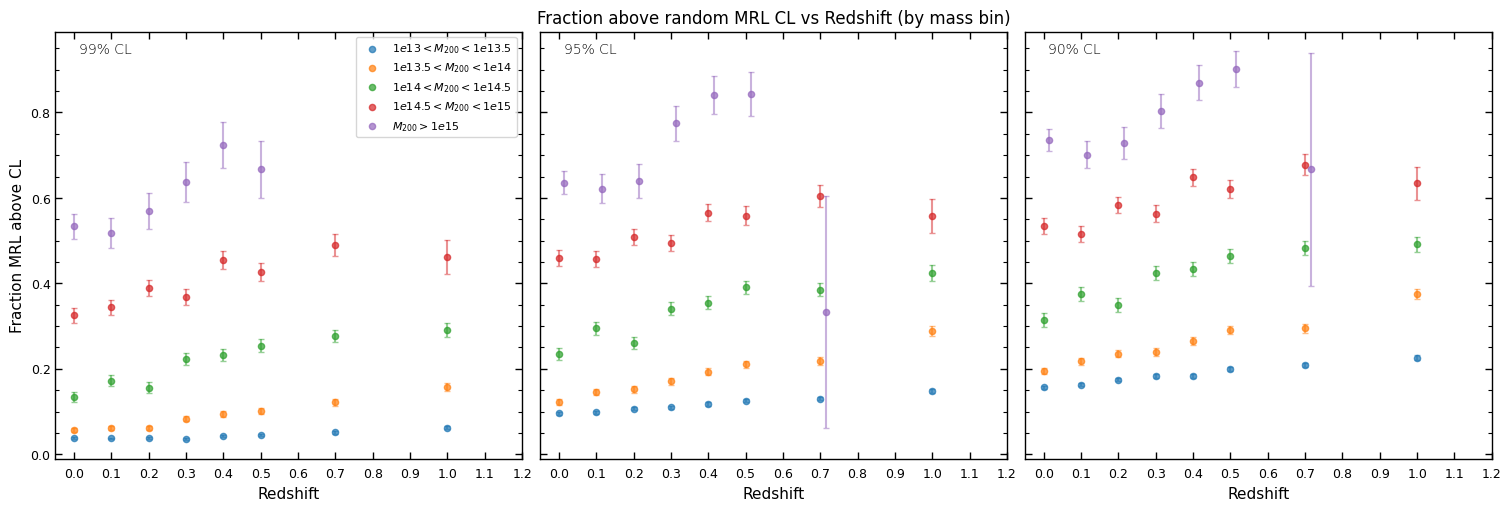

In [12]:
mass_bin_MRL_CL_plotter = AstroPlotter(style='cms', context='paper')
mass_bin_MRL_CL_fig, mass_bin_MRL_CL_ax = mass_bin_MRL_CL_plotter.create_figure(
    nrows=1,
    ncols=3,
    figsize=(15, 5),
    sharex=True,
    sharey=True,
    gridspec_kw={'wspace': 0.0},
)  # each col is a different confidence level, each line is a different mass bin
print("Created plotter and figs")
redshifts = SnapshotEnum.getAllRedshifts()[:8]

numOfShifts = 0
for i in range(len(mass_bin_labels)):
    if i == 4:
        numOfShifts += 1

    mass_bin_color = mass_bin_colors[i % len(mass_bin_colors)]

    # 99% CL — select non-zero entries and sort by redshift before plotting
    y99 = np.array(fracBelow99_mass_bins[i], dtype=float)
    count99 = np.array(countBelow99_mass_bins[i], dtype=int)
    mask99 = (count99 != 0) & (y99 != 1)
    if np.any(mask99):
        x99 = np.array(redshifts)[mask99]
        y99_sel = 1.0 - y99[mask99]
        yerr99 = np.array(errBelow99_mass_bins[i])[mask99]
        order99 = np.argsort(x99)
        mass_bin_MRL_CL_plotter.scatter_plot(
            x99[order99],
            y99_sel[order99],
            errorBars=yerr99[order99],
            label=f'{mass_bin_labels[i]}',
            ax=mass_bin_MRL_CL_ax[0],
            overlay_color=mass_bin_color,
        )

    # 95% CL
    y95 = np.array(fracBelow95_mass_bins[i], dtype=float)
    count95 = np.array(countBelow95_mass_bins[i], dtype=int)
    mask95 = (count95 != 0) & (y95 != 1)
    if np.any(mask95):
        x95 = np.array(redshifts)[mask95] + (numOfShifts - 0.015) * 0.015 if i == 4 else np.array(redshifts)[mask95]
        y95_sel = 1.0 - y95[mask95]
        yerr95 = np.array(errBelow95_mass_bins[i])[mask95]
        order95 = np.argsort(x95)
        mass_bin_MRL_CL_plotter.scatter_plot(
            x95[order95],
            y95_sel[order95],
            errorBars=yerr95[order95],
            label=f'{mass_bin_labels[i]}',
            ax=mass_bin_MRL_CL_ax[1],
            overlay_color=mass_bin_color,
        )

    # 90% CL
    y90 = np.array(fracBelow90_mass_bins[i], dtype=float)
    count90 = np.array(countBelow90_mass_bins[i], dtype=int)
    mask90 = (count90 != 0) & (y90 != 1)
    if np.any(mask90):
        x90 = np.array(redshifts)[mask90] + (numOfShifts - 0.015) * 0.015 if i == 4 else np.array(redshifts)[mask90]
        y90_sel = 1.0 - y90[mask90]
        yerr90 = np.array(errBelow90_mass_bins[i])[mask90]
        order90 = np.argsort(x90)
        mass_bin_MRL_CL_plotter.scatter_plot(
            x90[order90],
            y90_sel[order90],
            errorBars=yerr90[order90],
            label=f'{mass_bin_labels[i]}',
            ax=mass_bin_MRL_CL_ax[2],
            overlay_color=mass_bin_color,
        )

print("finished point plotting")

cl_labels = ['99% CL', '95% CL', '90% CL']
for i in range(3):
    # set only major on bottom
    mass_bin_MRL_CL_ax[i].xaxis.set_major_locator(MultipleLocator(0.1))
    mass_bin_MRL_CL_ax[i].xaxis.set_minor_locator(NullLocator())
    mass_bin_MRL_CL_ax[i].yaxis.set_minor_locator(AutoMinorLocator())
    mass_bin_MRL_CL_ax[i].tick_params(axis='x', which='minor', bottom=False, top=False)
    mass_bin_MRL_CL_ax[i].tick_params(axis='y', which='minor', length=3)
    mass_bin_MRL_CL_ax[i].set_xlabel('Redshift')

    # top-left confidence label annotation per panel
    mass_bin_MRL_CL_plotter.add_annotation(
        cl_labels[i],
        xy=(0.05, 0.95),
        xycoords='axes fraction',
        fontsize=10,
        fontweight='light',
        ax=mass_bin_MRL_CL_ax[i],
    )

# share y visually: keep ticks/labels only on left-most panel
mass_bin_MRL_CL_ax[1].tick_params(labelleft=False)
mass_bin_MRL_CL_ax[2].tick_params(labelleft=False)

mass_bin_MRL_CL_ax[0].set_ylabel('Fraction MRL above CL')
mass_bin_MRL_CL_ax[1].set_title('Fraction above random MRL CL vs Redshift (by mass bin)')

# increase xlim to give more space for legend
mass_bin_MRL_CL_ax[0].set_xlim(None, 1.2 * max(redshifts))

mass_bin_MRL_CL_ax[0].legend(fontsize=8, loc='upper right')

mass_bin_MRL_CL_plotter.save_figure(
    mass_bin_MRL_CL_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/percent_clusters_above_random_MRL_CL_vs_redshift_for_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

plt.show()


In [31]:
#get the point at redshift 0.7, m200>1e15 and 99% CL, and print the fraction and error:
snapshotEnum = SnapshotEnum.getSnapshotEnumFromRedshift(0.7)
print(snapshotEnum)
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshotEnum.value[0])
mass_bin = galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups
print(f"Snapshot {snapshotEnum.value[0]}, redshift {snapshotEnum.value[1]}, mass bin >1e15, 99% CL:")
print(f"fracBelow99_mass_bins for this snapshot and mass bin: {fracBelow99_mass_bins[4][6], fracBelow99_mass_bins[4][5], fracBelow99_mass_bins[4][7]}")
print(f"errBelow99_mass_bins for this snapshot and mass bin: {errBelow99_mass_bins[4][6], errBelow99_mass_bins[4][5], errBelow99_mass_bins[4][7]}")
print(f"countBelow99_mass_bins for this snapshot and mass bin: {countBelow99_mass_bins[4][6], countBelow99_mass_bins[4][5], countBelow99_mass_bins[4][7]}")
print(f"totalCount_mass_bins for this snapshot and mass bin: {totalCount_mass_bins[4][6], totalCount_mass_bins[4][5], totalCount_mass_bins[4][7]}")

SnapshotEnum.SNAPSHOT_59
Snapshot 59, redshift 0.7, mass bin >1e15, 99% CL:
fracBelow99_mass_bins for this snapshot and mass bin: (np.float64(1.0), np.float64(0.35294117647058826), 0)
errBelow99_mass_bins for this snapshot and mass bin: (0.0, 0.06691723046994365, 0.0)
countBelow99_mass_bins for this snapshot and mass bin: (np.int64(3), np.int64(18), 0)
totalCount_mass_bins for this snapshot and mass bin: (3, 51, 0)


## more reliable assymetry plots

In [19]:


mass_bin_labels = ['$1e13<M_{200}<1e13.5$', '$1e13.5<M_{200}<1e14$', '$1e14<M_{200}<1e14.5$', '$1e14.5<M_{200}<1e15$', '$M_{200}>1e15$']
redshift_mass_bins : list[list[ListGalaxyGroup]]= []
redshifts = []
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
    redshifts.append(snapshot[1])
    redshift_mass_bins.append(mass_bins)
    
polarPairwiseDifference_plotter, polarPairwiseDifference_fig, polarPairwiseDifference_ax, polar_pairwise_by_type_by_redshift = asymetryPlots(redshifts, listRedshiftGG=redshift_mass_bins, listGGLabels=mass_bin_labels, plotRows=1, plotCols=1, massColors = mass_bin_color)

polarPairwiseDifference_ax.set_title('Polar Pairwise Difference vs Redshift for Full Sample and Mass Bins')
polarPairwiseDifference_plotter.save_figure(polarPairwiseDifference_fig, galaxyAnalysisSnapshot.scratchPlotDirc + f'/polar_pairwise_difference_vs_redshift_for_full_sample_and_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}')
plt.show()

<unknown>:219: SyntaxWarning: invalid escape sequence '\d'
<unknown>:224: SyntaxWarning: invalid escape sequence '\d'


Processing snapshot 99...
Processing snapshot 91...
Processing snapshot 84...
Processing snapshot 78...
Processing snapshot 72...
Processing snapshot 67...
Processing snapshot 59...
Processing snapshot 50...
Total Galaxy Groups to process: 2586 with pairs : 131308
Progress: Processing Galaxy Group ID 993, 2586 / 25866Total Galaxy Groups to process: 866 with pairs : 350183
Progress: Processing Galaxy Group ID 999, 866 / 8666Total Galaxy Groups to process: 292 with pairs : 975806
Progress: Processing Galaxy Group ID 19441351, 292 / 292Total Galaxy Groups to process: 242 with pairs : 6422297
Progress: Processing Galaxy Group ID 9720881, 242 / 2422Total Galaxy Groups to process: 98 with pairs : 12402548
Progress: Processing Galaxy Group ID 9956048, 98 / 98Total Galaxy Groups to process: 2585 with pairs : 149715
Progress: Processing Galaxy Group ID 996, 2585 / 25855Total Galaxy Groups to process: 872 with pairs : 393531
Progress: Processing Galaxy Group ID 999, 872 / 8722Total Galaxy Groups

## see what is causing assymetry plots

### general consistent vs inconsistent function

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/combinedTNG300-1_TNGCluster/consistent_inconsistent_polar_difference_distribution_TNG300-1, TNG-Cluster
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/combinedTNG300-1_TNGCluster/consistent_inconsistent_MRL_distribution_TNG300-1, TNG-Cluster


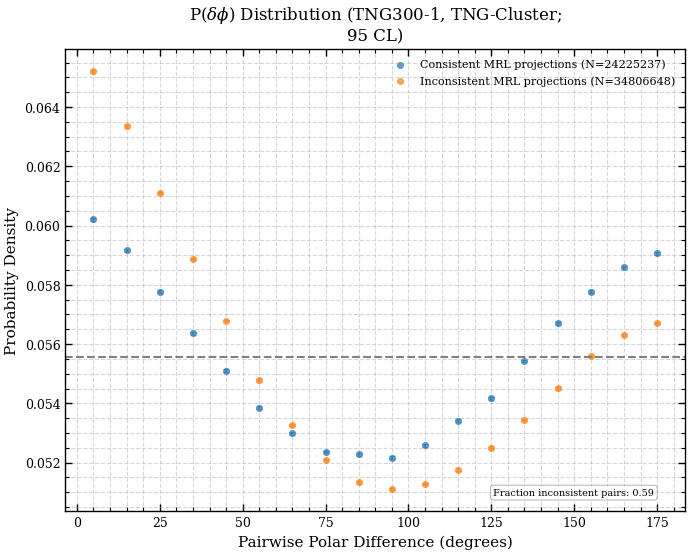

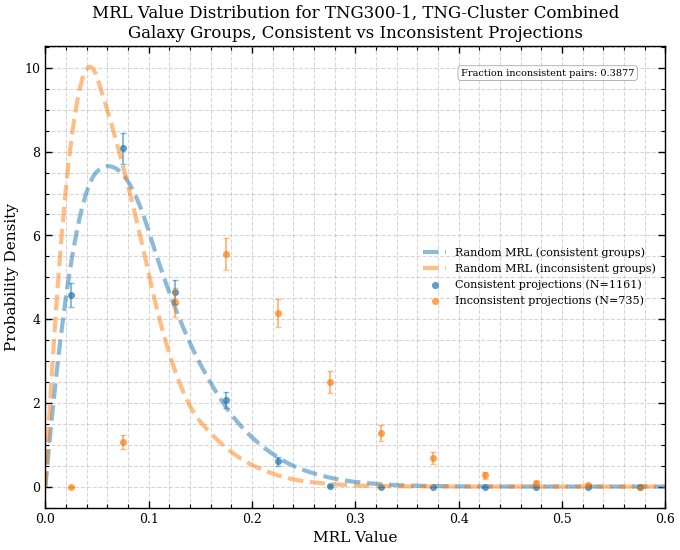

In [20]:
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
(consistent_inconsistent_polar_plotter, consistent_inconsistent_polar_fig, consistent_inconsistent_polar_ax), (consistent_inconsistent_mrl_plotter, consistent_inconsistent_mrl_fig, consistent_inconsistent_mrl_ax), gg_indices_inconsistent = getConsistentInconsistentPolarMRLPlots(list_gg=galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, snapshot=99, percentConfidenceMRL=95)


consistent_inconsistent_polar_plotter.save_figure(
    consistent_inconsistent_polar_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc + f'/consistent_inconsistent_polar_difference_distribution_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

consistent_inconsistent_mrl_ax.set_xlim(0,0.6)
consistent_inconsistent_mrl_plotter.save_figure(
    consistent_inconsistent_mrl_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc + f'/consistent_inconsistent_MRL_distribution_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

### general assymetry plot

processing snapshot: (99, 0, 'z0p0')


processing snapshot: (91, 0.1, 'z0p1')/ 632 with 428 satellitesr Galaxy Group 632 / 632 with 428 satellites
processing snapshot: (84, 0.2, 'z0p2')/ 602 with 322 satellitesr Galaxy Group 602 / 602 with 322 satellites
processing snapshot: (78, 0.3, 'z0p3')/ 577 with 374 satellitesr Galaxy Group 577 / 577 with 374 satellites
processing snapshot: (72, 0.4, 'z0p4')/ 549 with 136 satellitesr Galaxy Group 549 / 549 with 136 satellites
processing snapshot: (67, 0.5, 'z0p5')/ 529 with 226 satellitesr Galaxy Group 529 / 529 with 226 satellites
processing snapshot: (59, 0.7, 'z0p7')/ 493 with 201 satellitesr Galaxy Group 493 / 493 with 201 satellites
processing snapshot: (50, 1.0, 'z1p0')/ 432 with 264 satellitesr Galaxy Group 432 / 432 with 264 satellites
Total Galaxy Groups to process: 330 with pairs : 14653357llitesr Galaxy Group 312 / 312 with 191 satellites
Progress: Processing Galaxy Group ID 9956048, 330 / 3300Total Galaxy Groups to process: 302 with pairs : 5147294
Progress: Processing Ga

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/consistent_inconsistent_assymetry_plots_for_gt14_mass_bin_TNG300-1, TNG-Cluster


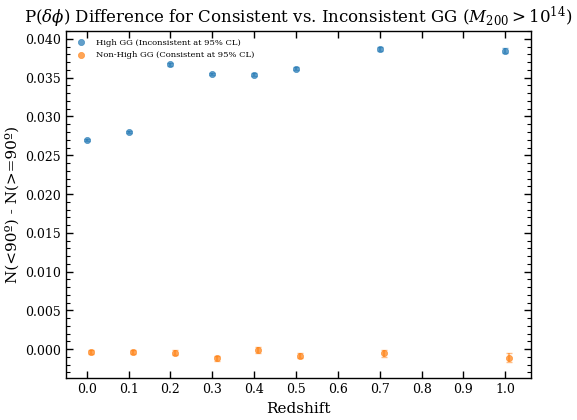

In [35]:
snapshotsAbove50 = [s for s in SnapshotEnum.getAllSnapshots() if s[0] >= 50]
consistent_inconsistent_assymetry_plotter, consistent_inconsistent_assymetry_fig, consistent_inconsistent_assymetry_ax, consistent_inconsistent_assymetry_by_type_by_redshift = getConsistentInconsistentAssymetryPlots(
    listRedshiftGalaxyAnalysis=listRedshiftGalaxyAnalysis,
    allSnapshotEnums=snapshotsAbove50,
    mass_bin_getter=lambda snapshot: snapshot.filtered_gt14_list_of_galaxy_groups,
    mass_bin_label='$M_{200}>10^{14}$',
    percentageMRL=95,
)

consistent_inconsistent_assymetry_plotter.save_figure(
    consistent_inconsistent_assymetry_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc    + f'/consistent_inconsistent_assymetry_plots_for_gt14_mass_bin_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

### snapshot 99

In [9]:
#get the subhalos which are inconsistent with random
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
random_MRL_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=10000) # 1000 samples for each subhalo, for the three different projection angles #i.e. total of 3000 random MRL values for each subhalo, for the three different projection angles
MRL_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_probablity_distribution_of_MRL_directionality(parallelize=False) #three MRL values for each subhalo, for the three different projection angles

(fraction, count, total, gg_indices_inconsistent) = GalaxyAnalysis.calculate_fraction_less_than_percentile(MRL_values=MRL_values, random_MRL_values=random_MRL_values, percentile=95)
percentageMRL=95
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
consistentColor = colors[0]
inconsistentColor = colors[1]
#gg_indices_inconsistent is a dict with key of the index of the galaxy group that has at least one projection MRL value below the 95th percentile of its random distribution, and value of a list of the projection angles (xy, yz, or xz) for which the MRL value is below the 95th percentile of its random distribution

In [10]:
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
from myproject.redshiftGalaxyAnalysis import GalaxyAnalysis
import numpy as np
print(gg_indices_inconsistent)
print(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups())
#see what are the properties of the gg which are inconsistent with random at 99 percentile, and see if they have any common properties among their subhalos which might be driving the lopsidedness in the polar pairwise distribution, and also see if they have any common properties among themselves (e.g. mass, redshift, number of subhalos, etc.)
high_galaxy_groups = []
non_high_galaxy_groups = []
for i, gg in enumerate(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups()):
    if i not in gg_indices_inconsistent.keys():
        # print(f'Galaxy Group {i} is consistent with random at 95 percentile')
        non_high_galaxy_groups.append(gg)
        continue
    high_galaxy_groups.append(gg)
    
high_list_galaxy_groups = ListGalaxyGroup(high_galaxy_groups)
non_high_list_galaxy_groups = ListGalaxyGroup(non_high_galaxy_groups)

{0: ['xz'], 1: ['xy', 'yz', 'xz'], 2: ['xy', 'yz'], 3: ['yz', 'xz'], 4: ['yz'], 5: ['xy', 'yz'], 6: ['xy', 'xz'], 9: ['yz'], 12: ['xy', 'yz', 'xz'], 15: ['xy'], 17: ['xy', 'yz', 'xz'], 20: ['xy', 'yz'], 23: ['xy', 'yz'], 25: ['xy', 'yz'], 27: ['xy', 'yz'], 29: ['yz', 'xz'], 30: ['xy', 'yz', 'xz'], 39: ['yz'], 40: ['xy', 'yz', 'xz'], 42: ['yz'], 50: ['xz'], 52: ['xy', 'yz'], 54: ['xy', 'yz'], 58: ['yz', 'xz'], 62: ['xy', 'yz'], 64: ['xy', 'yz', 'xz'], 65: ['xy', 'xz'], 68: ['xy'], 69: ['xy', 'yz', 'xz'], 71: ['xz'], 72: ['xy'], 73: ['xy', 'xz'], 74: ['xy', 'yz'], 77: ['yz', 'xz'], 79: ['xy', 'yz', 'xz'], 83: ['xy', 'xz'], 85: ['xy', 'yz', 'xz'], 86: ['yz'], 87: ['yz', 'xz'], 92: ['xy', 'yz'], 98: ['xy', 'yz', 'xz'], 100: ['yz'], 101: ['xy', 'yz', 'xz'], 102: ['xy', 'yz', 'xz'], 103: ['xz'], 106: ['yz', 'xz'], 107: ['yz', 'xz'], 108: ['yz', 'xz'], 111: ['xy', 'yz'], 116: ['xy', 'xz'], 126: ['xy', 'xz'], 130: ['xy', 'yz', 'xz'], 132: ['xy', 'yz', 'xz'], 135: ['xy', 'yz', 'xz'], 136: ['xz'

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


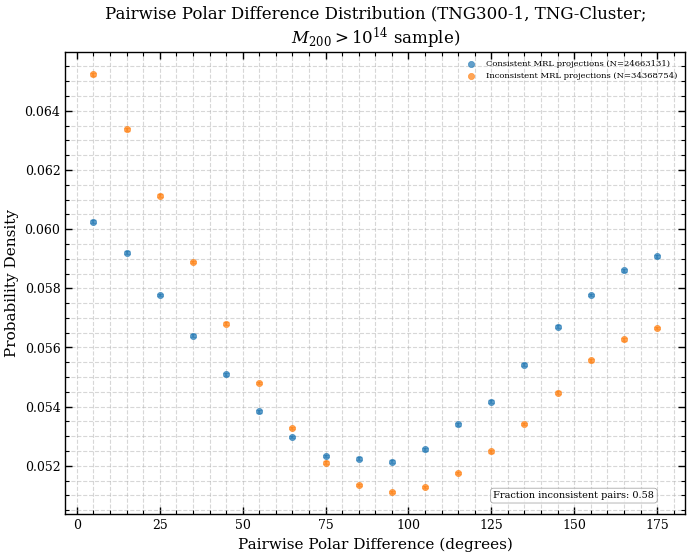

In [11]:
# Manually do overlay_polar_pairwise_across_redshifts but by projection so we can remove
# inconsistent projections in gg_indices_inconsistent.
#
# IMPORTANT:
# - gg_indices_inconsistent is keyed by index in the filtered_gt14 list, not the full loaded catalog.
# - To avoid selection bias, include *all* groups in the filtered_gt14 list (missing key => no inconsistent projections).

from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

polar_plotter = AstroPlotter()
polar_fig, polar_ax = polar_plotter.create_figure(ncols=1, nrows=1, figsize=(8, 6))

polar_inconsistent_tuples = []
polar_consistent_tuples = []

projections_all = ["xy", "yz", "xz"]
filtered_gt14 = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups

for group_index, galaxyGroup in enumerate(filtered_gt14.getAllGalaxyGroups()):
    inconsistentProjections = gg_indices_inconsistent.get(group_index, [])
    consistentProjections = [p for p in projections_all if p not in inconsistentProjections]

    if len(consistentProjections) > 0:
        consistent_vals = ListGalaxyGroup._compute_pairwise_for_group(
            galaxyGroup, projections=consistentProjections
        )
        polar_consistent_tuples.extend(consistent_vals)

    if len(inconsistentProjections) > 0:
        inconsistent_vals = ListGalaxyGroup._compute_pairwise_for_group(
            galaxyGroup, projections=inconsistentProjections
        )
        polar_inconsistent_tuples.extend(inconsistent_vals)

# Pool all selected projections into a single 1D list of angle differences (deg)
polarConsistentValues = [v for tup in polar_consistent_tuples for v in tup]
polarInconsistentValues = [v for tup in polar_inconsistent_tuples for v in tup]

grand_total = len(polarConsistentValues) + len(polarInconsistentValues)

bin = np.arange(0, 185, 10)
xlabel = "Pairwise Polar Difference (degrees)"
ylabel = "Probability Density"
title = "Pairwise Polar Difference Distribution (TNG300-1, TNG-Cluster; $M_{200}>10^{14}$ sample)"

consistent_bin_values, consistent_bin_centers, consistent_bin_errorbars = ListGalaxyGroup.get_histogram_bins(
    polarConsistentValues,
    bins=bin,
    errorbarType="poisson",
    normalize_to_one=True,
 )
inconsistent_bin_values, inconsistent_bin_centers, inconsistent_bin_errorbars = ListGalaxyGroup.get_histogram_bins(
    polarInconsistentValues,
    bins=bin,
    errorbarType="poisson",
    normalize_to_one=True,
 )

polar_plotter.scatter_plot(
    consistent_bin_centers,
    consistent_bin_values,
    errorBars=consistent_bin_errorbars,
    ax=polar_ax,
    xlabel=xlabel,
    ylabel=ylabel,
    title=title,
    label=f"Consistent MRL projections (N={len(polarConsistentValues)})",
    output_filename=None,
    grid=True,
 )
polar_plotter.scatter_plot(
    inconsistent_bin_centers,
    inconsistent_bin_values,
    errorBars=inconsistent_bin_errorbars,
    ax=polar_ax,
    xlabel=xlabel,
    ylabel=ylabel,
    title=title,
    label=f"Inconsistent MRL projections (N={len(polarInconsistentValues)})",
    output_filename=None,
    grid=True,
 )

frac_inconsistent = (len(polarInconsistentValues) / grand_total) if grand_total else 0.0
polar_ax.text(
    0.95,
    0.05,
    f"Fraction inconsistent pairs: {frac_inconsistent:.2f}",
    transform=polar_ax.transAxes,
    fontsize=7,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray"),
 )
polar_ax.legend(fontsize=6)

In [12]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
consistentColor = colors[0]
inconsistentColor = colors[1]
numsamples=10000

Total projection slots: 1896MRL distribution, samples:10000, for Galaxy Group 298 / 298 with 330 satellites
Consistent kept: 1169
Inconsistent kept: 727
Check partition equals finite total: True


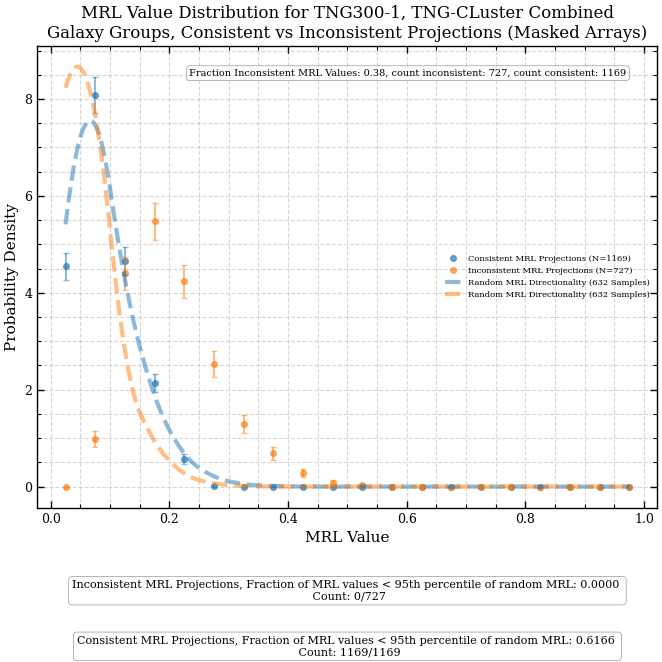

In [13]:
# Build projection-aligned masked MRL arrays from existing Cell 52 outputs.
# Keeps shape/order identical to MRL_values: [xy, yz, xz] repeated by group.

# Do the same but for the MRL values instead of the polar pairwise differences, and see if the
# inconsistent projections have systematically different MRL values than the consistent projections.
#
# IMPORTANT:
# - gg_indices_inconsistent is keyed by index in the filtered_gt14 list.
# - Include all groups in the filtered_gt14 list (missing key => no inconsistent projections).
import numpy as np

if "MRL_values" not in globals() or "gg_indices_inconsistent" not in globals() or "galaxyAnalysisSnapshot" not in globals():
    raise RuntimeError("Run Cell 52 first (needs MRL_values, gg_indices_inconsistent, galaxyAnalysisSnapshot).")


mrl_plotter = AstroPlotter()
mrl_fig, mrl_ax = mrl_plotter.create_figure(ncols=1, nrows=1, figsize=(8, 6))


projections_all = ["xy", "yz", "xz"]
proj_to_idx = {"xy": 0, "yz": 1, "xz": 2}

filtered_gt14 = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups
mrl_values_array = np.asarray(MRL_values, dtype=float)


#from old
inconsistent_random_MRL_values = high_list_galaxy_groups.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=numsamples)
inconsistent_random_MRL_bins, inconsistent_random_MRL_bin_centers, inconsistent_random_MRL_errorbars = ListGalaxyGroup.get_histogram_bins(inconsistent_random_MRL_values, binsize=0.05, binLow=0, binHigh=1, errorbarType='poisson', density=True)

consistent_random_MRL_values = non_high_list_galaxy_groups.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=numsamples)
consistent_random_MRL_bins, consistent_random_MRL_bin_centers, consistent_random_MRL_errorbars = ListGalaxyGroup.get_histogram_bins(consistent_random_MRL_values, binsize=0.05, binLow=0, binHigh=1, errorbarType='poisson', density=True)


if len(mrl_values_array) != 3 * len(filtered_gt14.getAllGalaxyGroups()):
    raise ValueError("MRL_values length does not match 3 * number of groups in filtered_gt14.")

consistent_MRL_values_masked = np.full_like(mrl_values_array, np.nan)
inconsistent_MRL_values_masked = np.full_like(mrl_values_array, np.nan)

for group_index in range(len(filtered_gt14.getAllGalaxyGroups())):
    base = group_index * 3
    group_vals = mrl_values_array[base:base + 3]
    inconsistent_set = set(gg_indices_inconsistent.get(group_index, []))

    for proj in projections_all:
        idx = proj_to_idx[proj]
        val = group_vals[idx]
        if not np.isfinite(val):
            continue
        if proj in inconsistent_set:
            inconsistent_MRL_values_masked[base + idx] = val
        else:
            consistent_MRL_values_masked[base + idx] = val

# Optional finite-only lists for histogramming
consistent_MRL_values = consistent_MRL_values_masked[np.isfinite(consistent_MRL_values_masked)].tolist()
inconsistent_MRL_values = inconsistent_MRL_values_masked[np.isfinite(inconsistent_MRL_values_masked)].tolist()

print(f"Total projection slots: {len(mrl_values_array)}")
print(f"Consistent kept: {np.isfinite(consistent_MRL_values_masked).sum()}")
print(f"Inconsistent kept: {np.isfinite(inconsistent_MRL_values_masked).sum()}")
print(f"Check partition equals finite total: {np.isfinite(consistent_MRL_values_masked).sum() + np.isfinite(inconsistent_MRL_values_masked).sum() == np.isfinite(mrl_values_array).sum()}")



inconsistent_fraction_above_percentile_masked, inconsistent_count_less_than_percentile_masked, inconsistent_total_count_masked, inconsistent_subhaloIndexInconsistentWithRandom_masked = GalaxyAnalysis.calculate_fraction_less_than_percentile(inconsistent_MRL_values_masked, random_MRL_values, percentageMRL)
consistent_fraction_above_percentile_masked, consistent_count_less_than_percentile_masked, consistent_total_count_masked, consistent_subhaloIndexInconsistentWithRandom_masked = GalaxyAnalysis.calculate_fraction_less_than_percentile(consistent_MRL_values_masked, random_MRL_values, percentageMRL)

bin = np.arange(0, 1.05, 0.05)
xlabel = 'MRL Value'
ylabel = 'Probability Density'
title = f'MRL Value Distribution for TNG300-1, TNG-CLuster Combined Galaxy Groups, Consistent vs Inconsistent Projections (Masked Arrays)'
consistent_bin_values_masked, consistent_bin_centers_masked, consistent_bin_errorbars_masked = ListGalaxyGroup.get_histogram_bins(consistent_MRL_values, bins=bin, errorbarType='poisson', density=True)
inconsistent_bin_values_masked, inconsistent_bin_centers_masked, inconsistent_bin_errorbars_masked = ListGalaxyGroup.get_histogram_bins(inconsistent_MRL_values, bins=bin, errorbarType='poisson', density=True)
mrl_plotter.scatter_plot(
    consistent_bin_centers_masked, 
    consistent_bin_values_masked,
    errorBars = consistent_bin_errorbars_masked,
    ax=mrl_ax, # Use the same axis for overlay
    xlabel=xlabel,
    ylabel=ylabel,
    title=title,
    overlay_color=consistentColor,
    label=f"Consistent MRL Projections (N={len(consistent_MRL_values)})",
    output_filename=None,
    grid=True,
 )
mrl_plotter.scatter_plot(
    inconsistent_bin_centers_masked,
    inconsistent_bin_values_masked,
    errorBars = inconsistent_bin_errorbars_masked,
    ax=mrl_ax, # Use the same axis for overlay
    xlabel=xlabel,
    ylabel=ylabel,
    title=title,
    overlay_color=inconsistentColor,
    label=f"Inconsistent MRL Projections (N={len(inconsistent_MRL_values)})",
    output_filename=None,
    grid=True,
 )

mrl_plotter.scatter_plot(
    consistent_random_MRL_bin_centers,
    consistent_random_MRL_bins,
    # errorBars = random_MRL_errorbars,
    ax=mrl_ax, # Use the same axis for overlay
    # ylim = (0, 0.01),
    label=f"Random MRL Directionality ({len(random_MRL_values)} Samples)",
    overlay_color=consistentColor,
    alpha=0,
    # output_filename=scratchPlotDirc + f'/MRL_distribution_curves_overlay_{sim}{self.plotEndingFormat}',
    output_filename=None,
    grid=True,
    spline_curvature=True,
    spline_smoothing=0,
 )
mrl_plotter.scatter_plot(
    inconsistent_random_MRL_bin_centers,
    inconsistent_random_MRL_bins,
    # errorBars = random_MRL_errorbars,
    ax=mrl_ax, # Use the same axis for overlay
    # ylim = (0, 0.01),
    label=f"Random MRL Directionality ({len(random_MRL_values)} Samples)",
    overlay_color=inconsistentColor,
    alpha=0,
    # output_filename=scratchPlotDirc + f'/MRL_distribution_curves_overlay_{sim}{self.plotEndingFormat}',
    output_filename=None,
    grid=True,
    spline_curvature=True,
    spline_smoothing=0,
 )

text_box_count_by_axis = {}
text = f"Inconsistent MRL Projections, Fraction of MRL values < {str(percentageMRL)}th percentile of random MRL: {inconsistent_fraction_above_percentile_masked:.4f} \n Count: {inconsistent_count_less_than_percentile_masked}/{len(inconsistent_MRL_values)}"
axis_key = id(mrl_ax)
textbox_index = text_box_count_by_axis.get(axis_key, 0)
text_box_count_by_axis[axis_key] = textbox_index + 1
text_y = -0.18 - (0.12 * textbox_index)
mrl_ax.text(
    0.5,
    text_y,
    text,
    transform=mrl_ax.transAxes,
    fontsize=8,
    ha='center',
    va='center',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'),
)

text = f"Consistent MRL Projections, Fraction of MRL values < {str(percentageMRL)}th percentile of random MRL: {consistent_fraction_above_percentile_masked:.4f} \n Count: {consistent_count_less_than_percentile_masked}/{len(consistent_MRL_values)}"
axis_key = id(mrl_ax)
textbox_index = text_box_count_by_axis.get(axis_key, 0)
text_box_count_by_axis[axis_key] = textbox_index + 1
text_y = -0.18 - (0.12 * textbox_index)
mrl_ax.text(
    0.5,
    text_y,
    text,
    transform=mrl_ax.transAxes,
    fontsize=8,
    ha='center',
    va='center',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'),
)

mrl_ax.text(0.95, 0.95, f'Fraction Inconsistent MRL Values: {len(inconsistent_MRL_values) / (len(consistent_MRL_values) + len(inconsistent_MRL_values)):.2f}, count inconsistent: {len(inconsistent_MRL_values)}, count consistent: {len(consistent_MRL_values)}', transform=mrl_ax.transAxes, fontsize=7, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
mrl_ax.legend(fontsize=6)

### test flagging

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Do the same but for the MRL values instead of the polar pairwise differences, and see if the
# inconsistent projections have systematically different MRL values than the consistent projections.
#
# IMPORTANT:
# - gg_indices_inconsistent is keyed by index in the filtered_gt14 list.
# - Include all groups in the filtered_gt14 list (missing key => no inconsistent projections).
numsamples = 100000
percentageMRL = 95

if "MRL_values" not in globals() or "random_MRL_values" not in globals() or "gg_indices_inconsistent" not in globals():
    raise RuntimeError("Run Cell 46 first (needs MRL_values, random_MRL_values, gg_indices_inconsistent).")

# mrl_plotter = AstroPlotter()
# mrl_fig, mrl_ax = mrl_plotter.create_figure(ncols=1, nrows=1, figsize=(8, 6))

consistent_MRL_values = []
inconsistent_MRL_values = []

# NOTE: GalaxyAnalysis.calculate_fraction_less_than_percentile assumes group ordering [xy, xz, yz].
proj_to_idx = {"xy": 0, "xz": 2, "yz": 1}
projections_all = ["xy", "xz", "yz"]

filtered_gt14 = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups

### check individual clusters with mrl below 0.2

#### plot singular MRL value of MRL val < 0.2 – is it just becuase of high member counts

Galaxy Group 0 has inconsistent projection 'xz' with MRL value 0.079 < 0.2


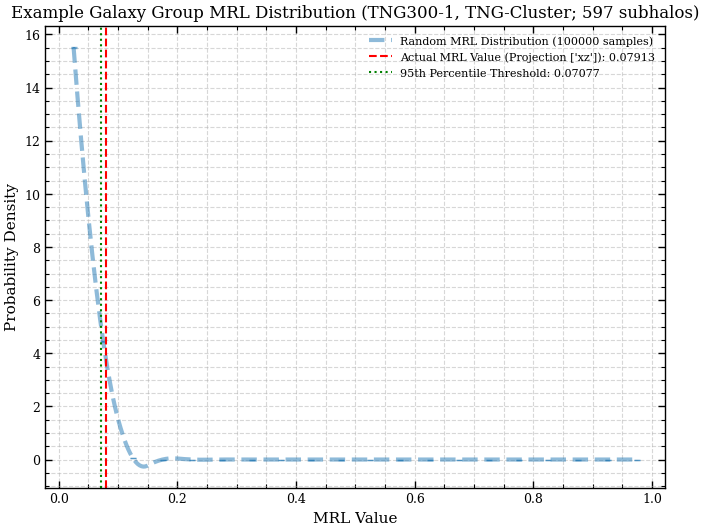

In [15]:
#grab the inconsistent galaxy groups with MRL below 0.2, choose say the first one and plot its sole random distribution with its singular actual MRL value
inconsistentGalaxyGroupsWithLowMRLToTest = []
inconsistentGalaxyGroupsWithLowMRLProjections = []
for group_index, galaxyGroup in enumerate(filtered_gt14.getAllGalaxyGroups()):
    inconsistentProjections = gg_indices_inconsistent.get(group_index, [])
    
    if len(inconsistentProjections) > 0:
        if inconsistentProjections == ["xy"] and MRL_values[group_index * 3 + proj_to_idx["xy"]] < 0.2:
            print(f"Galaxy Group {group_index} has inconsistent projection 'xy' with MRL value {MRL_values[group_index * 3 + proj_to_idx['xy']]:.3f} < 0.2")
            inconsistentGalaxyGroupsWithLowMRLToTest.append(galaxyGroup)
            inconsistentGalaxyGroupsWithLowMRLProjections.append(inconsistentProjections)
        elif inconsistentProjections == ["yz"] and MRL_values[group_index * 3 + proj_to_idx["yz"]] < 0.2:
            print(f"Galaxy Group {group_index} has inconsistent projection 'yz' with MRL value {MRL_values[group_index * 3 + proj_to_idx['yz']]:.3f} < 0.2")
            inconsistentGalaxyGroupsWithLowMRLToTest.append(galaxyGroup)
            inconsistentGalaxyGroupsWithLowMRLProjections.append(inconsistentProjections)
        elif inconsistentProjections == ["xz"] and MRL_values[group_index * 3 + proj_to_idx["xz"]] < 0.2:
            print(f"Galaxy Group {group_index} has inconsistent projection 'xz' with MRL value {MRL_values[group_index * 3 + proj_to_idx['xz']]:.3f} < 0.2")
            inconsistentGalaxyGroupsWithLowMRLToTest.append(galaxyGroup)
            inconsistentGalaxyGroupsWithLowMRLProjections.append(inconsistentProjections)
            
        break  # stop after the first one for demonstration

if inconsistentGalaxyGroupsWithLowMRLToTest:
    example_group = inconsistentGalaxyGroupsWithLowMRLToTest[0]
    example_projections = inconsistentGalaxyGroupsWithLowMRLProjections[0]
    example_actual_MRL_values = ListGalaxyGroup._compute_MRL_for_group(example_group, projections=example_projections)
    example_random_MRL_values = ListGalaxyGroup.compute_an_MRL_distribution_curves(
        num_samples=numsamples,
        num_non_centrals=len(example_group.getSatelliteSubhalos()),
    )

    example_plotter = AstroPlotter()
    example_fig, example_ax = example_plotter.create_figure(ncols=1, nrows=1, figsize=(8, 6))
    bin = np.arange(0, 1.05, 0.05)
    xlabel = 'MRL Value'
    ylabel = 'Probability Density'
    title = f'Example Galaxy Group MRL Distribution (TNG300-1, TNG-Cluster; {len(example_group.getSatelliteSubhalos())} subhalos)'

    random_bins, random_bin_centers, random_errorbars = ListGalaxyGroup.get_histogram_bins(example_random_MRL_values, bins=bin, errorbarType='poisson', density=True)
    example_plotter.scatter_plot(
        random_bin_centers,
        random_bins,
        errorBars=random_errorbars,
        ax=example_ax,
        xlabel=xlabel,
        ylabel=ylabel,
        title=title,
        label=f"Random MRL Distribution ({numsamples} samples)",
        output_filename=None,
        alpha=0,
        grid=True,
        spline_curvature=True,
        spline_smoothing=0,
    )

    for idx, actual_mrl in enumerate(example_actual_MRL_values):
        if np.isfinite(actual_mrl):
            example_ax.axvline(actual_mrl, color='red', linestyle='--', label=f'Actual MRL Value (Projection {example_projections}): {actual_mrl:.5f}')
            #add text annotation for the actual MRL value
            # example_ax.text(
            #     actual_mrl,
            #     example_ax.get_ylim()[1] * 0.7,
            #     f'{actual_mrl:.3f}',
            #     color='red',
            #     fontsize=7,
            #     ha='center',
            #     va='top',
            #     rotation=90,
            #     backgroundcolor='white',
            # )
            
    #plot the 95th percentile threshold as well
    threshold_95 = np.percentile(example_random_MRL_values, percentageMRL)
    example_ax.axvline(threshold_95, color='green', linestyle=':', label=f'95th Percentile Threshold: {threshold_95:.5f}')
    #add text annotation for the threshold
    # example_ax.text(
    #     threshold_95,
    #     example_ax.get_ylim()[1] * 0.9,
    #     f'{threshold_95:.3f}',
    #     color='green',
    #     fontsize=7,
    #     ha='center',
    #     va='top',
    #     rotation=90,
    #     backgroundcolor='white',
    # )

    example_ax.set_xlabel(xlabel)
    example_ax.set_ylabel(ylabel)
    example_ax.set_title(title)
    example_ax.legend(fontsize=8)
else:
    print("No inconsistent galaxy groups with MRL below 0.2 found.")

In [19]:
# plot single value of MRL < 0.05
inconsistentGalaxyGroupsWithVeryLowMRLToTest = []
inconsistentGalaxyGroupsWithVeryLowMRLProjections = []
for group_index, galaxyGroup in enumerate(filtered_gt14.getAllGalaxyGroups()):
    inconsistentProjections = gg_indices_inconsistent.get(group_index, [])
    
    if len(inconsistentProjections) > 0:
        if "xy" in inconsistentProjections and MRL_values[group_index * 3 + proj_to_idx["xy"]] < 0.05:
            print(f"Galaxy Group {group_index} has inconsistent projection 'xy' with MRL value {MRL_values[group_index * 3 + proj_to_idx['xy']]:.3f} < 0.05")
            inconsistentGalaxyGroupsWithVeryLowMRLToTest.append(galaxyGroup)
            inconsistentGalaxyGroupsWithVeryLowMRLProjections.append(inconsistentProjections)
        elif "yz" in inconsistentProjections and MRL_values[group_index * 3 + proj_to_idx["yz"]] < 0.05:
            print(f"Galaxy Group {group_index} has inconsistent projection 'yz' with MRL value {MRL_values[group_index * 3 + proj_to_idx['yz']]:.3f} < 0.05")
            inconsistentGalaxyGroupsWithVeryLowMRLToTest.append(galaxyGroup)
            inconsistentGalaxyGroupsWithVeryLowMRLProjections.append(inconsistentProjections)
        elif "xz" in inconsistentProjections and MRL_values[group_index * 3 + proj_to_idx["xz"]] < 0.05:
            print(f"Galaxy Group {group_index} has inconsistent projection 'xz' with MRL value {MRL_values[group_index * 3 + proj_to_idx['xz']]:.3f} < 0.05")
            inconsistentGalaxyGroupsWithVeryLowMRLToTest.append(galaxyGroup)
            inconsistentGalaxyGroupsWithVeryLowMRLProjections.append(inconsistentProjections)
            
        if len(inconsistentGalaxyGroupsWithVeryLowMRLToTest) >= 1:
            break  # stop after the first one for demonstration
if inconsistentGalaxyGroupsWithVeryLowMRLToTest:
    example_group = inconsistentGalaxyGroupsWithVeryLowMRLToTest[0]
    example_projections = inconsistentGalaxyGroupsWithVeryLowMRLProjections[0]
    example_actual_MRL_values = ListGalaxyGroup._compute_MRL_for_group(example_group, projections=example_projections)
    example_random_MRL_values = ListGalaxyGroup.compute_an_MRL_distribution_curves(
        num_samples=numsamples,
        num_non_centrals=len(example_group.getSatelliteSubhalos()),
    )

    example_plotter = AstroPlotter()
    example_fig, example_ax = example_plotter.create_figure(ncols=1, nrows=1, figsize=(8, 6))
    bin = np.arange(0, 1.05, 0.05)
    xlabel = 'MRL Value'
    ylabel = 'Probability Density'
    title = f'Example Galaxy Group MRL Distribution (TNG300-1, TNG-Cluster; {len(example_group.getSatelliteSubhalos())} subhalos)'

    random_bins, random_bin_centers, random_errorbars = ListGalaxyGroup.get_histogram_bins(example_random_MRL_values, bins=bin, errorbarType='poisson', density=True)
    example_plotter.scatter_plot(
        random_bin_centers,
        random_bins,
        errorBars=random_errorbars,
        ax=example_ax,
        xlabel=xlabel,
        ylabel=ylabel,
        title=title,
        label=f"Random MRL Distribution ({numsamples} samples)",
        output_filename=None,
        alpha=0,
        grid=True,
        spline_curvature=True,
        spline_smoothing=0,
    )

    for idx, actual_mrl in enumerate(example_actual_MRL_values):
        if np.isfinite(actual_mrl):
            example_ax.axvline(actual_mrl, color='red', linestyle='--', label=f'Actual MRL Value (Projection {example_projections}): {actual_mrl:.5f}')
            
    threshold_95 = np.percentile(example_random_MRL_values, percentageMRL)
    example_ax.axvline(threshold_95, color='green', linestyle=':', label=f'95th Percentile Threshold: {threshold_95:.5f}')

    example_ax.set_xlabel(xlabel)
    example_ax.set_ylabel(ylabel)
    example_ax.set_title(title)
    example_ax.legend(fontsize=8)
else:
    print("No inconsistent galaxy groups with MRL below 0.05 found.")

No inconsistent galaxy groups with MRL below 0.05 found.


Galaxy Group 9 has inconsistent projection 'yz' with MRL value 0.200 < 0.2 and member num 85


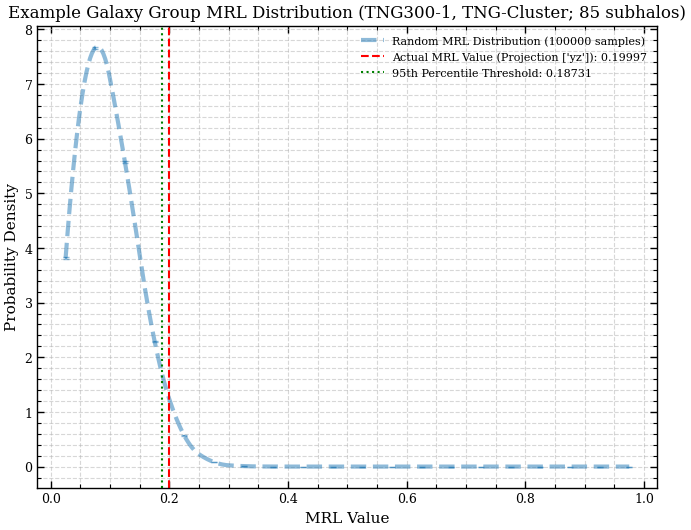

In [18]:
# plot single value of MRL <0.2 and member num < 150
# plot single value of MRL <0.2 and member num < 150
galaxyMemberNumToTest = 150
inconsistentGalaxyGroupsWithLowMRLToTestAndMemberNum = []
for group_index, galaxyGroup in enumerate(filtered_gt14.getAllGalaxyGroups()):
    inconsistentProjections = gg_indices_inconsistent.get(group_index, [])
    
    if len(inconsistentProjections) > 0 and len(galaxyGroup.getSatelliteSubhalos()) < galaxyMemberNumToTest:
        # print("pass: ", print(len(inconsistentProjections), len(galaxyGroup.getSatelliteSubhalos())))
        # print("xy:", "xy" in inconsistentProjections, " yz:", "yz" in inconsistentProjections, " xz:", "xz" in inconsistentProjections)
        if "xy" in inconsistentProjections and MRL_values[group_index * 3 + proj_to_idx["xy"]] < 0.2:
            print(f"Galaxy Group {group_index} has inconsistent projection 'xy' with MRL value {MRL_values[group_index * 3 + proj_to_idx['xy']]:.3f} < 0.2 and member num {len(galaxyGroup.getSatelliteSubhalos())}")
            inconsistentGalaxyGroupsWithLowMRLToTestAndMemberNum.append(galaxyGroup)
        elif "yz" in inconsistentProjections and MRL_values[group_index * 3 + proj_to_idx["yz"]] < 0.2:
            print(f"Galaxy Group {group_index} has inconsistent projection 'yz' with MRL value {MRL_values[group_index * 3 + proj_to_idx['yz']]:.3f} < 0.2 and member num {len(galaxyGroup.getSatelliteSubhalos())}")
            inconsistentGalaxyGroupsWithLowMRLToTestAndMemberNum.append(galaxyGroup)
        elif "xz" in inconsistentProjections and MRL_values[group_index * 3 + proj_to_idx["xz"]] < 0.2:
            print(f"Galaxy Group {group_index} has inconsistent projection 'xz' with MRL value {MRL_values[group_index * 3 + proj_to_idx['xz']]:.3f} < 0.2 and member num {len(galaxyGroup.getSatelliteSubhalos())}")
            inconsistentGalaxyGroupsWithLowMRLToTestAndMemberNum.append(galaxyGroup)
        
        # print(inconsistentGalaxyGroupsWithLowMRLToTestAndMemberNum)
        if inconsistentGalaxyGroupsWithLowMRLToTestAndMemberNum:
            break  # stop after the first one for demonstration
    # else:
        # print("not pass: ", len(inconsistentProjections), len(galaxyGroup.getSatelliteSubhalos()))
    
if inconsistentGalaxyGroupsWithLowMRLToTestAndMemberNum:
    example_group = inconsistentGalaxyGroupsWithLowMRLToTestAndMemberNum[0]
    example_projections = gg_indices_inconsistent.get(filtered_gt14.getAllGalaxyGroups().index(example_group), [])
    example_actual_MRL_values = ListGalaxyGroup._compute_MRL_for_group(example_group, projections=example_projections)
    example_random_MRL_values = ListGalaxyGroup.compute_an_MRL_distribution_curves(
        num_samples=numsamples,
        num_non_centrals=len(example_group.getSatelliteSubhalos()),
    )

    example_plotter = AstroPlotter()
    example_fig, example_ax = example_plotter.create_figure(ncols=1, nrows=1, figsize=(8, 6))
    bin = np.arange(0, 1.05, 0.05)
    xlabel = 'MRL Value'
    ylabel = 'Probability Density'
    title = f'Example Galaxy Group MRL Distribution (TNG300-1, TNG-Cluster; {len(example_group.getSatelliteSubhalos())} subhalos)'

    random_bins, random_bin_centers, random_errorbars = ListGalaxyGroup.get_histogram_bins(example_random_MRL_values, bins=bin, errorbarType='poisson', density=True)
    example_plotter.scatter_plot(
        random_bin_centers,
        random_bins,
        errorBars=random_errorbars,
        ax=example_ax,
        xlabel=xlabel,
        ylabel=ylabel,
        title=title,
        label=f"Random MRL Distribution ({numsamples} samples)",
        output_filename=None,
        alpha=0,
        grid=True,
        spline_curvature=True,
        spline_smoothing=0,
    )

    for idx, actual_mrl in enumerate(example_actual_MRL_values):
        if np.isfinite(actual_mrl):
            example_ax.axvline(actual_mrl, color='red', linestyle='--', label=f'Actual MRL Value (Projection {example_projections}): {actual_mrl:.5f}')
            
    threshold_95 = np.percentile(example_random_MRL_values, percentageMRL)
    example_ax.axvline(threshold_95, color='green', linestyle=':', label=f'95th Percentile Threshold: {threshold_95:.5f}')

    example_ax.set_xlabel(xlabel)
    example_ax.set_ylabel(ylabel)
    example_ax.set_title(title)
    example_ax.legend(fontsize=8)

else:
    print(f"No inconsistent galaxy groups with MRL below 0.2 and member num < {galaxyMemberNumToTest} found.")
    

#### get info on what these low (MRL value < 0.2) clusters are

In [20]:
# get the counts for mrl values below 0.2 for the inconsistent projections, and see how many of them are below the 95th percentile threshold of their random distribution
inconsistent_low_MRL_count = 0
inconsistent_low_MRL_below_threshold_count = 0
for group_index, inconsistentProjections in gg_indices_inconsistent.items():
    for proj in inconsistentProjections:
        idx = proj_to_idx[proj]
        val = MRL_values[group_index * 3 + idx]
        if np.isfinite(val) and val < 0.2:
            inconsistent_low_MRL_count += 1
            group_rand = np.asarray(random_MRL_values[group_index], dtype=float)
            thresh = float(np.percentile(group_rand, percentageMRL))
            # print(f"Group {group_index}, Projection {proj}, MRL {val:.3f} < 0.2, Threshold {thresh:.3f}")
            if val < thresh:
                inconsistent_low_MRL_below_threshold_count += 1
                
print(f"Inconsistent projections with MRL < 0.2: {inconsistent_low_MRL_count}")
print(f"Inconsistent projections with MRL < 0.2 that are also below the 95th percentile threshold: {inconsistent_low_MRL_below_threshold_count}")

Inconsistent projections with MRL < 0.2: 394
Inconsistent projections with MRL < 0.2 that are also below the 95th percentile threshold: 0


335


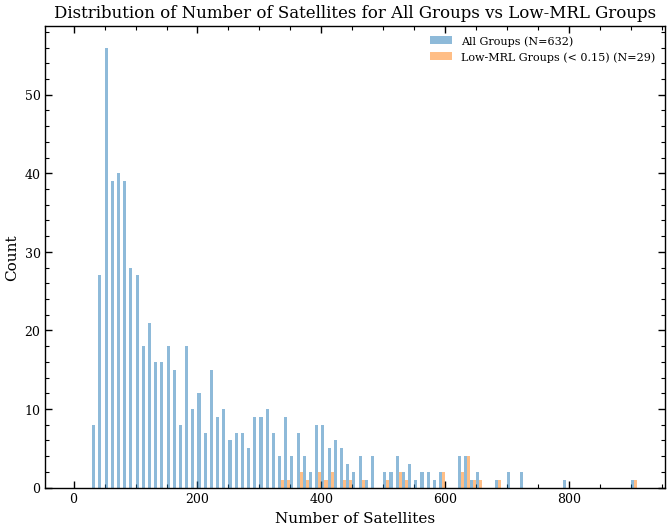

In [24]:
#get all the galaxy groups with MRL values below 0.2 and plot histogram of num satellites for those groups, and compare to the histogram of num satellites for all groups
low_MRL_groups = []
for group_index, inconsistentProjections in gg_indices_inconsistent.items():
    for proj in inconsistentProjections:
        idx = proj_to_idx[proj]
        val = MRL_values[group_index * 3 + idx]
        if np.isfinite(val) and val < 0.1:
            low_MRL_groups.append(filtered_gt14.getAllGalaxyGroups()[group_index])
            # if len(filtered_gt14.getAllGalaxyGroups()[group_index].getSatelliteSubhalos()) < 400:
                # print(f"Group {group_index} with MRL {val:.3f} has {len(filtered_gt14.getAllGalaxyGroups()[group_index].getSatelliteSubhalos())} satellites")
            break  # only need to add the group once even if multiple projections are inconsistent
all_num_satellites = [len(gg.getSatelliteSubhalos()) for gg in filtered_gt14.getAllGalaxyGroups()]
low_MRL_num_satellites = [len(gg.getSatelliteSubhalos()) for gg in low_MRL_groups]
print(min(low_MRL_num_satellites))
bin = np.arange(0, max(all_num_satellites) + 10, 10)
xlabel = 'Number of Satellites'
ylabel = 'Count'
title = 'Distribution of Number of Satellites for All Groups vs Low-MRL Groups'
all_bins, all_bin_centers, _ = ListGalaxyGroup.get_histogram_bins(all_num_satellites, bins=bin, errorbarType='poisson', density=False)
low_MRL_bins, low_MRL_bin_centers, _ = ListGalaxyGroup.get_histogram_bins(low_MRL_num_satellites, bins=bin, errorbarType='poisson', density=False)
hist_plotter = AstroPlotter()
hist_fig, hist_ax = hist_plotter.create_figure(ncols=1, nrows=1, figsize=(8, 6))
hist_ax.bar(all_bin_centers - 2.5, all_bins, width=5, alpha=0.5, label=f'All Groups (N={len(all_num_satellites)})')
hist_ax.bar(low_MRL_bin_centers + 2.5, low_MRL_bins, width=5, alpha=0.5, label=f'Low-MRL Groups (< 0.1) (N={len(low_MRL_num_satellites)})')
hist_ax.set_xlabel(xlabel)
hist_ax.set_ylabel(ylabel)
hist_ax.set_title(title)

hist_ax.legend(fontsize=8)

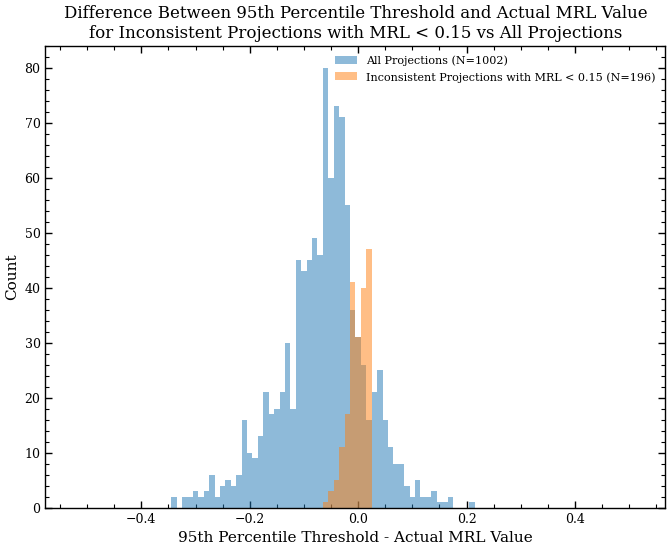

In [25]:
#plot a histogram of the difference of the random MRL confidence threshold minus the actual MRL value for the inconsistent projections with MRL < 0.2, to see how far below the threshold they are
#also plot threshold minus actual MRL for all galaxy groups
threshold_minus_actual_low_MRL = []
threshold_minus_actual_all = []
for group_index, inconsistentProjections in gg_indices_inconsistent.items():
    group_mrl = np.asarray(MRL_values[group_index * 3 : group_index * 3 + 3], dtype=float)
    group_rand = np.asarray(random_MRL_values[group_index], dtype=float)
    thresh = float(np.percentile(group_rand, percentageMRL))

    for proj in projections_all:
        idx = proj_to_idx[proj]
        val = group_mrl[idx]
        if not np.isfinite(val):
            continue
        diff = thresh - val
        threshold_minus_actual_all.append(diff)
        if proj in inconsistentProjections and val < 0.15:
            threshold_minus_actual_low_MRL.append(diff)
            
bin = np.arange(-0.5, 0.5, 0.01)
xlabel = '95th Percentile Threshold - Actual MRL Value'
ylabel = 'Count'
title = f'Difference Between 95th Percentile Threshold and Actual MRL Value\nfor Inconsistent Projections with MRL < 0.15 vs All Projections'
diff_low_MRL_bin_values, diff_low_MRL_bin_centers, _ = ListGalaxyGroup.get_histogram_bins(threshold_minus_actual_low_MRL, bins=bin, errorbarType='poisson', density=False)
diff_all_bin_values, diff_all_bin_centers, _ = ListGalaxyGroup.get_histogram_bins(threshold_minus_actual_all, bins=bin, errorbarType='poisson', density=False)
diff_plotter = AstroPlotter()
diff_fig, diff_ax = diff_plotter.create_figure(ncols=1, nrows=1, figsize=(8, 6))
diff_ax.bar(diff_all_bin_centers - 0.025, diff_all_bin_values, width=0.01, alpha=0.5, label=f'All Projections (N={len(threshold_minus_actual_all)})')
diff_ax.bar(diff_low_MRL_bin_centers + 0.025, diff_low_MRL_bin_values, width=0.01, alpha=0.5, label=f'Inconsistent Projections with MRL < 0.15 (N={len(threshold_minus_actual_low_MRL)})')
diff_ax.set_xlabel(xlabel)
diff_ax.set_ylabel(ylabel)
diff_ax.set_title(title)
diff_ax.legend(fontsize=8)


#### maybe a threshold is better

In [26]:
#recalculate the random MRL distribution with 100,000 samples and plot histogram of the difference of the original threshold (with 100,000 samples) minus the new threshold (with 100,000 samples) of each galaxy group
new_random_MRL_values = []
for group_index in range(len(filtered_gt14.getAllGalaxyGroups())):
    num_non_centrals = len(filtered_gt14.getAllGalaxyGroups()[group_index].getSatelliteSubhalos())
    group_rand = ListGalaxyGroup.compute_an_MRL_distribution_curves(num_samples=10000, num_non_centrals=num_non_centrals)
    new_random_MRL_values.append(group_rand)
threshold_differences = []
for group_index in range(len(filtered_gt14.getAllGalaxyGroups())):
    original_thresh = float(np.percentile(random_MRL_values[group_index], percentageMRL))
    new_thresh = float(np.percentile(new_random_MRL_values[group_index], percentageMRL))
    diff = new_thresh - original_thresh
    threshold_differences.append(diff)


Text(0.5, 1.0, 'Difference Between New and Original 95th Percentile Thresholds\nfor All Galaxy Groups')

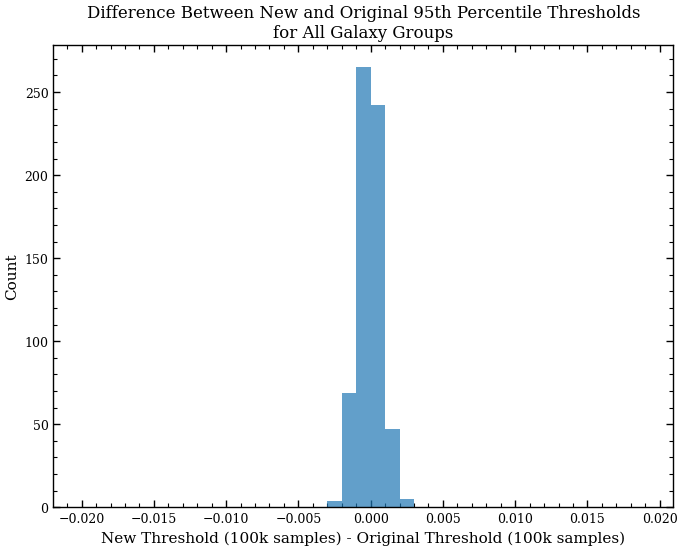

In [30]:
bin = np.arange(-0.02, 0.02, 0.001)
xlabel = 'New Threshold (100k samples) - Original Threshold (100k samples)'
ylabel = 'Count'
title = 'Difference Between New and Original 95th Percentile Thresholds\nfor All Galaxy Groups'
threshold_diff_bin_values, threshold_diff_bin_centers, _ = ListGalaxyGroup.get_histogram_bins(threshold_differences, bins=bin, errorbarType='poisson', density=False)
threshold_diff_plotter = AstroPlotter()
threshold_diff_fig, threshold_diff_ax = threshold_diff_plotter.create_figure(ncols=1, nrows=1, figsize=(8, 6))
threshold_diff_ax.bar(threshold_diff_bin_centers, threshold_diff_bin_values, width=0.001, alpha=0.7)
threshold_diff_ax.set_xlabel(xlabel)
threshold_diff_ax.set_ylabel(ylabel)
threshold_diff_ax.set_title(title)

With new criterion (MRL > threshold - 0.01), number of inconsistent projections: 822
With new criterion, number of inconsistent projections with MRL < 0.2: 483


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


((<Figure size 800x600 with 1 Axes>,
  <Axes: title={'center': 'Pairwise Polar Difference Distribution (TNG300-1, TNG-Cluster;\n632 groups; 95th-percentile MRL criterion)'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>),
 (<Figure size 800x600 with 1 Axes>,
  <Axes: title={'center': 'MRL Value Distribution for TNG300-1, TNG-CLuster Combined\nGalaxy Groups, Consistent vs Inconsistent Projections'}, xlabel='MRL Value', ylabel='Probability Density'>),
 {0: ['xy', 'xz', 'yz'],
  1: ['xy', 'xz', 'yz'],
  2: ['xy', 'yz'],
  3: ['xz', 'yz'],
  4: ['yz'],
  5: ['xy', 'xz', 'yz'],
  6: ['xy', 'xz'],
  9: ['yz'],
  12: ['xy', 'xz', 'yz'],
  15: ['xy'],
  17: ['xy', 'xz', 'yz'],
  20: ['xy', 'yz'],
  23: ['xy', 'yz'],
  25: ['xy', 'yz'],
  27: ['xy', 'yz'],
  29: ['xy', 'xz', 'yz'],
  30: ['xy', 'xz', 'yz'],
  33: ['xy'],
  39: ['yz'],
  40: ['xy', 'xz', 'yz'],
  42: ['yz'],
  50: ['xz'],
  52: ['xy', 'yz'],
  53: ['yz'],
  54: ['xy', 'yz'],
  58: ['xz', 'yz'],
  60

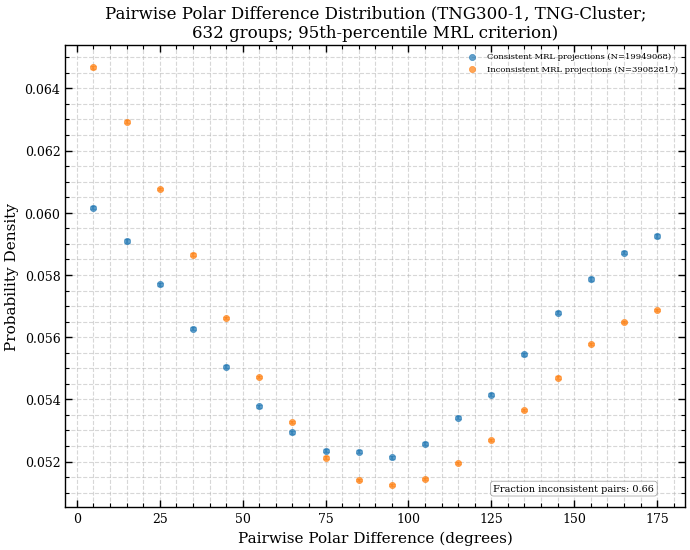

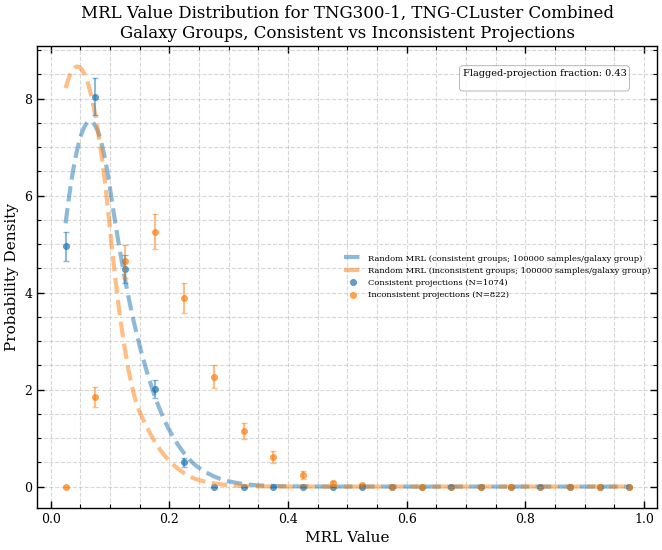

In [31]:
#it seems it still hard to converge even at 100,000 samples, so run the random MRL distribution with 10,000 samples and consider a galaxy group to have an inconsistent projection if its within some tolerance of the 95th percentile threshold, say 0.05, and see how many inconsistent projections we get with this new criterion, and how many of them have MRL < 0.2
tolerance = 0.01
new_gg_indices_inconsistent = {}
for group_index, galaxyGroup in enumerate(filtered_gt14.getAllGalaxyGroups()):
    group_mrl = np.asarray(MRL_values[group_index * 3 : group_index * 3 + 3], dtype=float)
    group_rand = np.asarray(random_MRL_values[group_index], dtype=float)
    thresh = float(np.percentile(group_rand, percentageMRL))

    inconsistentProjections = []
    for proj in projections_all:
        idx = proj_to_idx[proj]
        val = group_mrl[idx]
        if not np.isfinite(val):
            continue
        if val > thresh - tolerance:
            inconsistentProjections.append(proj)
    if inconsistentProjections:
        new_gg_indices_inconsistent[group_index] = inconsistentProjections
new_inconsistent_low_MRL_count = 0
for group_index, inconsistentProjections in new_gg_indices_inconsistent.items():
    for proj in inconsistentProjections:
        idx = proj_to_idx[proj]
        val = MRL_values[group_index * 3 + idx]
        if np.isfinite(val) and val < 0.2:
            new_inconsistent_low_MRL_count += 1
print(f"With new criterion (MRL > threshold - {tolerance}), number of inconsistent projections: {sum(len(projs) for projs in new_gg_indices_inconsistent.values())}")
print(f"With new criterion, number of inconsistent projections with MRL < 0.2: {new_inconsistent_low_MRL_count}")

#plot consistentInconsistentPolarMRLPlots for the new inconsistent projections defined by the new criterion, and see if the polar difference distribution looks different for these new inconsistent projections compared to the consistent projections
getConsistentInconsistentPolarMRLPlots(
    list_gg = filtered_gt14,
    snapshot = galaxyAnalysisSnapshot,
    percentConfidenceMRL = percentageMRL,
    gg_indices_inconsistent = new_gg_indices_inconsistent,
)

In [35]:
# assymetry of original and of new gg_indices_inconsistent
original_inconsistent_counts = [len(projs) for projs in gg_indices_inconsistent.values()]
new_inconsistent_counts = [len(projs) for projs in new_gg_indices_inconsistent.values()]
print(f"Original inconsistent projection counts per group: {original_inconsistent_counts}")
print(f"New inconsistent projection counts per group: {new_inconsistent_counts}")
# getConsistentInconsistentAssymetryPlots(
#     list_gg = filtered_gt14,
#     snapshot = galaxyAnalysisSnapshot,
#     percentConfidenceMRL = percentageMRL,
#     gg_indices_inconsistent = gg_indices_inconsistent,
# )
# getConsistentInconsistentAssymetryPlots(
#     list_gg = filtered_gt14,
#     snapshot = galaxyAnalysisSnapshot,
#     percentConfidenceMRL = percentageMRL,
#     gg_indices_inconsistent = new_gg_indices_inconsistent,
# )

Original inconsistent projection counts per group: [1, 3, 2, 2, 1, 2, 2, 1, 3, 1, 3, 2, 2, 2, 2, 2, 3, 1, 3, 1, 1, 2, 2, 2, 2, 3, 2, 1, 3, 1, 1, 2, 2, 2, 3, 2, 3, 1, 2, 2, 3, 1, 3, 3, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 1, 2, 1, 2, 1, 1, 2, 3, 1, 1, 1, 1, 2, 3, 2, 2, 1, 2, 3, 2, 2, 2, 3, 3, 2, 3, 2, 3, 3, 3, 2, 1, 3, 2, 3, 1, 2, 1, 1, 1, 2, 1, 2, 2, 3, 1, 2, 2, 2, 2, 3, 2, 2, 1, 2, 2, 3, 2, 3, 3, 2, 2, 3, 3, 3, 3, 3, 2, 3, 1, 3, 1, 2, 3, 1, 3, 3, 2, 3, 1, 3, 3, 3, 1, 3, 3, 2, 1, 3, 3, 1, 3, 3, 3, 1, 2, 3, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 1, 2, 2, 3, 1, 2, 2, 3, 2, 2, 1, 2, 2, 1, 3, 3, 1, 3, 3, 3, 2, 3, 2, 1, 2, 3, 3, 3, 3, 3, 2, 3, 2, 3, 3, 3, 3, 1, 2, 2, 3, 2, 2, 1, 1, 3, 1, 1, 2, 3, 3, 2, 3, 1, 3, 1, 3, 2, 2, 3, 2, 3, 1, 2, 3, 1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 3, 2, 2, 2, 2, 2, 3, 3, 2, 1, 1, 3, 2, 3, 3, 2, 2, 2, 3, 3, 3, 2, 2, 2, 3, 3, 2, 1, 2, 3, 2, 1, 1, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3, 2, 3, 3, 3, 2, 3, 3, 3, 3, 1, 1, 3, 3, 2, 2, 3, 3, 3, 3, 3, 1, 1, 3, 2, 2, 3, 3, 3, 3, 2, 2, 1, 3, 2, 3, 

### snapshot 50

In [27]:
#get the subhalos which are inconsistent with random
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(50)
random_MRL_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=1000) # 1000 samples for each subhalo, for the three different projection angles #i.e. total of 3000 random MRL values for each subhalo, for the three different projection angles
MRL_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_probablity_distribution_of_MRL_directionality(parallelize=False) #three MRL values for each subhalo, for the three different projection angles

(fraction, count, total, gg_indices_inconsistent) = GalaxyAnalysis.calculate_fraction_less_than_percentile(MRL_values=MRL_values, random_MRL_values=random_MRL_values, percentile=95)
# print(len(gg_indices_inconsistent), gg_indices_inconsistent)
# print(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups())

final: [np.float64(0.21950132912741394), np.float64(0.1909765970003609), np.float64(0.09771630873771779)]s
final: [np.float64(0.1466120670381405), np.float64(0.1394453313515473), np.float64(0.1387503304018235)]


In [28]:
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
from myproject.redshiftGalaxyAnalysis import GalaxyAnalysis
print(gg_indices_inconsistent)
print(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups())
#see what are the properties of the gg which are inconsistent with random at 99 percentile, and see if they have any common properties among their subhalos which might be driving the lopsidedness in the polar pairwise distribution, and also see if they have any common properties among themselves (e.g. mass, redshift, number of subhalos, etc.)
high_galaxy_groups = []
non_high_galaxy_groups = []
for i, gg in enumerate(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups()):
    if i not in gg_indices_inconsistent:
        print(f'Galaxy Group {i} is consistent with random at 95 percentile')
        non_high_galaxy_groups.append(gg)
        continue
    high_galaxy_groups.append(gg)

[0, 1, 3, 4, 5, 7, 9, 10, 11, 12, 13, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 27, 29, 30, 31, 32, 33, 35, 37, 38, 41, 42, 44, 45, 46, 49, 51, 52, 53, 55, 56, 57, 58, 60, 61, 63, 64, 66, 67, 68, 69, 70, 71, 72, 74, 75, 78, 80, 83, 85, 86, 87, 88, 89, 90, 91, 92, 93, 95, 96, 97, 99, 100, 102, 104, 105, 106, 107, 109, 110, 111, 112, 115, 117, 119, 120, 121, 122, 124, 126, 127, 128, 129, 130, 131, 132, 135, 136]
137
Galaxy Group 2 is consistent with random at 95 percentile
Galaxy Group 6 is consistent with random at 95 percentile
Galaxy Group 8 is consistent with random at 95 percentile
Galaxy Group 14 is consistent with random at 95 percentile
Galaxy Group 17 is consistent with random at 95 percentile
Galaxy Group 26 is consistent with random at 95 percentile
Galaxy Group 28 is consistent with random at 95 percentile
Galaxy Group 34 is consistent with random at 95 percentile
Galaxy Group 36 is consistent with random at 95 percentile
Galaxy Group 39 is consistent with random at 95 percenti

high len: 98
nonhigh len: 39
COMPUTING FOR redshift index: 0, label: High GG (Inconsistent at 95% CL) Snapshot 50
Total Galaxy Groups to process: 98 with pairs : 2425221
Progress: Processing Galaxy Group ID 9381209, 98 / 9880.05
COMPUTING FOR redshift index: 0, label: Non-High GG (Consistent at 95% CL) Snapshot 50
Total Galaxy Groups to process: 39 with pairs : 746771
Progress: Processing Galaxy Group ID 9062442, 39 / 3990.1

now plotting MRL

running label with list: 98
final: [np.float64(0.21950132912741394), np.float64(0.1909765970003609), np.float64(0.09771630873771779)]
final: [np.float64(0.1466120670381405), np.float64(0.1394453313515473), np.float64(0.1387503304018235)]
Fraction of MRL values below the 95th percentile of random MRL values: 0.2585 (76/294)ith 191 satellites
running label with list: 39
Fraction of MRL values below the 95th percentile of random MRL values: 0.9915 (116/117)th 154 satellites


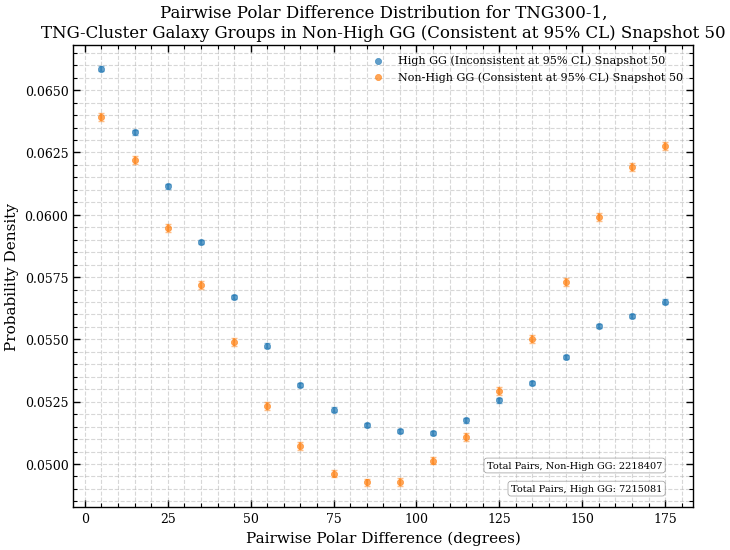

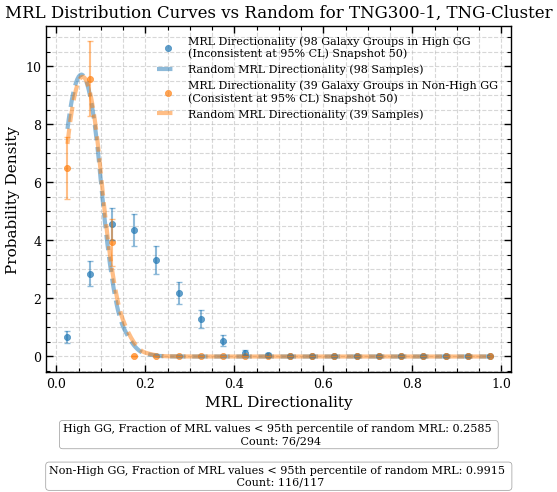

In [30]:
high_list_galaxy_groups = ListGalaxyGroup(high_galaxy_groups)
non_high_list_galaxy_groups = ListGalaxyGroup(non_high_galaxy_groups)
print(f"high len: {len(high_list_galaxy_groups.getAllGalaxyGroups())}")
print(f"nonhigh len: {len(non_high_list_galaxy_groups.getAllGalaxyGroups())}")

#plot polar pairwise distribution for the high galaxy groups and the non-high galaxy groups, and see if the lopsidedness in the polar pairwise distribution is being really driven by just a few (which we won't see in mrl since its cluster by cluster).
high_nonhigh_polar_plot, high_nonhigh_fig, high_nonhigh_ax = galaxyAnalysisSnapshot.overlay_polar_pairwise_across_redshifts([
    [(high_list_galaxy_groups, "High GG (Inconsistent at 95% CL) Snapshot 50"),
    (non_high_list_galaxy_groups, "Non-High GG (Consistent at 95% CL) Snapshot 50")]],
    oneaxis=True, 
    include_metrics=True,
)

high_nonhigh_ax.legend(fontsize=8)

print("\nnow plotting MRL\n")

#plot MRL
high_nonhigh_MRL_plot, high_nonhigh_MRL_fig, high_nonhigh_MRL_ax = galaxyAnalysisSnapshot.overlayMRLAndMRLRandom([
    (high_list_galaxy_groups, "High GG \n(Inconsistent at 95% CL) Snapshot 50"),
    (non_high_list_galaxy_groups, "Non-High GG \n(Consistent at 95% CL) Snapshot 50")],
    filename='mrl_difference_high_nonhigh_snapshot_50', oneaxis=True, savefig=False, percentageMRL=95
)



### separate by mass bins

running over massbin i: 0xy Group 98 / 98 with 428 satellitesfor Galaxy Group 98 / 98 with 428 satellitesess
getting polarMRL plots now


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


running over massbin i: 1om MRL distribution, samples:10000, for Galaxy Group 2141 / 2141 with 13 satellites
getting polarMRL plots now
running over massbin i: 2om MRL distribution, samples:10000, for Galaxy Group 684 / 684 with 13 satellites
getting polarMRL plots now
running over massbin i: 3om MRL distribution, samples:10000, for Galaxy Group 185 / 185 with 60 satellitess
getting polarMRL plots now
running over massbin i: 4om MRL distribution, samples:10000, for Galaxy Group 95 / 95 with 328 satelliteses
getting polarMRL plots now
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/combinedTNG300-1_TNGCluster/polar_pairwise_difference_distribution_by_mass_bin_for_high_vs_nonhigh_galaxy_groups_TNG300-1, TNG-Cluster
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/combinedTNG300-1_TNGCluster/MRL_value_distribution_by_mass_bin_for_high_vs_nonhigh_galaxy_groups_TNG300-1, TNG-Cluster


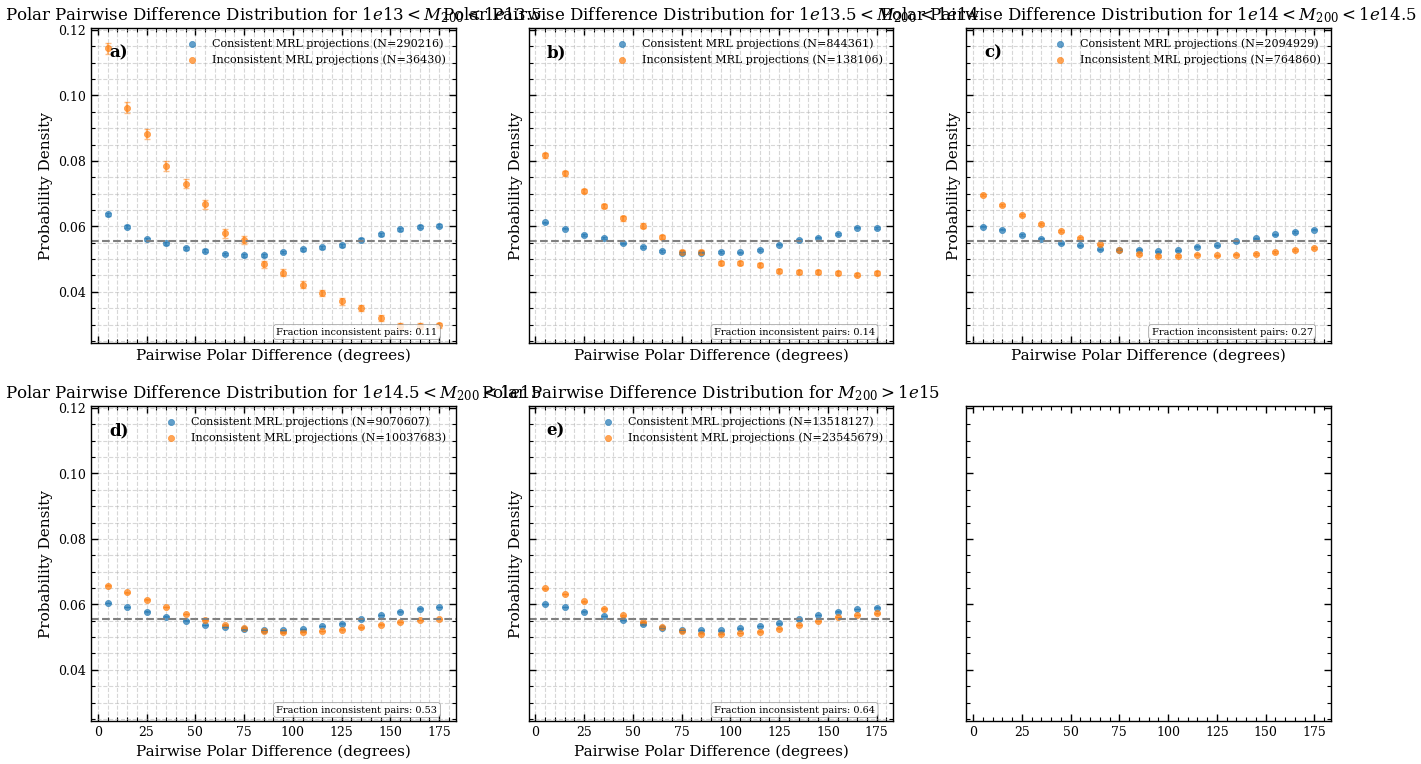

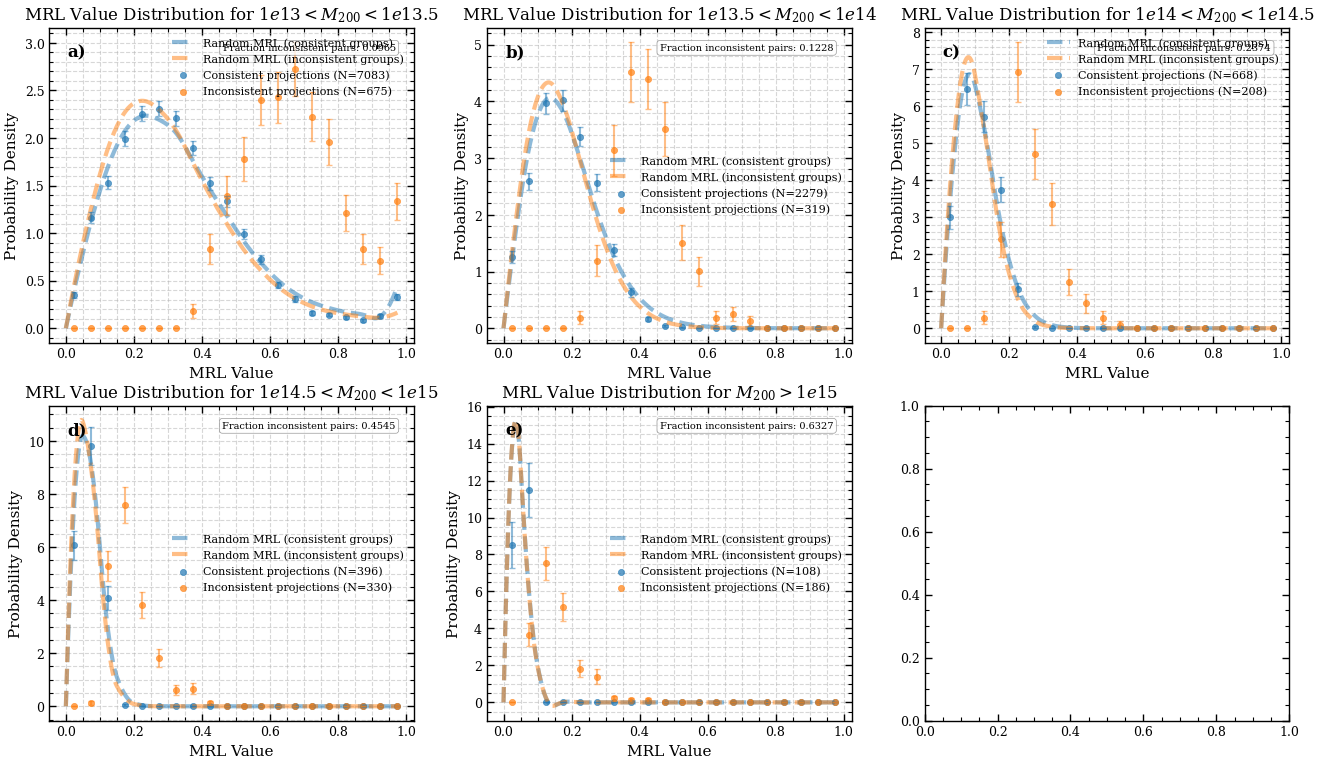

In [21]:
#do but separate for each mass bin, and see if the high vs non-high difference is being driven by a particular mass bin
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
mass_bin_labels = ['$1e13<M_{200}<1e13.5$', '$1e13.5<M_{200}<1e14$', '$1e14<M_{200}<1e14.5$', '$1e14.5<M_{200}<1e15$', '$M_{200}>1e15$']
mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
random_MRL_values_by_mass_bin = []
MRL_values_by_mass_bin = []
for mass_bin in mass_bins:
    random_MRL_values = mass_bin.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=10000) # 1000 samples for each subhalo, for the three different projection angles #i.e. total of 3000 random MRL values for each subhalo, for the three different projection angles
    MRL_values = mass_bin.compute_probablity_distribution_of_MRL_directionality(parallelize=False) #three MRL values for each subhalo, for the three different projection angles
    random_MRL_values_by_mass_bin.append(random_MRL_values)
    MRL_values_by_mass_bin.append(MRL_values)
    
inconsistent_galaxy_groups_by_mass_bin = []
consistent_galaxy_groups_by_mass_bin = []
#plot multipanel with getConsistentInconsistentPolarMRLPlots
plotter_polar_by_mass = AstroPlotter()
plotter_fig_polar_by_mass, axes_polar_by_mass = plotter_polar_by_mass.create_figure(ncols=3, nrows=2, figsize=(16, 9), sharex=True, sharey=True)
plotter_mrl_by_mass = AstroPlotter()
plotter_fig_mrl_by_mass, axes_mrl_by_mass = plotter_mrl_by_mass.create_figure(ncols=3, nrows=2, figsize=(16, 9), sharex=False, sharey=False)
    
for i, mass_bin in enumerate(mass_bins):
    print(f"running over massbin i: {i}")
    (fraction, count, total, gg_indices_inconsistent) = GalaxyAnalysis.calculate_fraction_less_than_percentile(MRL_values=MRL_values_by_mass_bin[i], random_MRL_values=random_MRL_values_by_mass_bin[i], percentile=95)
    high_galaxy_groups = []
    non_high_galaxy_groups = []
    for j, gg in enumerate(mass_bin.getAllGalaxyGroups()):
        if j not in gg_indices_inconsistent.keys():
            non_high_galaxy_groups.append(gg)
            continue
        high_galaxy_groups.append(gg)

    high_list_galaxy_groups = ListGalaxyGroup(high_galaxy_groups)
    non_high_list_galaxy_groups = ListGalaxyGroup(non_high_galaxy_groups)
    
    inconsistent_galaxy_groups_by_mass_bin.append(high_list_galaxy_groups)
    consistent_galaxy_groups_by_mass_bin.append(non_high_list_galaxy_groups)
    
    print("getting polarMRL plots now")
    getConsistentInconsistentPolarMRLPlots(
        list_gg=mass_bin,
        snapshot=99,
        percentConfidenceMRL=95,
        gg_indices_inconsistent=gg_indices_inconsistent,
        mrl_values=MRL_values_by_mass_bin[i],
        numsamples_random_mrl=10000,
        polar_plotter=plotter_polar_by_mass,
        polar_ax=axes_polar_by_mass.flatten()[i],
        mrl_plotter=plotter_mrl_by_mass,
        mrl_ax=axes_mrl_by_mass.flatten()[i],
        random_MRL_values=random_MRL_values_by_mass_bin[i],
        polar_title=f'Polar Pairwise Difference Distribution for {mass_bin_labels[i]}',
        mrl_title=f'MRL Value Distribution for {mass_bin_labels[i]}',
    )

# add a), b), c) annotations to the polar plots
for i in range(len(mass_bins)):
    axes_polar_by_mass.flatten()[i].text(0.05, 0.95, f'{chr(97+i)})', transform=axes_polar_by_mass.flatten()[i].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    axes_mrl_by_mass.flatten()[i].text(0.05, 0.95, f'{chr(97+i)})', transform=axes_mrl_by_mass.flatten()[i].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')

plotter_polar_by_mass.save_figure(plotter_fig_polar_by_mass, galaxyAnalysisSnapshot.scratchPlotDirc + f'/polar_pairwise_difference_distribution_by_mass_bin_for_high_vs_nonhigh_galaxy_groups_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}')
plotter_mrl_by_mass.save_figure(plotter_fig_mrl_by_mass, galaxyAnalysisSnapshot.scratchPlotDirc + f'/MRL_value_distribution_by_mass_bin_for_high_vs_nonhigh_galaxy_groups_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}')

processing snapshot: (99, 0, 'z0p0')72 / 1872 with 20 satellitesGalaxy Group 1872 / 1872 with 20 satellites
processing snapshot: (91, 0.1, 'z0p1') / 2586 with 13 satellites Galaxy Group 2586 / 2586 with 13 satellites
processing snapshot: (84, 0.2, 'z0p2') / 2585 with 9 satellitess Galaxy Group 2585 / 2585 with 9 satellitess
processing snapshot: (78, 0.3, 'z0p3') / 2587 with 18 satellites Galaxy Group 2587 / 2587 with 18 satellites
processing snapshot: (72, 0.4, 'z0p4') / 2552 with 29 satellites Galaxy Group 2552 / 2552 with 29 satellites


processing snapshot: (67, 0.5, 'z0p5') / 2467 with 13 satellites Galaxy Group 2467 / 2467 with 13 satellites
processing snapshot: (59, 0.7, 'z0p7') / 2370 with 9 satellitess Galaxy Group 2370 / 2370 with 9 satellitess
processing snapshot: (50, 1.0, 'z1p0') / 2196 with 13 satellites Galaxy Group 2196 / 2196 with 13 satellites
Total Galaxy Groups to process: 450 with pairs : 27012satellites Galaxy Group 1872 / 1872 with 20 satellites
Progress: Processing Galaxy Group ID 970, 450 / 4500Total Galaxy Groups to process: 2136 with pairs : 104296
Progress: Processing Galaxy Group ID 993, 2136 / 21366Total Galaxy Groups to process: 464 with pairs : 32343
Progress: Processing Galaxy Group ID 961, 464 / 4644Total Galaxy Groups to process: 2121 with pairs : 117372
Progress: Processing Galaxy Group ID 996, 2121 / 21211Total Galaxy Groups to process: 518 with pairs : 41302
Progress: Processing Galaxy Group ID 997, 518 / 5188Total Galaxy Groups to process: 2069 with pairs : 128645
Progress: Processin

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


processing snapshot: (99, 0, 'z0p0')3 / 543 with 51 satellitess Galaxy Group 543 / 543 with 51 satellitess
processing snapshot: (91, 0.1, 'z0p1')/ 866 with 13 satellitesor Galaxy Group 866 / 866 with 13 satellites
processing snapshot: (84, 0.2, 'z0p2')/ 872 with 24 satellitesor Galaxy Group 872 / 872 with 24 satellites
processing snapshot: (78, 0.3, 'z0p3')/ 831 with 31 satellitesor Galaxy Group 831 / 831 with 31 satellites
processing snapshot: (72, 0.4, 'z0p4')/ 816 with 21 satellitesor Galaxy Group 816 / 816 with 21 satellites
processing snapshot: (67, 0.5, 'z0p5')/ 758 with 22 satellitesor Galaxy Group 758 / 758 with 22 satellites
processing snapshot: (59, 0.7, 'z0p7')/ 750 with 25 satellitesor Galaxy Group 750 / 750 with 25 satellites
processing snapshot: (50, 1.0, 'z1p0')/ 660 with 25 satellitesor Galaxy Group 660 / 660 with 25 satellites
Total Galaxy Groups to process: 183 with pairs : 84410tellitessr Galaxy Group 543 / 543 with 51 satellitess
Progress: Processing Galaxy Group ID

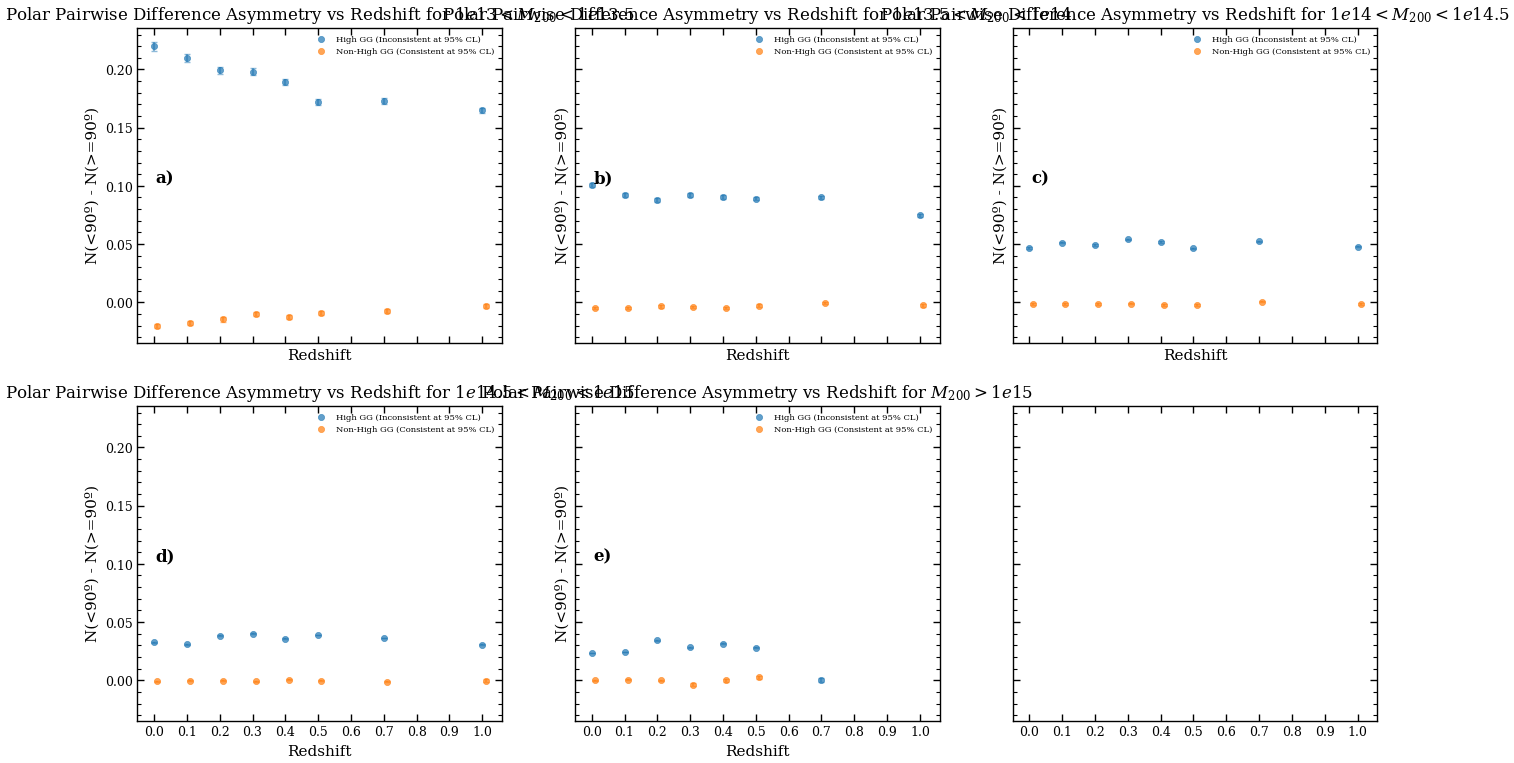

In [10]:
# Replicate Cell 55, but for each mass bin.
# For each snapshot and each mass bin:
#   1) compute MRL inconsistency indices
#   2) split into High vs Non-High
#   3) plot polar asymmetry (N(<90) - N(>=90)) vs redshift

mass_bin_labels = [
    "$1e13<M_{200}<1e13.5$",
    "$1e13.5<M_{200}<1e14$",
    "$1e14<M_{200}<1e14.5$",
    "$1e14.5<M_{200}<1e15$",
    "$M_{200}>1e15$",
]

mass_bin_getters = [
    lambda ga: ga.filtered_gt13_ls13p5_list_of_galaxy_groups,
    lambda ga: ga.filtered_gt13p5_ls14_list_of_galaxy_groups,
    lambda ga: ga.filtered_gt14_ls14p5_list_of_galaxy_groups,
    lambda ga: ga.filtered_gt14p5_ls15_list_of_galaxy_groups,
    lambda ga: ga.filtered_gt15_list_of_galaxy_groups,
]

plotter_polar_asymmetry_by_mass = AstroPlotter()
fig_polar_asymetry_by_mass, ax_polar_asymmetry_by_mass = plotter_polar_asymmetry_by_mass.create_figure(ncols=3, nrows=2, figsize=(16, 9), sharex=True, sharey=True)

for bin_i, (mass_label, get_mass_bin) in enumerate(zip(mass_bin_labels, mass_bin_getters)):
    redshifts = []
    redshift_gg_bins: list[list[ListGalaxyGroup]] = []

    for snapshot_enum in allSnapshotEnums:
        snapshot_num = snapshot_enum[0]
        galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot_num)

        mass_bin = get_mass_bin(galaxyAnalysisSnapshot)
        if mass_bin.getNumGalaxyGroups() == 0:
            continue

        random_MRL_values = mass_bin.compute_MRL_random_distribution_curves_for_LGG(
            parallelize=False,
            num_samples=1000,
        )
        MRL_values = mass_bin.compute_probablity_distribution_of_MRL_directionality(
            parallelize=False
        )

        (fraction, count, total, gg_indices_inconsistent) = GalaxyAnalysis.calculate_fraction_less_than_percentile(
            MRL_values=MRL_values,
            random_MRL_values=random_MRL_values,
            percentile=95,
        )

        high_galaxy_groups = []
        non_high_galaxy_groups = []
        inconsistent_set = set(gg_indices_inconsistent)
        for i, gg in enumerate(mass_bin.getAllGalaxyGroups()):
            if i in inconsistent_set:
                high_galaxy_groups.append(gg)
            else:
                non_high_galaxy_groups.append(gg)

        high_list_galaxy_groups = ListGalaxyGroup(high_galaxy_groups)
        non_high_list_galaxy_groups = ListGalaxyGroup(non_high_galaxy_groups)

        redshifts.append(snapshot_enum[1])
        redshift_gg_bins.append([high_list_galaxy_groups, non_high_list_galaxy_groups])

    if len(redshifts) == 0:
        print(f"Skipping {mass_label}: no groups across snapshots")
        continue

    #use getConsistentInconsistentAssymetryPlots
    getConsistentInconsistentAssymetryPlots(
        listRedshiftGalaxyAnalysis=listRedshiftGalaxyAnalysis,
        allSnapshotEnums=allSnapshotEnums,
        mass_bin_getter=get_mass_bin,
        mass_bin_label=mass_label,
        percentageMRL=95,
        ax=ax_polar_asymmetry_by_mass.flatten()[bin_i],
        fig=fig_polar_asymetry_by_mass,
        plotter = plotter_polar_asymmetry_by_mass,
        title=f"Polar Pairwise Difference Asymmetry vs Redshift for {mass_label}",
    )

#add a), b), c) annotations to the polar asymmetry plots
for i in range(len(mass_bin_labels)):
    ax_polar_asymmetry_by_mass.flatten()[i].text(0.05, 0.55, f'{chr(97+i)})', transform=ax_polar_asymmetry_by_mass.flatten()[i].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')

plotter_polar_asymmetry_by_mass.save_figure(
    fig_polar_asymetry_by_mass,
    galaxyAnalysisSnapshot.scratchPlotDirc + f'/polar_pairwise_difference_asymmetry_vs_redshift_by_mass_bin_for_high_vs_nonhigh_galaxy_groups_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}'
)

### assymetry of high vs nonhigh

Total Galaxy Groups to process: 333 with pairs : 14694924llites Galaxy Group 312 / 312 with 191 satellites
Progress: Processing Galaxy Group ID 9956048, 333 / 3333Total Galaxy Groups to process: 299 with pairs : 5105727
Progress: Processing Galaxy Group ID 9819553, 299 / 2999Total Galaxy Groups to process: 332 with pairs : 12893752
Progress: Processing Galaxy Group ID 9995792, 332 / 3322Total Galaxy Groups to process: 270 with pairs : 4675437
Progress: Processing Galaxy Group ID 10060723, 270 / 270Total Galaxy Groups to process: 310 with pairs : 11241510
Progress: Processing Galaxy Group ID 10050921, 310 / 310Total Galaxy Groups to process: 267 with pairs : 4500729
Progress: Processing Galaxy Group ID 10118255, 267 / 267Total Galaxy Groups to process: 319 with pairs : 11392176
Progress: Processing Galaxy Group ID 9951187, 319 / 3199Total Galaxy Groups to process: 230 with pairs : 2991229
Progress: Processing Galaxy Group ID 9736794, 230 / 2300Total Galaxy Groups to process: 321 with pa

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/polar_pairwise_difference_vs_redshift_for_high_vs_nonhigh_galaxy_groups_TNG300-1, TNG-Cluster


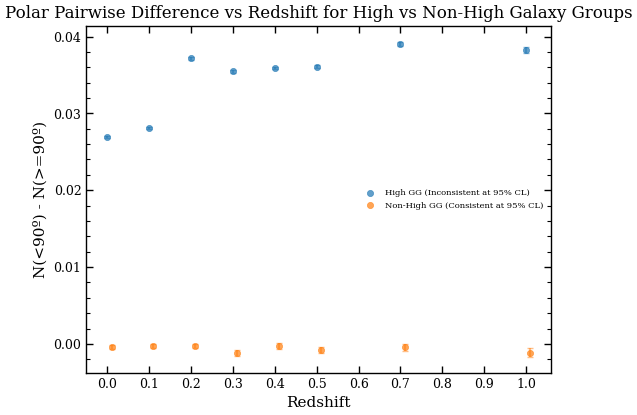

In [16]:
#make assymetry plots for the high galaxy groups and the non-high galaxy groups
# for snapshot_num in [50, 99]:
redshifts = []
redshift_mass_bins : list[list[ListGalaxyGroup]]= []

for snapshot_enum in allSnapshotEnums:
    snapshot_num = snapshot_enum[0]
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot_num)
    random_MRL_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=1000) # 1000 samples for each subhalo, for the three different projection angles #i.e. total of 3000 random MRL values for each subhalo, for the three different projection angles
    MRL_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_probablity_distribution_of_MRL_directionality(parallelize=False) #three MRL values for each subhalo, for the three different projection angles

    (fraction, count, total, gg_indices_inconsistent) = GalaxyAnalysis.calculate_fraction_less_than_percentile(MRL_values=MRL_values, random_MRL_values=random_MRL_values, percentile=95)
    high_galaxy_groups = []
    non_high_galaxy_groups = []
    for i, gg in enumerate(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups()):
        if i not in gg_indices_inconsistent:
            non_high_galaxy_groups.append(gg)
            continue
        high_galaxy_groups.append(gg)

    high_list_galaxy_groups = ListGalaxyGroup(high_galaxy_groups)
    non_high_list_galaxy_groups = ListGalaxyGroup(non_high_galaxy_groups)
    
    redshifts.append(snapshot_enum[1])
    redshift_mass_bins.append([high_list_galaxy_groups, non_high_list_galaxy_groups])
polarPairwiseDifference_plotter, polarPairwiseDifference_fig, polarPairwiseDifference_ax, polar_pairwise_by_type_by_redshift = asymetryPlots(redshifts, listRedshiftGG=redshift_mass_bins, listGGLabels=['High GG (Inconsistent at 95% CL)', 'Non-High GG (Consistent at 95% CL)'], plotRows=1, plotCols=1)
polarPairwiseDifference_ax.set_title('Polar Pairwise Difference vs Redshift for High vs Non-High Galaxy Groups')
polarPairwiseDifference_plotter.save_figure(polarPairwiseDifference_fig, galaxyAnalysisSnapshot.scratchPlotDirc + f'/polar_pairwise_difference_vs_redshift_for_high_vs_nonhigh_galaxy_groups_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}')

## median mass/members

Processing snapshot 99...
Processing snapshot 91...
Processing snapshot 84...
Processing snapshot 78...
Processing snapshot 72...
Processing snapshot 67...
Processing snapshot 59...
Processing snapshot 50...


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/median_mass_vs_redshift_for_full_sample_and_mass_bins_TNG300-1, TNG-Cluster


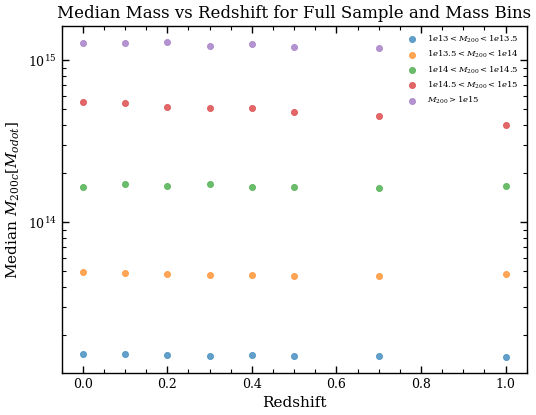

In [17]:
#see how median mass changes with redshift for the full sample and for the 5 mass bins (should be relatively flat since we are binning by mass, but good to check)
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np
redshifts = []
median_mass_full_sample = []
median_mass_mass_bins = [[] for _ in range(len(mass_bin_labels))]

for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
    redshifts.append(snapshot[1])
    
    # Full sample median mass
    all_masses = []
    for mass_bin in mass_bins:
        for gg in mass_bin.getAllGalaxyGroups():
            all_masses.append(gg.getMCrit200())
    if len(all_masses) > 0:
        median_mass_full_sample.append(float(np.median(all_masses)))
    else:        
        median_mass_full_sample.append(np.nan)
    # Mass bin median masses
    for i, mass_bin in enumerate(mass_bins):
        masses = [gg.getMCrit200() for gg in mass_bin.getAllGalaxyGroups()]
        if len(masses) > 0:
            median_mass_mass_bins[i].append(float(np.median(masses)))
        else:
            median_mass_mass_bins[i].append(np.nan)
mass_bin_median_mass_plotter = AstroPlotter()
mass_bin_median_mass_fig, mass_bin_median_mass_ax = mass_bin_median_mass_plotter.create_figure()
# mass_bin_median_mass_ax.plot(
#     redshifts,
#     median_mass_full_sample,
#     label='Median Mass, Full Sample',
#     marker='o',
#     linestyle='-',
#     linewidth=1,
#     markersize=3,
# )
for i in range(len(mass_bin_labels)):
    mass_bin_median_mass_plotter.scatter_plot(
        redshifts,
        median_mass_mass_bins[i],
        label=f'{mass_bin_labels[i]}',
        ax = mass_bin_median_mass_ax
    )
mass_bin_median_mass_ax.set_xlabel('Redshift')
mass_bin_median_mass_ax.set_ylabel('Median $M_{200c} [M_{odot}]$')#[log M_sun]')
mass_bin_median_mass_ax.set_title('Median Mass vs Redshift for Full Sample and Mass Bins')
mass_bin_median_mass_ax.legend(fontsize=6)
mass_bin_median_mass_ax.set_yscale('log')
mass_bin_median_mass_plotter.save_figure(
    mass_bin_median_mass_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/median_mass_vs_redshift_for_full_sample_and_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

Processing snapshot 99...
0
Processing snapshot 91...
0.1
Processing snapshot 84...
0.2
Processing snapshot 78...
0.3
Processing snapshot 72...
0.4
Processing snapshot 67...
0.5
Processing snapshot 59...
0.7
Processing snapshot 50...
1.0


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/median_number_of_members_vs_redshift_for_full_sample_and_mass_bins_TNG300-1, TNG-Cluster


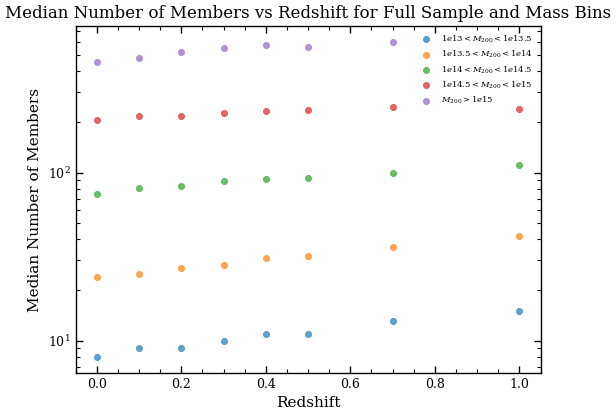

In [18]:
# plot number of members in the clusters across redshift for the full sample and for the 5 mass bins
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np
redshifts = []
median_num_members_full_sample = []
median_num_members_mass_bins = [[] for _ in range(len(mass_bin_labels))]

for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
    print(galaxyAnalysisSnapshot.snapshot_dic[snapshot[0]][0])
    redshifts.append(snapshot[1])
    
    # Full sample median number of members
    all_num_members = []
    for mass_bin in mass_bins:
        for gg in mass_bin.getAllGalaxyGroups():
            all_num_members.append(len(gg.getSatelliteSubhalos()))
    if len(all_num_members) > 0:
        median_num_members_full_sample.append(float(np.median(all_num_members)))
    else:
        median_num_members_full_sample.append(np.nan)
    
    # Mass bin median number of members
    for i, mass_bin in enumerate(mass_bins):
        num_members = [len(gg.getSatelliteSubhalos()) for gg in mass_bin.getAllGalaxyGroups()]
        if len(num_members) > 0:
            median_num_members_mass_bins[i].append(float(np.median(num_members)))
        else:
            median_num_members_mass_bins[i].append(np.nan)
            
mass_bin_median_num_members_plotter = AstroPlotter()
mass_bin_median_num_members_fig, mass_bin_median_num_members_ax = mass_bin_median_num_members_plotter.create_figure()
# mass_bin_median_num_members_ax.plot(
#     redshifts,
#     median_num_members_full_sample,
#     label='Median Number of Members, Full Sample',
#     marker='o',
#     linestyle='-',
#     linewidth=1,
#     markersize=3,
# )
for i in range(len(mass_bin_labels)):
    mass_bin_median_num_members_plotter.scatter_plot(
        redshifts,
        median_num_members_mass_bins[i],
        label=f'{mass_bin_labels[i]}',
        ax=mass_bin_median_num_members_ax
    )
mass_bin_median_num_members_ax.set_xlabel('Redshift')
mass_bin_median_num_members_ax.set_ylabel('Median Number of Members')
mass_bin_median_num_members_ax.set_title('Median Number of Members vs Redshift for Full Sample and Mass Bins')
mass_bin_median_num_members_ax.legend(fontsize=6)
mass_bin_median_num_members_ax.set_yscale('log')
mass_bin_median_num_members_plotter.save_figure(
    mass_bin_median_num_members_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/median_number_of_members_vs_redshift_for_full_sample_and_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

## single polar piecewise plots

Processed group with M_200c = 1008248471683072.0 and 600 members
Processed group with M_200c = 1008924056616960.0 and 750 members
Fraction of MRL values below the 99th percentile of random MRL values: 0.0000 (0/3)2 with 751 satellites
Fraction of MRL values below the 99th percentile of random MRL values: 0.6667 (2/3)2 with 751 satellites
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p5/plots/combinedTNG300-1_TNGCluster/polar_difference_and_MRL_stats_for_1e15_mass_bin_snapshot_67_TNG300-1, TNG-Cluster


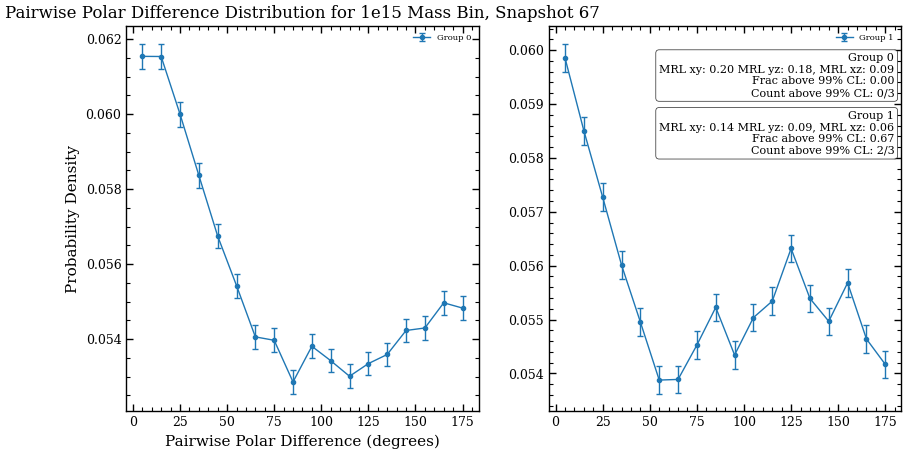

In [40]:
#make p(delta phi) plots for the 1e15 mass bin in snapshot 67
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
import numpy as np
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(67)
mass_bin = galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups
list_mass_1e15_polar_differences = []
for gg in mass_bin.getAllGalaxyGroups():
    list_mass_1e15_polar_differences.append(ListGalaxyGroup._compute_pairwise_for_group(gg))
    print(f"Processed group with M_200c = {gg.getMCrit200()} and {len(gg.getSatelliteSubhalos())} members")
    
list_mass_1e15_counts, list_mass_1e15_bin_centers, list_mass_1e15_errorbars = [], [], []
for polar_differences in list_mass_1e15_polar_differences:
     counts, bin_edges, errorbars = ListGalaxyGroup.get_histogram_bins(polar_differences, bins=np.arange(0, 185, 10), errorbarType='poisson', normalize_to_one=True)
     list_mass_1e15_counts.append(counts)
     list_mass_1e15_bin_centers.append(bin_edges)
     list_mass_1e15_errorbars.append(errorbars)
     
polarDifference_1e15_plotter = AstroPlotter()
polarDifference_1e15_fig, polarDifference_1e15_ax = polarDifference_1e15_plotter.create_figure(ncols=2, nrows=1, figsize=(10, 5))
for i, polar_differences in enumerate(list_mass_1e15_polar_differences):
    polarDifference_1e15_ax[i].errorbar(
        list_mass_1e15_bin_centers[i],
        list_mass_1e15_counts[i],
        yerr=list_mass_1e15_errorbars[i],
        label=f'Group {i}',
        marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )
polarDifference_1e15_ax[0].set_xlabel('Pairwise Polar Difference (degrees)')
polarDifference_1e15_ax[0].set_ylabel('Probability Density')
polarDifference_1e15_ax[0].set_title('Pairwise Polar Difference Distribution for 1e15 Mass Bin, Snapshot 67')
polarDifference_1e15_ax[0].legend(fontsize=6)

#include MRL value and MRL fraction above 99% random MRL CL for each group in the 1e15 mass bin in snapshot 67 as a text box
for i, gg in enumerate(mass_bin.getAllGalaxyGroups()):
    MRL_value = ListGalaxyGroup._compute_MRL_for_group(gg)
    random_MRL_values = mass_bin.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=100000)
    (MRL_fraction_above_99_CL, counts_above_99_CL, total_count, subhaloIndexInconsistentWithRandom), MRL_values, random_MRL_values = GalaxyAnalysis.getPercentOfClustersAboveRandomMRLCL(MRL_values = MRL_value, percentageMRL=99, random_mrl_values=random_MRL_values)
    
    textstr = f'Group {i}\nMRL xy: {MRL_value[0]:.2f} MRL yz: {MRL_value[1]:.2f}, MRL xz: {MRL_value[2]:.2f}\nFrac above 99% CL: {MRL_fraction_above_99_CL:.2f}\nCount above 99% CL: {counts_above_99_CL}/{total_count}'
    # place all group boxes on the right side of the second subplot, stacked vertically, right-aligned
    polarDifference_1e15_ax[1].text(
        0.98,
        0.93 - i * 0.15,
        textstr,
        transform=polarDifference_1e15_ax[1].transAxes,
        fontsize=8,
        ha='right',
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
    )
# polarDifference_1e15_ax[1].axis('off')
# polarDifference_1e15_ax[1].set_title('MRL and Fraction Above 99% CL for Each Group in 1e15 Mass Bin, Snapshot 67')
polarDifference_1e15_ax[1].legend(fontsize=6)
polarDifference_1e15_plotter.save_figure(
    polarDifference_1e15_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/polar_difference_and_MRL_stats_for_1e15_mass_bin_snapshot_67_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

Processed group with M_200c = 494967835328512.0 and 632 members
Processed group with M_200c = 468957177839616.0 and 555 members
Processed group with M_200c = 319796923072512.0 and 448 members
Processed group with M_200c = 331614995349504.0 and 361 members
Fraction of MRL values below the 99th percentile of random MRL values: 0.3333 (1/3)4 with 362 satellites
Fraction of MRL values below the 99th percentile of random MRL values: 0.3333 (1/3)4 with 362 satellites
Fraction of MRL values below the 99th percentile of random MRL values: 0.3333 (1/3)4 with 362 satellites
Fraction of MRL values below the 99th percentile of random MRL values: 1.0000 (3/3)4 with 362 satellites
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/polar_difference_and_MRL_stats_for_1e14.5-1e15_mass_bin_snapshot_50_TNG300-1, TNG-Cluster


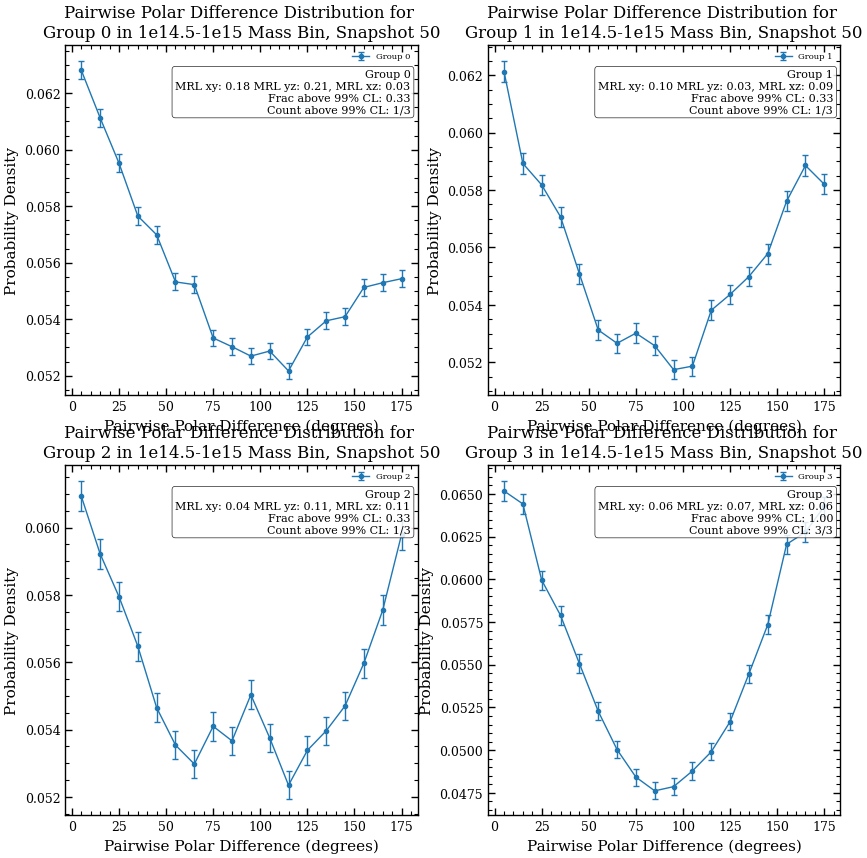

In [48]:
#do the same for the 4 1e14.5-1e15 at snapshot 50
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(50)
mass_bin = galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups
list_mass_14p5_15_polar_differences = []
for gg in mass_bin.getAllGalaxyGroups():
    list_mass_14p5_15_polar_differences.append(ListGalaxyGroup._compute_pairwise_for_group(gg))
    print(f"Processed group with M_200c = {gg.getMCrit200()} and {len(gg.getSatelliteSubhalos())} members")
list_mass_14p5_15_counts, list_mass_14p5_15_bin_centers, list_mass_14p5_15_errorbars = [], [], []
for polar_differences in list_mass_14p5_15_polar_differences:
     counts, bin_edges, errorbars = ListGalaxyGroup.get_histogram_bins(polar_differences, bins=np.arange(0, 185, 10), errorbarType='poisson', normalize_to_one=True)
     list_mass_14p5_15_counts.append(counts)
     list_mass_14p5_15_bin_centers.append(bin_edges)
     list_mass_14p5_15_errorbars.append(errorbars)
polarDifference_14p5_15_plotter = AstroPlotter()
polarDifference_14p5_15_fig, polarDifference_14p5_15_ax = polarDifference_14p5_15_plotter.create_figure(ncols=2, nrows=2, figsize=(10, 10))
for i, polar_differences in enumerate(list_mass_14p5_15_polar_differences):
    polarDifference_14p5_15_ax[i//2, i%2].errorbar(
        list_mass_14p5_15_bin_centers[i],
        list_mass_14p5_15_counts[i],
        yerr=list_mass_14p5_15_errorbars[i],
        label=f'Group {i}',
        marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )
    MRL_value = ListGalaxyGroup._compute_MRL_for_group(mass_bin.getAllGalaxyGroups()[i])
    random_MRL_values = mass_bin.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=100000)
    (MRL_fraction_above_99_CL, counts_above_99_CL, total_count, subhaloIndexInconsistentWithRandom), MRL_values, random_MRL_values = GalaxyAnalysis.getPercentOfClustersAboveRandomMRLCL(MRL_values = MRL_value, percentageMRL=99, random_mrl_values=random_MRL_values)
    
    textstr = f'Group {i}\nMRL xy: {MRL_value[0]:.2f} MRL yz: {MRL_value[1]:.2f}, MRL xz: {MRL_value[2]:.2f}\nFrac above 99% CL: {MRL_fraction_above_99_CL:.2f}\nCount above 99% CL: {counts_above_99_CL}/{total_count}'
    # place all group boxes on the right side of the second subplot, stacked vertically, right-aligned
    polarDifference_14p5_15_ax[i//2, i%2].text(
        0.98,
        0.93,
        textstr,
        transform=polarDifference_14p5_15_ax[i//2, i%2].transAxes,
        fontsize=8,
        ha='right',
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
    )
    polarDifference_14p5_15_ax[i//2, i%2].set_xlabel('Pairwise Polar Difference (degrees)')
    polarDifference_14p5_15_ax[i//2, i%2].set_ylabel('Probability Density')
    polarDifference_14p5_15_ax[i//2, i%2].set_title(f'Pairwise Polar Difference Distribution for \nGroup {i} in 1e14.5-1e15 Mass Bin, Snapshot 50')
    polarDifference_14p5_15_ax[i//2, i%2].legend(fontsize=6)
polarDifference_14p5_15_plotter.save_figure(
    polarDifference_14p5_15_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/polar_difference_and_MRL_stats_for_1e14.5-1e15_mass_bin_snapshot_50_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

# compile plots

Processing snapshot 99...
Total Galaxy Groups to process: 4084 with pairs : 20282142
Progress: Processing Galaxy Group ID 9956048, 4084 / 40844Processing snapshot 84...
Total Galaxy Groups to process: 3995 with pairs : 16325192
Progress: Processing Galaxy Group ID 10118255, 3995 / 3995Processing snapshot 67...
Total Galaxy Groups to process: 3613 with pairs : 11506319
Progress: Processing Galaxy Group ID 9677312, 3613 / 36133Processing snapshot 50...
Total Galaxy Groups to process: 2727 with pairs : 4963258
Progress: Processing Galaxy Group ID 9381209, 2727 / 27277

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/polar_pairwise_difference_overlay_across_4_redshift_TNG300-1, TNG-Cluster


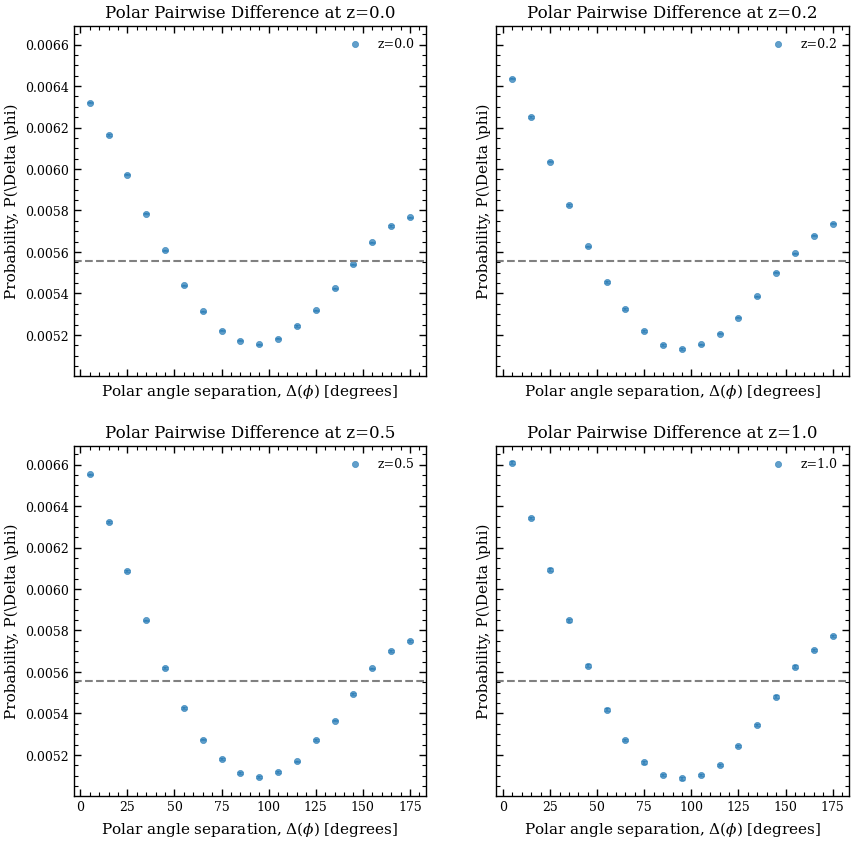

In [42]:
# make four panel plot with the following:
# - top left: overall polar pairwise difference at z = 0
# - top right: overlay polar pairwise differences for z=0.2, 
# - bottom left: polar pairwise differences for z=0.5
# - bottom right: polar pairwise differences for z=1.0

pairwise_bins = np.arange(0, 180 + 10, 10)  # 5 degree bins from 0 to 180

polar_pairwise_differences_list_redshift, polar_pairwise_differences_bin_centers_list_redshift, polar_pairwise_differences_err_list_redshift = [], [], []
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] not in [99, 84, 67, 50]: #only do the 4 redshifts we want to plot
        continue #skip other redshifts
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    list_polar_pairwise_difference_z0 = galaxyAnalysisSnapshot.loaded_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences()
    polar_pairwise_difference_z0, polar_pairwise_difference_z0_bin_centers, polar_pairwise_difference_z0_err = ListGalaxyGroup.get_histogram_bins(list_polar_pairwise_difference_z0, pairwise_bins, errorbarType='poisson', density=True,)
    
    polar_pairwise_differences_list_redshift.append(polar_pairwise_difference_z0)
    polar_pairwise_differences_bin_centers_list_redshift.append(polar_pairwise_difference_z0_bin_centers)
    polar_pairwise_differences_err_list_redshift.append(polar_pairwise_difference_z0_err)

polar_pairwise_difference_overlay_plotter = AstroPlotter()
polar_pairwise_difference_overlay_fig, polar_pairwise_difference_overlay_ax = polar_pairwise_difference_overlay_plotter.create_figure(ncols=2, nrows=2, figsize=(10, 10), sharex=True, sharey=True)
redshift_labels = [0.0, 0.2, 0.5, 1.0]
for i in range(len(polar_pairwise_differences_list_redshift)):
    polar_pairwise_difference_overlay_plotter.scatter_plot(
        polar_pairwise_differences_bin_centers_list_redshift[i],
        polar_pairwise_differences_list_redshift[i],
        errorBars=polar_pairwise_differences_err_list_redshift[i],
        label=f'z={redshift_labels[i]}',
        ax=polar_pairwise_difference_overlay_ax[i//2, i%2],
    )
    polar_pairwise_difference_overlay_ax[i//2, i%2].set_xlabel(f"{polarXlabel}")
    polar_pairwise_difference_overlay_ax[i//2, i%2].set_ylabel(polarYlabel)
    polar_pairwise_difference_overlay_ax[i//2, i%2].set_title(f'Polar Pairwise Difference at z={redshift_labels[i]}')
    polar_pairwise_difference_overlay_ax[i//2, i%2].legend()

    #make random distribution line at 1/180 on across the y axis
    polar_pairwise_difference_overlay_ax[i//2, i%2].axhline(1/180, color='gray', linestyle='--')#, label='Random Distribution (1/180)')

    #make ax have tick marks at every 10 degrees
    polar_pairwise_difference_overlay_ax[i//2, i%2].set_xticks(pairwise_bins)

polar_pairwise_difference_overlay_plotter.save_figure(
    polar_pairwise_difference_overlay_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/polar_pairwise_difference_overlay_across_4_redshift_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)


Processing snapshot 99...
Processing snapshot 84...xy Group 632 / 632 with 428 satellites Galaxy Group 632 / 632 with 428 satellites
Processing snapshot 67...xy Group 577 / 577 with 374 satellites Galaxy Group 577 / 577 with 374 satellites
Processing snapshot 50...xy Group 493 / 493 with 201 satellites Galaxy Group 493 / 493 with 201 satellites
len: (20, 20, 20)ing Galaxy Group 312 / 312 with 191 satellites Galaxy Group 312 / 312 with 191 satellites
len: (20, 20, 20)
len: (20, 20, 20)
len: (20, 20, 20)


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/mrl_distribution_at_99_CL_overlay_for_redshifts_TNG300-1, TNG-Cluster


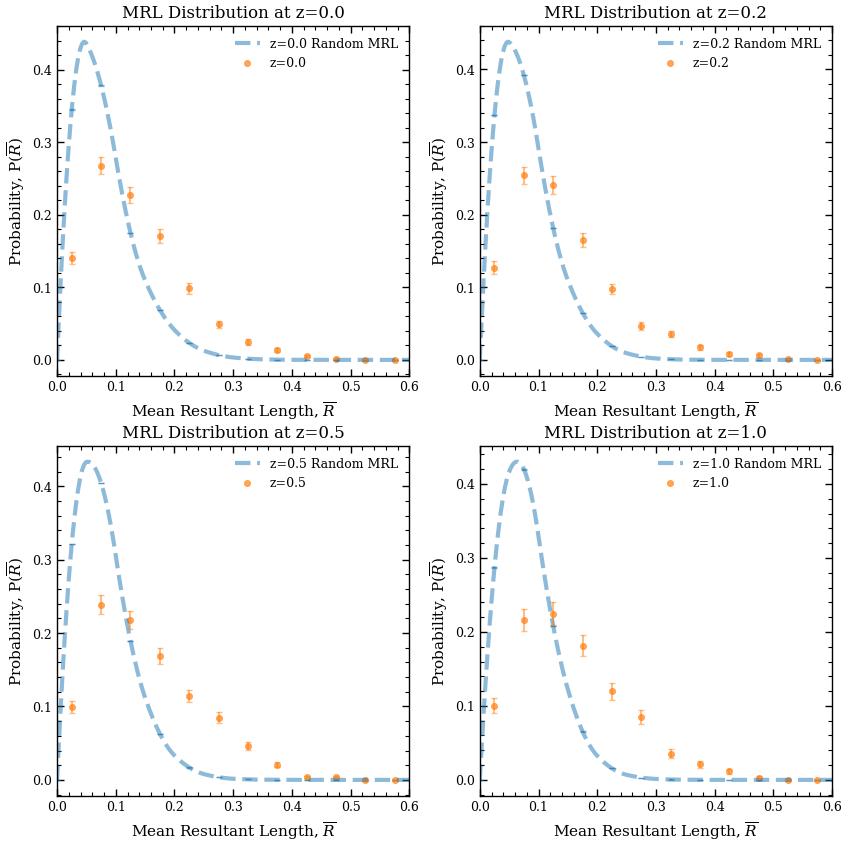

In [25]:
# make four panel plot with the following for MRL distribution at 99% CL:
# - top left: z=0 MRL distribution for the full sample
# - top right: z=0.2
# - bottom left: z=0.5
# - bottom right: z=1.0

MRL_values_list_redshift, MRL_bin_centers_list_redshift, MRL_errors_list_redshift = [], [], []
random_MRL_values_list_redshift, random_MRL_bin_centers_list_redshift, random_MRL_errors_list_redshift = [], [], []
mrl_bins = np.arange(0, 1.05, 0.05)  # 5% bins from 0 to 1
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] not in [99, 84, 67, 50]: #only do the 4 redshifts we want to plot
        continue #skip other redshifts
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    random_MRL_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=1000)
    
    random_MRL_values_binned, random_MRL_bin_centers, random_MRL_errors = ListGalaxyGroup.get_histogram_bins(random_MRL_values, bins=mrl_bins, errorbarType='poisson', normalize_to_one=True)

    
    # Add a (0, 0) point for spline fit to pass through origin
    random_MRL_bin_centers = np.concatenate([[0], random_MRL_bin_centers])
    random_MRL_values_binned = np.concatenate([[0], random_MRL_values_binned])
    random_MRL_errors = np.concatenate([[0], random_MRL_errors])

    random_MRL_values_list_redshift.append(random_MRL_values_binned)
    random_MRL_bin_centers_list_redshift.append(random_MRL_bin_centers)
    random_MRL_errors_list_redshift.append(random_MRL_errors)
    
    mrl_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_probablity_distribution_of_MRL_directionality(parallelize=False)
    MRL_values_binned, MRL_bin_centers, MRL_errors = ListGalaxyGroup.get_histogram_bins(mrl_values, bins=mrl_bins, errorbarType='poisson', normalize_to_one=True)
    
    MRL_values_list_redshift.append(MRL_values_binned)
    MRL_bin_centers_list_redshift.append(MRL_bin_centers)
    MRL_errors_list_redshift.append(MRL_errors)
    
MRL_distribution_overlay_plotter = AstroPlotter()
MRL_distribution_overlay_fig, MRL_distribution_overlay_ax = MRL_distribution_overlay_plotter.create_figure(ncols=2, nrows=2, figsize=(10, 10))
redshift_labels = [0.0, 0.2, 0.5, 1.0]
for i in range(len(MRL_values_list_redshift)):
    print(f"len: {len(MRL_bin_centers_list_redshift[i]), len(MRL_values_list_redshift[i]), len(MRL_errors_list_redshift[i])}")
    MRL_distribution_overlay_plotter.scatter_plot(
        random_MRL_bin_centers_list_redshift[i],
        random_MRL_values_list_redshift[i],
        errorBars=random_MRL_errors_list_redshift[i],
        label=f'z={redshift_labels[i]} Random MRL',
        ax=MRL_distribution_overlay_ax[i//2, i%2],
        spline_curvature=True,
        alpha=0,
        spline_smoothing=0
    )
        
    MRL_distribution_overlay_plotter.scatter_plot(
        MRL_bin_centers_list_redshift[i],
        MRL_values_list_redshift[i],
        errorBars=MRL_errors_list_redshift[i],
        label=f'z={redshift_labels[i]}',
        ax=MRL_distribution_overlay_ax[i//2, i%2],
    )
    MRL_distribution_overlay_ax[i//2, i%2].set_xlabel(mrlXlabel)
    MRL_distribution_overlay_ax[i//2, i%2].set_ylabel(mrlYlabel)
    MRL_distribution_overlay_ax[i//2, i%2].set_title(f'MRL Distribution at z={redshift_labels[i]}')
    MRL_distribution_overlay_ax[i//2, i%2].legend()

    MRL_distribution_overlay_ax[i//2, i%2].set_xlim(0, 0.6)
MRL_distribution_overlay_plotter.save_figure(
    MRL_distribution_overlay_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/mrl_distribution_at_99_CL_overlay_for_redshifts_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

Processing snapshot 99...
Total Galaxy Groups to process: 301 with pairs : 18514495
Progress: Processing Galaxy Group ID 9956048, 301 / 3011Total Galaxy Groups to process: 3470 with pairs : 490697
Progress: Processing Galaxy Group ID 999, 3470 / 34700Processing snapshot 84...
Total Galaxy Groups to process: 262 with pairs : 14323724
Progress: Processing Galaxy Group ID 10118255, 262 / 262Total Galaxy Groups to process: 3388 with pairs : 529202
Progress: Processing Galaxy Group ID 19733768, 3388 / 3388Processing snapshot 67...
Total Galaxy Groups to process: 217 with pairs : 9444811
Progress: Processing Galaxy Group ID 9677312, 217 / 2177Total Galaxy Groups to process: 3032 with pairs : 583889
Progress: Processing Galaxy Group ID 20137649, 3032 / 3032Processing snapshot 50...
Total Galaxy Groups to process: 110 with pairs : 2955455
Progress: Processing Galaxy Group ID 9381209, 110 / 110Total Galaxy Groups to process: 2242 with pairs : 542661
Progress: Processing Galaxy Group ID 8662185,

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/polar_pairwise_difference_overlay_gt150_lt50_for_redshifts_TNG300-1, TNG-Cluster


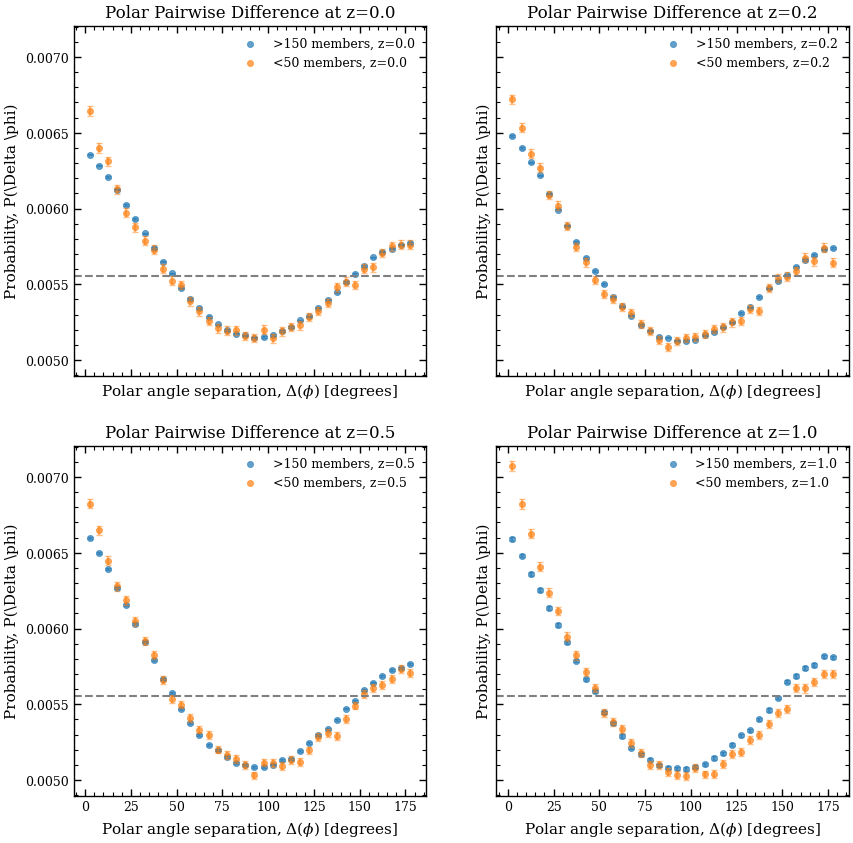

In [38]:
# make four panel plot with the following for overlay polar difference of member gt150 lt50
# - top right: z=0
# - top left: z= 0.2
# - bottom left: z=0.5
# - bottom right: z=1.0

pairwise_bins = np.arange(0, 180 + 5, 5)  # 5 degree bins from 0 to 180

polar_pairwise_gt150_list_redshift, polar_pairwise_gt150_bin_centers_list_redshift, polar_pairwise_gt150_err_list_redshift = [], [], []
polar_pairwise_lt50_list_redshift, polar_pairwise_lt50_bin_centers_list_redshift, polar_pairwise_lt50_err_list_redshift = [], [], []
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] not in [99, 84, 67, 50]: #only do the 4 redshifts we want to plot
        continue #skip other redshifts
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    list_galaxy_groups_gt150 = galaxyAnalysisSnapshot.loaded_list_of_galaxy_groups.getFilterSubhalos(minNumGalaxies=150)
    list_galaxy_groups_lt50 = galaxyAnalysisSnapshot.loaded_list_of_galaxy_groups.getFilterSubhalos(maxNumGalaxies=50)
    
    polarRawValues_gt150 = list_galaxy_groups_gt150.compute_probablity_distribution_of_polar_differences()
    polar_pairwise_gt150, polar_pairwise_gt150_bin_centers, polar_pairwise_gt150_err = ListGalaxyGroup.get_histogram_bins(polarRawValues_gt150, pairwise_bins, errorbarType='poisson', density=True)
    
    polarRawValues_lt50 = list_galaxy_groups_lt50.compute_probablity_distribution_of_polar_differences()
    polar_pairwise_lt50, polar_pairwise_lt50_bin_centers, polar_pairwise_lt50_err = ListGalaxyGroup.get_histogram_bins(polarRawValues_lt50, pairwise_bins, errorbarType='poisson', density=True)
    
    polar_pairwise_gt150_list_redshift.append(polar_pairwise_gt150)
    polar_pairwise_gt150_bin_centers_list_redshift.append(polar_pairwise_gt150_bin_centers)
    polar_pairwise_gt150_err_list_redshift.append(polar_pairwise_gt150_err)
    
    polar_pairwise_lt50_list_redshift.append(polar_pairwise_lt50)
    polar_pairwise_lt50_bin_centers_list_redshift.append(polar_pairwise_lt50_bin_centers)
    polar_pairwise_lt50_err_list_redshift.append(polar_pairwise_lt50_err)
    
polar_pairwise_overlay_plotter = AstroPlotter()
polar_pairwise_overlay_fig, polar_pairwise_overlay_ax = polar_pairwise_overlay_plotter.create_figure(ncols=2, nrows=2, figsize=(10, 10), sharex=True, sharey=True)
redshift_labels = [0.0, 0.2, 0.5, 1.0]
for i in range(len(polar_pairwise_gt150_list_redshift)):
    polar_pairwise_overlay_plotter.scatter_plot(
        polar_pairwise_gt150_bin_centers_list_redshift[i],
        polar_pairwise_gt150_list_redshift[i],
        errorBars=polar_pairwise_gt150_err_list_redshift[i],
        label=f'>150 members, z={redshift_labels[i]}',
        ax=polar_pairwise_overlay_ax[i//2, i%2]
    )
    polar_pairwise_overlay_plotter.scatter_plot(
        polar_pairwise_lt50_bin_centers_list_redshift[i],
        polar_pairwise_lt50_list_redshift[i],
        errorBars=polar_pairwise_lt50_err_list_redshift[i],
        label=f'<50 members, z={redshift_labels[i]}',
        ax=polar_pairwise_overlay_ax[i//2, i%2]
    )
    polar_pairwise_overlay_ax[i//2, i%2].set_xlabel(polarXlabel)
    polar_pairwise_overlay_ax[i//2, i%2].set_ylabel(polarYlabel)
    polar_pairwise_overlay_ax[i//2, i%2].set_title(f'Polar Pairwise Difference at z={redshift_labels[i]}')
    polar_pairwise_overlay_ax[i//2, i%2].legend()

    #make random distribution line at 1/180 on across the y axis
    polar_pairwise_overlay_ax[i//2, i%2].axhline(1/180, color='gray', linestyle='--')#, label='Random Distribution (1/180)')

    
polar_pairwise_overlay_plotter.save_figure(
    polar_pairwise_overlay_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/polar_pairwise_difference_overlay_gt150_lt50_for_redshifts_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

Processing snapshot 99...
Total Galaxy Groups to process: 3889 with pairs : 2874759
Progress: Processing Galaxy Group ID 9956048, 3889 / 38899Total Galaxy Groups to process: 3821 with pairs : 1510175
Progress: Processing Galaxy Group ID 9956048, 3821 / 38211Processing snapshot 84...
Total Galaxy Groups to process: 3879 with pairs : 2330174
Progress: Processing Galaxy Group ID 10118255, 3879 / 3879Total Galaxy Groups to process: 3772 with pairs : 1172585
Progress: Processing Galaxy Group ID 10118255, 3772 / 3772Processing snapshot 67...
Total Galaxy Groups to process: 3545 with pairs : 1633326
Progress: Processing Galaxy Group ID 9677312, 3545 / 35455Total Galaxy Groups to process: 3478 with pairs : 809287
Progress: Processing Galaxy Group ID 9677312, 3478 / 34788Processing snapshot 50...
Total Galaxy Groups to process: 2716 with pairs : 797017
Progress: Processing Galaxy Group ID 9381209, 2716 / 27166Total Galaxy Groups to process: 2653 with pairs : 296318
Progress: Processing Galaxy G

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/polar_pairwise_difference_overlay_gt0p65_lt0p35_for_redshifts_TNG300-1, TNG-Cluster


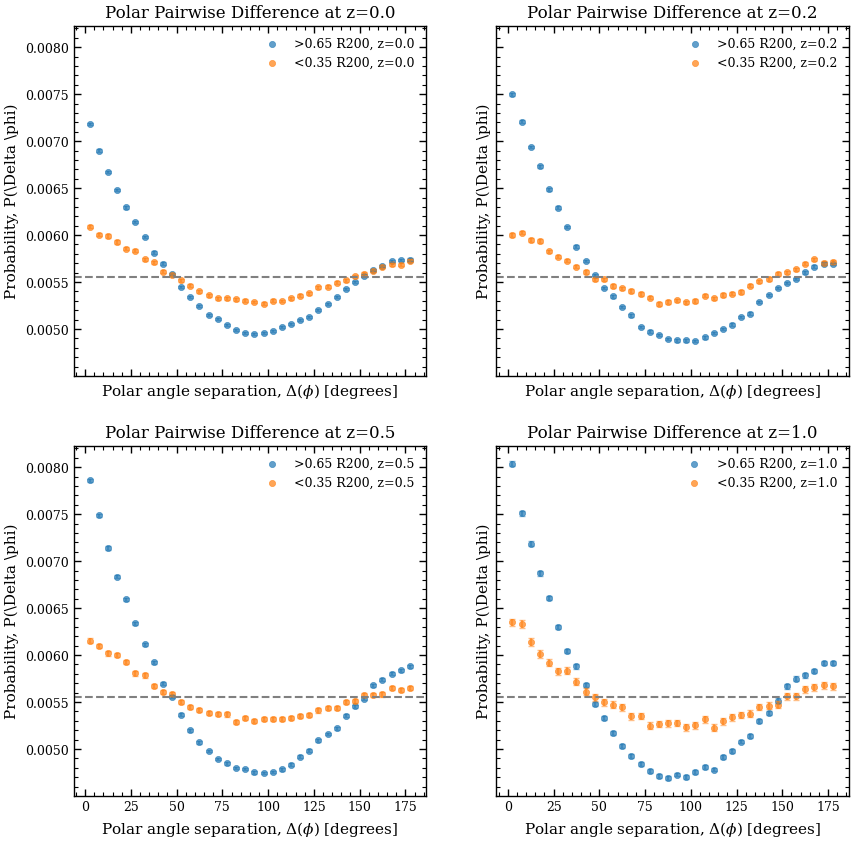

In [37]:
# make four panel plot with the following for overlay polar difference of radius gt0p65 lt0p35
# - top right: z=0
# - top left: z= 0.2
# - bottom left: z=0.5
# - bottom right: z=1.0

pairwise_bins = np.arange(0, 180 + 5, 5)  # 5 degree bins from 0 to 180

polar_pairwise_gt0p65_list_redshift, polar_pairwise_gt0p65_bin_centers_list_redshift, polar_pairwise_gt0p65_err_list_redshift = [], [], []
polar_pairwise_lt0p35_list_redshift, polar_pairwise_lt0p35_bin_centers_list_redshift, polar_pairwise_lt0p35_err_list_redshift = [], [], []
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] not in [99, 84, 67, 50]: #only do the 4 redshifts we want to plot
        continue #skip other redshifts
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    list_galaxy_groups_gt0p65 = galaxyAnalysisSnapshot.loaded_list_of_galaxy_groups.getFilterSubhalos(withinXPercentR200=[0.65, 1.0])
    list_galaxy_groups_lt0p35 = galaxyAnalysisSnapshot.loaded_list_of_galaxy_groups.getFilterSubhalos(withinXPercentR200=[0.0, 0.35])
    
    polarRawValues_gt0p65 = list_galaxy_groups_gt0p65.compute_probablity_distribution_of_polar_differences()
    polar_pairwise_gt0p65, polar_pairwise_gt0p65_bin_centers, polar_pairwise_gt0p65_err = ListGalaxyGroup.get_histogram_bins(polarRawValues_gt0p65, pairwise_bins, errorbarType='poisson', density=True)#normalize_to_one=True)
    
    polarRawValues_lt0p35 = list_galaxy_groups_lt0p35.compute_probablity_distribution_of_polar_differences()
    polar_pairwise_lt0p35, polar_pairwise_lt0p35_bin_centers, polar_pairwise_lt0p35_err = ListGalaxyGroup.get_histogram_bins(polarRawValues_lt0p35, pairwise_bins, errorbarType='poisson', density=True)
    
    polar_pairwise_gt0p65_list_redshift.append(polar_pairwise_gt0p65)
    polar_pairwise_gt0p65_bin_centers_list_redshift.append(polar_pairwise_gt0p65_bin_centers)
    polar_pairwise_gt0p65_err_list_redshift.append(polar_pairwise_gt0p65_err)
    
    polar_pairwise_lt0p35_list_redshift.append(polar_pairwise_lt0p35)
    polar_pairwise_lt0p35_bin_centers_list_redshift.append(polar_pairwise_lt0p35_bin_centers)
    polar_pairwise_lt0p35_err_list_redshift.append(polar_pairwise_lt0p35_err)

polar_pairwise_overlay_plotter = AstroPlotter()
polar_pairwise_overlay_fig, polar_pairwise_overlay_ax = polar_pairwise_overlay_plotter.create_figure(ncols=2, nrows=2, figsize=(10, 10), sharex=True, sharey=True)
redshift_labels = [0.0, 0.2, 0.5, 1.0]
for i in range(len(polar_pairwise_gt0p65_list_redshift)):       
    polar_pairwise_overlay_plotter.scatter_plot(
        polar_pairwise_gt0p65_bin_centers_list_redshift[i],
        polar_pairwise_gt0p65_list_redshift[i],
        errorBars=polar_pairwise_gt0p65_err_list_redshift[i],
        label=f'>0.65 R200, z={redshift_labels[i]}',
        ax=polar_pairwise_overlay_ax[i//2, i%2]
    )
    polar_pairwise_overlay_plotter.scatter_plot(
        polar_pairwise_lt0p35_bin_centers_list_redshift[i],
        polar_pairwise_lt0p35_list_redshift[i],
        errorBars=polar_pairwise_lt0p35_err_list_redshift[i],
        label=f'<0.35 R200, z={redshift_labels[i]}',
        ax=polar_pairwise_overlay_ax[i//2, i%2]
    )
    polar_pairwise_overlay_ax[i//2, i%2].set_xlabel(polarXlabel)
    polar_pairwise_overlay_ax[i//2, i%2].set_ylabel(polarYlabel)
    polar_pairwise_overlay_ax[i//2, i%2].set_title(f'Polar Pairwise Difference at z={redshift_labels[i]}')
    polar_pairwise_overlay_ax[i//2, i%2].legend()

    #make random distribution line at 1/180 on across the y axis
    polar_pairwise_overlay_ax[i//2, i%2].axhline(1/180, color='gray', linestyle='--')#, label='Random Distribution (1/180)')
    
polar_pairwise_overlay_plotter.save_figure(
    polar_pairwise_overlay_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/polar_pairwise_difference_overlay_gt0p65_lt0p35_for_redshifts_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)


Processing snapshot 99...
Total Galaxy Groups to process: 4022 with pairs : 11909729
Progress: Processing Galaxy Group ID 9956048, 4022 / 40222Total Galaxy Groups to process: 3939 with pairs : 1186956
Progress: Processing Galaxy Group ID 9956048, 3939 / 39399Processing snapshot 84...
Total Galaxy Groups to process: 3879 with pairs : 5791380
Progress: Processing Galaxy Group ID 10118255, 3879 / 3879Total Galaxy Groups to process: 3967 with pairs : 2801168
Progress: Processing Galaxy Group ID 10118255, 3967 / 3967Processing snapshot 67...
Total Galaxy Groups to process: 3202 with pairs : 1428222
Progress: Processing Galaxy Group ID 9677312, 3202 / 32022Total Galaxy Groups to process: 3612 with pairs : 5020754
Progress: Processing Galaxy Group ID 9677312, 3612 / 36122Processing snapshot 50...
Total Galaxy Groups to process: 1651 with pairs : 84045
Progress: Processing Galaxy Group ID 9381209, 1651 / 16511Total Galaxy Groups to process: 2727 with pairs : 3897210
Progress: Processing Galaxy

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/polar_pairwise_difference_overlay_red_blue_for_redshifts_TNG300-1, TNG-Cluster


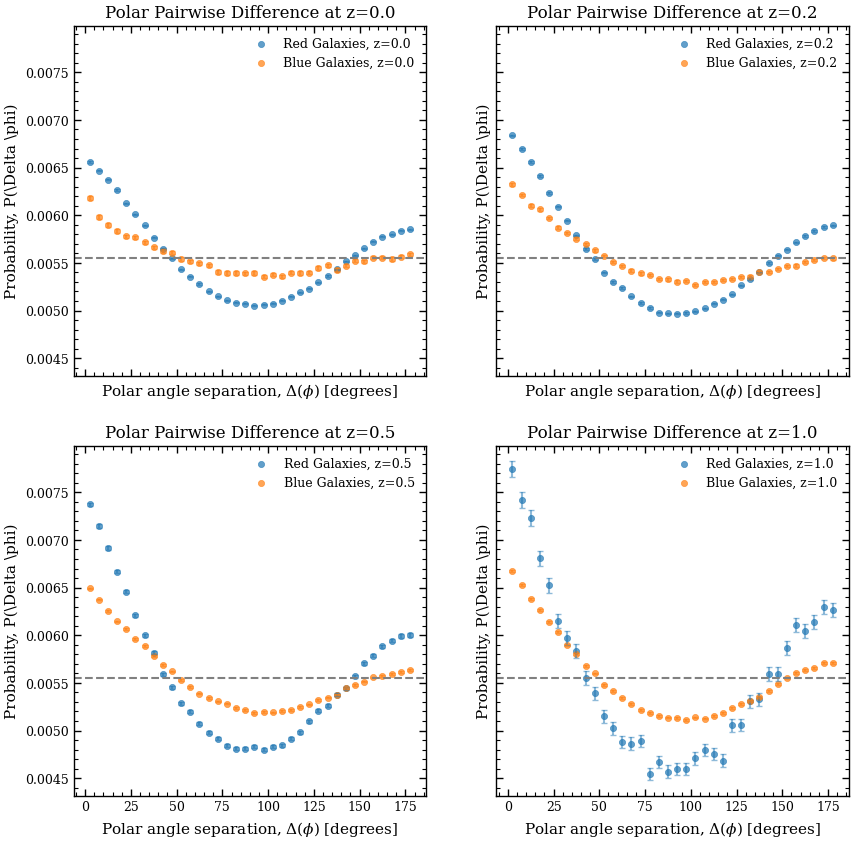

In [39]:
# make four panel plot with the following for overlay polar difference of red blue galaxies
# - top right: z=0
# - top left: z= 0.2
# - bottom left: z=0.5
# - bottom right: z=1.0

pairwise_bins = np.arange(0, 180 + 5, 5)  # 5 degree bins from 0 to 180

polar_pairwise_red_list_redshift, polar_pairwise_red_bin_centers_list_redshift, polar_pairwise_red_err_list_redshift = [], [], []
polar_pairwise_blue_list_redshift, polar_pairwise_blue_bin_centers_list_redshift, polar_pairwise_blue_err_list_redshift = [], [], []
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] not in [99, 84, 67, 50]: #only do the 4 redshifts we want to plot
        continue #skip other redshifts
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    list_galaxy_groups_red = galaxyAnalysisSnapshot.loaded_list_of_galaxy_groups.getFilterSubhalos(redDefaultGalaxies=True)
    list_galaxy_groups_blue = galaxyAnalysisSnapshot.loaded_list_of_galaxy_groups.getFilterSubhalos(blueDefaultGalaxies=True)
    
    polarRawValues_red = list_galaxy_groups_red.compute_probablity_distribution_of_polar_differences()
    polar_pairwise_red, polar_pairwise_red_bin_centers, polar_pairwise_red_err = ListGalaxyGroup.get_histogram_bins(polarRawValues_red, pairwise_bins, errorbarType='poisson', density=True)
    
    polarRawValues_blue = list_galaxy_groups_blue.compute_probablity_distribution_of_polar_differences()
    polar_pairwise_blue, polar_pairwise_blue_bin_centers, polar_pairwise_blue_err = ListGalaxyGroup.get_histogram_bins(polarRawValues_blue, pairwise_bins, errorbarType='poisson', density=True)
    
    polar_pairwise_red_list_redshift.append(polar_pairwise_red)
    polar_pairwise_red_bin_centers_list_redshift.append(polar_pairwise_red_bin_centers)
    polar_pairwise_red_err_list_redshift.append(polar_pairwise_red_err)
    
    polar_pairwise_blue_list_redshift.append(polar_pairwise_blue)
    polar_pairwise_blue_bin_centers_list_redshift.append(polar_pairwise_blue_bin_centers)
    polar_pairwise_blue_err_list_redshift.append(polar_pairwise_blue_err)
    
polar_pairwise_overlay_plotter = AstroPlotter()
polar_pairwise_overlay_fig, polar_pairwise_overlay_ax = polar_pairwise_overlay_plotter.create_figure(ncols=2, nrows=2, figsize=(10, 10), sharex=True, sharey=True)
redshift_labels = [0.0, 0.2, 0.5, 1.0]
for i in range(len(polar_pairwise_red_list_redshift)):
    polar_pairwise_overlay_plotter.scatter_plot(
        polar_pairwise_red_bin_centers_list_redshift[i],
        polar_pairwise_red_list_redshift[i],
        errorBars=polar_pairwise_red_err_list_redshift[i],
        label=f'Red Galaxies, z={redshift_labels[i]}',
        ax=polar_pairwise_overlay_ax[i//2, i%2]
    )
    polar_pairwise_overlay_plotter.scatter_plot(
        polar_pairwise_blue_bin_centers_list_redshift[i],
        polar_pairwise_blue_list_redshift[i],
        errorBars=polar_pairwise_blue_err_list_redshift[i],
        label=f'Blue Galaxies, z={redshift_labels[i]}',
        ax=polar_pairwise_overlay_ax[i//2, i%2]
    )
    polar_pairwise_overlay_ax[i//2, i%2].set_xlabel(polarXlabel)
    polar_pairwise_overlay_ax[i//2, i%2].set_ylabel(polarYlabel)
    polar_pairwise_overlay_ax[i//2, i%2].set_title(f'Polar Pairwise Difference at z={redshift_labels[i]}')
    polar_pairwise_overlay_ax[i//2, i%2].legend()

    #make random distribution line at 1/180 on across the y axis
    polar_pairwise_overlay_ax[i//2, i%2].axhline(1/180, color='gray', linestyle='--')#, label='Random Distribution (1/180)')

    
polar_pairwise_overlay_plotter.save_figure(
    polar_pairwise_overlay_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/polar_pairwise_difference_overlay_red_blue_for_redshifts_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

Total Galaxy Groups to process: 2586 with pairs : 131308
Progress: Processing Galaxy Group ID 993, 2586 / 25866Total Galaxy Groups to process: 866 with pairs : 350183
Progress: Processing Galaxy Group ID 999, 866 / 8666Total Galaxy Groups to process: 292 with pairs : 975806
Progress: Processing Galaxy Group ID 19441351, 292 / 292Total Galaxy Groups to process: 242 with pairs : 6422297
Progress: Processing Galaxy Group ID 9720881, 242 / 2422Total Galaxy Groups to process: 98 with pairs : 12402548
Progress: Processing Galaxy Group ID 9956048, 98 / 988

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/combinedTNG300-1_TNGCluster/polar_pairwise_difference_for_mass_bins_at_z0_TNG300-1, TNG-Cluster


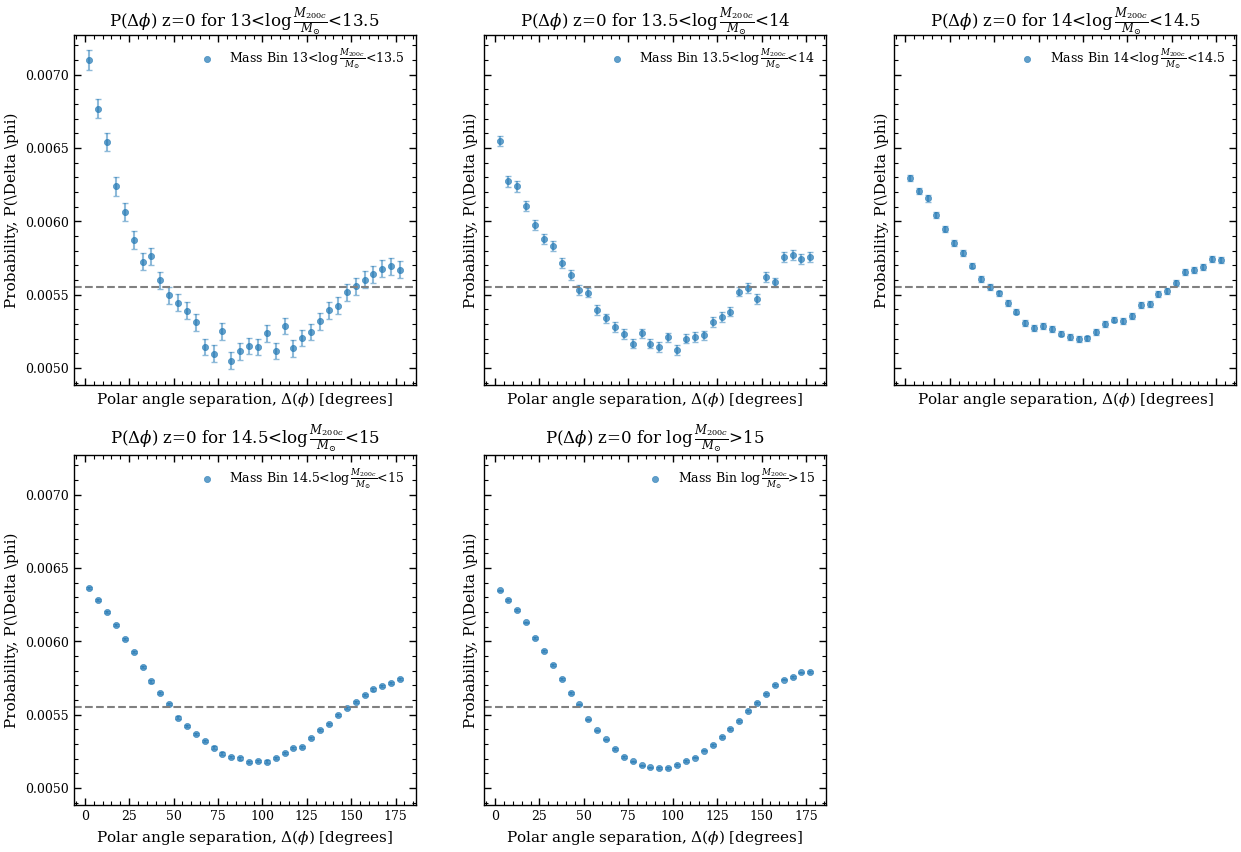

In [40]:
# make five panel plot with the following for overlay polar difference of mass bins at z=0

pairwise_bins = np.arange(0, 180 + 5, 5)  # 5 degree bins from 0 to 180
polar_pairwise_mass_bin_99, polar_pairwise_mass_bin_bin_centers_99, polar_pairwise_mass_bin_err_99 = [], [], []
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
all_mass_bins = [
    galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
]
for mass_bin in all_mass_bins:
    polarRawValues_mass_bin = mass_bin.compute_probablity_distribution_of_polar_differences()
    polar_pairwise_mass_bin, polar_pairwise_mass_bin_bin_centers, polar_pairwise_mass_bin_err = ListGalaxyGroup.get_histogram_bins(polarRawValues_mass_bin, pairwise_bins, errorbarType='poisson', density=True)
    
    polar_pairwise_mass_bin_99.append(polar_pairwise_mass_bin)
    polar_pairwise_mass_bin_bin_centers_99.append(polar_pairwise_mass_bin_bin_centers)
    polar_pairwise_mass_bin_err_99.append(polar_pairwise_mass_bin_err)

# - top left: z=0, gt13 lt13p5
# - top middle: z=0, gt13p5 lt14
# - top right: z=0, gt14 lt14p5
# - bottom left: z=0, gt14p5 lt15
# - bottom middle: z=0, gt15
# - bottom right: legend only
polar_pairwise_overlay_plotter = AstroPlotter()
polar_pairwise_overlay_fig, polar_pairwise_overlay_ax = polar_pairwise_overlay_plotter.create_figure(ncols=3, nrows=2, figsize=(15, 10), sharex=True, sharey=True)
mass_bin_labels = [f'13<{m200label}<13.5', f'13.5<{m200label}<14', f'14<{m200label}<14.5', f'14.5<{m200label}<15', f'{m200label}>15']
for i in range(len(polar_pairwise_mass_bin_99)):
    polar_pairwise_overlay_plotter.scatter_plot(
        polar_pairwise_mass_bin_bin_centers_99[i],
        polar_pairwise_mass_bin_99[i],
        errorBars=polar_pairwise_mass_bin_err_99[i],
        label=f'Mass Bin {mass_bin_labels[i]}',
        ax=polar_pairwise_overlay_ax[i//3, i%3]
    )
    polar_pairwise_overlay_ax[i//3, i%3].set_xlabel(polarXlabel)
    polar_pairwise_overlay_ax[i//3, i%3].set_ylabel(polarYlabel)
    polar_pairwise_overlay_ax[i//3, i%3].set_title(rf'P($\Delta \phi$) z=0 for {mass_bin_labels[i]}')
    polar_pairwise_overlay_ax[i//3, i%3].legend()

    #make random distribution line at 1/180 on across the y axis
    polar_pairwise_overlay_ax[i//3, i%3].axhline(1/180, color='gray', linestyle='--')#, label='Random Distribution (1/180)')
    
# Add legend to bottom right panel
polar_pairwise_overlay_ax[1, 2].axis('off')  # Hide axes
polar_pairwise_overlay_ax[1, 2].legend(
    [f'Mass Bin {label}' for label in mass_bin_labels],
    loc='center',
    fontsize=10,
)
polar_pairwise_overlay_plotter.save_figure(
    polar_pairwise_overlay_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/polar_pairwise_difference_for_mass_bins_at_z0_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

Processing snapshot 99...
Total Galaxy Groups to process: 2586 with pairs : 131308
Progress: Processing Galaxy Group ID 993, 2586 / 25866Total Galaxy Groups to process: 866 with pairs : 350183
Progress: Processing Galaxy Group ID 999, 866 / 8666Total Galaxy Groups to process: 292 with pairs : 975806
Progress: Processing Galaxy Group ID 19441351, 292 / 292Total Galaxy Groups to process: 242 with pairs : 6422297
Progress: Processing Galaxy Group ID 9720881, 242 / 2422Total Galaxy Groups to process: 98 with pairs : 12402548
Progress: Processing Galaxy Group ID 3020669, 25 / 988

Progress: Processing Galaxy Group ID 9956048, 98 / 98Processing snapshot 84...
Total Galaxy Groups to process: 2587 with pairs : 169947
Progress: Processing Galaxy Group ID 999, 2587 / 25877Total Galaxy Groups to process: 831 with pairs : 413006
Progress: Processing Galaxy Group ID 19733768, 831 / 831Total Galaxy Groups to process: 299 with pairs : 1324048
Progress: Processing Galaxy Group ID 8732471, 299 / 2999Total Galaxy Groups to process: 230 with pairs : 7260321
Progress: Processing Galaxy Group ID 10118255, 230 / 230Total Galaxy Groups to process: 48 with pairs : 7157870
Progress: Processing Galaxy Group ID 9755953, 48 / 48Processing snapshot 67...
Total Galaxy Groups to process: 2370 with pairs : 220162
Progress: Processing Galaxy Group ID 20123674, 2370 / 2370Total Galaxy Groups to process: 750 with pairs : 520049
Progress: Processing Galaxy Group ID 20137649, 750 / 750Total Galaxy Groups to process: 304 with pairs : 1718353
Progress: Processing Galaxy Group ID 8994107, 304 / 3

/home/poulin.al/.conda/envs/myenv/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


IndexError: list index out of range

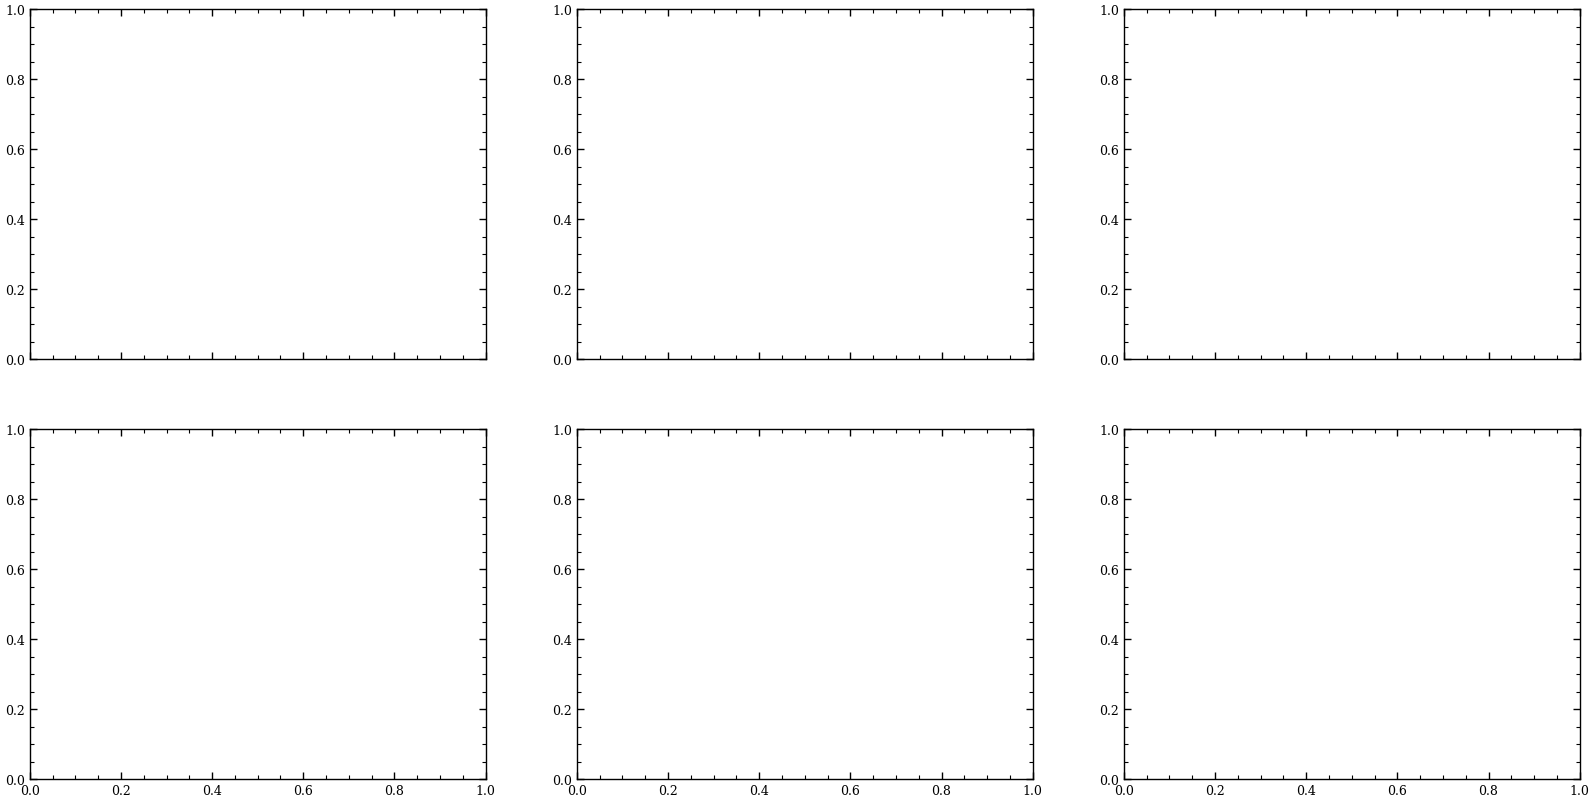

In [41]:
# make five panel plot with the following for overlay polar difference of mass bins
# - top left: z=0, gt13 lt13p5
# - top middle: z=0, gt13p5 lt14
# - top right: z=0, gt14 lt14p5
# - bottom left: z=0, gt14p5 lt15
# - bottom middle: z=0, gt15
# - bottom right: legend only
# but each plot is overlayed with the same mass bin but different redshifts to see the redshift evolution within each mass bin
#we will do 99, 84, 67, 50 for the redshifts (0, 0.2, 0.5, 1.0 respectively)
# each redshift will be slightly offset in the x direction for better visualization
pairwise_bins = np.arange(0, 180 + 5, 5)  # 5 degree bins from 0 to 180
polar_pairwise_mass_bin_list_redshift, polar_pairwise_mass_bin_bin_centers_list_redshift, polar_pairwise_mass_bin_err_list_redshift = [], [], [] #a list of redshifts where each element is a list of mass bins, where each mass bin is the polar pairwise difference for that mass bin and that redshift
redshifts_to_plot = [99, 84, 67, 50] #corresponding to [0, 0.2, 0.5, 1.0]
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] not in redshifts_to_plot: #only do the 4 redshifts we want to plot
        continue #skip other redshifts
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    all_mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
    polar_pairwise_mass_bin_for_redshift = []
    for mass_bin in all_mass_bins:
        polarRawValues_mass_bin = mass_bin.compute_probablity_distribution_of_polar_differences()
        polar_pairwise_mass_bin, polar_pairwise_mass_bin_bin_centers, polar_pairwise_mass_bin_err = ListGalaxyGroup.get_histogram_bins(polarRawValues_mass_bin, pairwise_bins, errorbarType='poisson', density=True)
        
        polar_pairwise_mass_bin_for_redshift.append((polar_pairwise_mass_bin, polar_pairwise_mass_bin_bin_centers, polar_pairwise_mass_bin_err))
    polar_pairwise_mass_bin_list_redshift.append(polar_pairwise_mass_bin_for_redshift)
    
# Now we have a list of redshifts, where each element is a list of mass bins, where each mass bin is the polar pairwise difference for that mass bin and that redshift
# We want to make a 3x2 plot, where each plot is a mass bin, and within each plot we have the polar pairwise difference for that mass bin at different redshifts that are shifted slightly in the x direction for better visualization
polar_pairwise_overlay_plotter = AstroPlotter()
polar_pairwise_overlay_fig, polar_pairwise_overlay_ax = polar_pairwise_overlay_plotter.create_figure(ncols=3, nrows=2, figsize=(20, 10), sharex=True, sharey=False)
mass_bin_labels = ['13<$M_{200c}$<13.5', '13.5<$M_{200c}$<14', '14<$M_{200c}$<14.5', '14.5<$M_{200c}$<15', '$M_{200c}$>15']
redshift_labels = [0.0, 0.2, 0.5, 1.0]
for mass_bin_index in range(len(mass_bin_labels)):
    for i, redshift_index in enumerate(redshifts_to_plot):
        polar_pairwise_mass_bin, polar_pairwise_mass_bin_bin_centers, polar_pairwise_mass_bin_err = polar_pairwise_mass_bin_list_redshift[redshift_index][mass_bin_index]

        #if all values in polar_pairwise_mass_bin are zero, skip the plot for that redshift and mass bin
        if np.all(polar_pairwise_mass_bin == 0):
            continue

        #if i == 0, plot only every other point to reduce clutter, otherwise plot all points
        if i == 0:
            polar_pairwise_mass_bin = polar_pairwise_mass_bin[::2]
            polar_pairwise_mass_bin_bin_centers = polar_pairwise_mass_bin_bin_centers[::2]
            polar_pairwise_mass_bin_err = polar_pairwise_mass_bin_err[::2]

        # Shift the x values slightly based on the redshift index for better visualization
        shifted_bin_centers = polar_pairwise_mass_bin_bin_centers + (redshift_index - 1.5) * 1.5  # Shift by up to +/- 2.25 degrees
        polar_pairwise_overlay_plotter.scatter_plot(
            shifted_bin_centers,
            polar_pairwise_mass_bin,
            errorBars=polar_pairwise_mass_bin_err,
            label=f'z={redshift_labels[redshift_index]}',
            ax=polar_pairwise_overlay_ax[mass_bin_index//3, mass_bin_index%3]
        )
    polar_pairwise_overlay_ax[mass_bin_index//3, mass_bin_index%3].set_xlabel(polarXlabel)
    polar_pairwise_overlay_ax[mass_bin_index//3, mass_bin_index%3].set_ylabel(polarYlabel)
    polar_pairwise_overlay_ax[mass_bin_index//3, mass_bin_index%3].set_title(rf'P($\Delta \phi$) for {mass_bin_labels[mass_bin_index]}')
    polar_pairwise_overlay_ax[mass_bin_index//3, mass_bin_index%3].legend()

    #make random distribution line at 1/180 on across the y axis
    polar_pairwise_overlay_ax[mass_bin_index//3, mass_bin_index%3].axhline(1/180, color='gray', linestyle='--')#, label='Random Distribution (1/180)')

# Add legend to bottom right panel
polar_pairwise_overlay_ax[1, 2].axis('off')  # Hide axes
polar_pairwise_overlay_ax[1, 2].legend(
    [f'z={label}' for label in redshift_labels],
    loc='center',
    fontsize=10,
)
polar_pairwise_overlay_plotter.save_figure(
    polar_pairwise_overlay_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/polar_pairwise_difference_for_mass_bins_across_redshifts_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

Processing snapshot 99...
Total Galaxy Groups to process: 2392 with pairs : 22894
Progress: Processing Galaxy Group ID 993, 2392 / 23922Total Galaxy Groups to process: 2325 with pairs : 15989
Total Galaxy Groups to process: 865 with pairs : 53796Progress: Processing Galaxy Group ID 1 / 866
Progress: Processing Galaxy Group ID 999, 865 / 8655Total Galaxy Groups to process: 864 with pairs : 34127
Total Galaxy Groups to process: 292 with pairs : 136226gress: Processing Galaxy Group ID 1 / 292
Progress: Processing Galaxy Group ID 19441351, 292 / 292Total Galaxy Groups to process: 292 with pairs : 84753
Total Galaxy Groups to process: 242 with pairs : 9252252Progress: Processing Galaxy Group ID 1 / 242
Progress: Processing Galaxy Group ID 9720881, 242 / 2422Total Galaxy Groups to process: 242 with pairs : 463435
Progress: Processing Galaxy Group ID 9720881, 242 / 2422Processing snapshot 84...
Total Galaxy Groups to process: 2471 with pairs : 30459
Progress: Processing Galaxy Group ID 999, 2

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/combinedTNG300-1_TNGCluster/polar_pairwise_difference_for_mass_bins_across_redshifts_separated_by_radial_bins_TNG300-1, TNG-Cluster


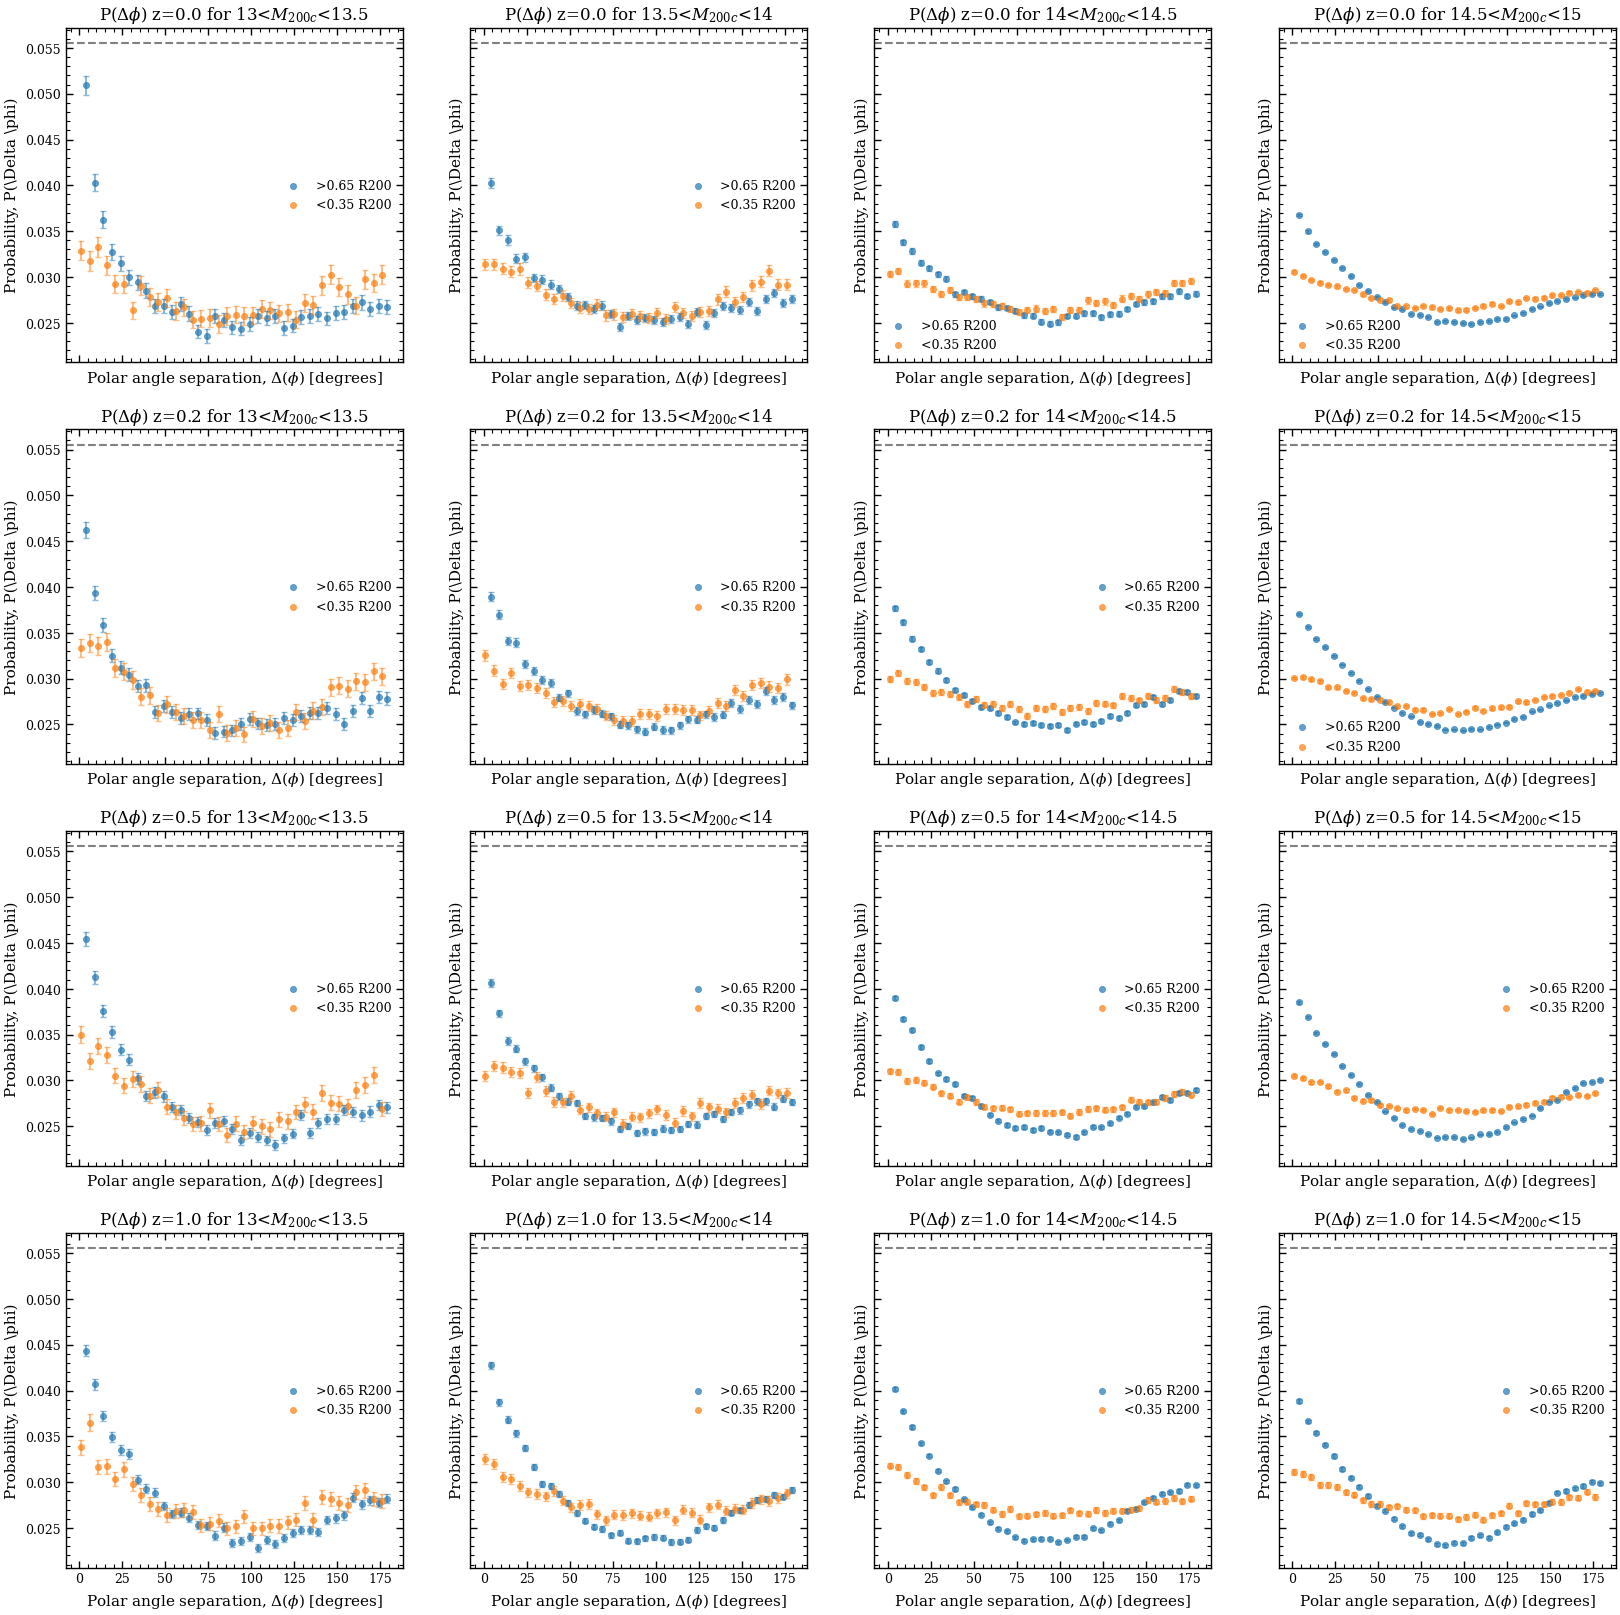

In [ ]:
#make an 4x4 panel plot. A given row is a redshift (0, 0.2, 0.5, 1.0) and a given column is a mass bin (gt13 lt13p5, gt13p5 lt14, gt14 lt14p5, gt14p5 lt15). Each panel is the polar pairwise difference distribution for that redshift and that mass bin and separating by gt65% or lt35%. We will also overlay the random distribution line at 1/180 on each plot for reference.
pairwise_bins = np.arange(0, 180 + 5, 5)  # 5 degree bins from 0 to 180
polar_pairwise_gt0p65_list_redshift_mass_bin, polar_pairwise_gt0p65_bin_centers_list_redshift_mass_bin, polar_pairwise_gt0p65_err_list_redshift_mass_bin = [], [], []
polar_pairwise_lt0p35_list_redshift_mass_bin, polar_pairwise_lt0p35_bin_centers_list_redshift_mass_bin, polar_pairwise_lt0p35_err_list_redshift_mass_bin = [], [], []
redshifts_to_plot = [99, 84, 67, 50] #corresponding to [0, 0.2, 0.5, 1.0]
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] not in redshifts_to_plot: #only do the 4 redshifts we want to plot
        continue #skip other redshifts
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    all_mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
    ]
    polar_pairwise_gt0p65_for_redshift_mass_bin = []
    polar_pairwise_lt0p35_for_redshift_mass_bin = []
    for mass_bin in all_mass_bins:
        list_galaxy_groups_gt0p65 = mass_bin.getFilterSubhalos(withinXPercentR200=[0.65, 1.0])
        list_galaxy_groups_lt0p35 = mass_bin.getFilterSubhalos(withinXPercentR200=[0.0, 0.35])
        
        polarRawValues_gt0p65 = list_galaxy_groups_gt0p65.compute_probablity_distribution_of_polar_differences()
        polar_pairwise_gt0p65, polar_pairwise_gt0p65_bin_centers, polar_pairwise_gt0p65_err = ListGalaxyGroup.get_histogram_bins(polarRawValues_gt0p65, pairwise_bins, errorbarType='poisson', density=True)
        
        polarRawValues_lt0p35 = list_galaxy_groups_lt0p35.compute_probablity_distribution_of_polar_differences()
        polar_pairwise_lt0p35, polar_pairwise_lt0p35_bin_centers, polar_pairwise_lt0p35_err = ListGalaxyGroup.get_histogram_bins(polarRawValues_lt0p35, pairwise_bins, errorbarType='poisson', density=True)
        
        polar_pairwise_gt0p65_for_redshift_mass_bin.append((polar_pairwise_gt0p65, polar_pairwise_gt0p65_bin_centers, polar_pairwise_gt0p65_err))
        polar_pairwise_lt0p35_for_redshift_mass_bin.append((polar_pairwise_lt0p35, polar_pairwise_lt0p35_bin_centers, polar_pairwise_lt0p35_err))
    polar_pairwise_gt0p65_list_redshift_mass_bin.append(polar_pairwise_gt0p65_for_redshift_mass_bin)
    polar_pairwise_lt0p35_list_redshift_mass_bin.append(polar_pairwise_lt0p35_for_redshift_mass_bin)
# Now we have a list of redshifts, where each element is a list of mass bins, where each mass bin is the polar pairwise difference for that mass bin and that redshift for gt65% and lt35% radial bins
# We want to make a 4x4 plot, where each row is a redshift and each column is a mass bin, and within each plot we have the polar pairwise difference for gt65% and lt35% radial bins
polar_pairwise_overlay_plotter = AstroPlotter()
polar_pairwise_overlay_fig, polar_pairwise_overlay_ax = polar_pairwise_overlay_plotter.create_figure(ncols=4, nrows=4, figsize=(20, 20), sharex=True, sharey=True)
mass_bin_labels = ['13<$M_{200c}$<13.5', '13.5<$M_{200c}$<14', '14<$M_{200c}$<14.5', '14.5<$M_{200c}$<15']
redshift_labels = [0.0, 0.2, 0.5, 1.0]
for redshift_index in range(len(redshifts_to_plot)):
    for mass_bin_index in range(len(mass_bin_labels)):
        polar_pairwise_gt0p65, polar_pairwise_gt0p65_bin_centers, polar_pairwise_gt0p65_err = polar_pairwise_gt0p65_list_redshift_mass_bin[redshift_index][mass_bin_index]
        polar_pairwise_lt0p35, polar_pairwise_lt0p35_bin_centers, polar_pairwise_lt0p35_err = polar_pairwise_lt0p35_list_redshift_mass_bin[redshift_index][mass_bin_index]
        # Shift the x values slightly based on the redshift index for better visualization
        shifted_bin_centers_gt0p65 = polar_pairwise_gt0p65_bin_centers + 1.5  # Shift gt65% to the right
        shifted_bin_centers_lt0p35 = polar_pairwise_lt0p35_bin_centers - 1.5  # Shift lt35% to the left
        polar_pairwise_overlay_plotter.scatter_plot(
            shifted_bin_centers_gt0p65,
            polar_pairwise_gt0p65,
            errorBars=polar_pairwise_gt0p65_err,
            label=f'>0.65 R200',
            ax=polar_pairwise_overlay_ax[redshift_index, mass_bin_index]
        )
        polar_pairwise_overlay_plotter.scatter_plot(
            shifted_bin_centers_lt0p35,
            polar_pairwise_lt0p35,
            errorBars=polar_pairwise_lt0p35_err,
            label=f'<0.35 R200',
            ax=polar_pairwise_overlay_ax[redshift_index, mass_bin_index]
        )
        polar_pairwise_overlay_ax[redshift_index, mass_bin_index].set_xlabel(polarXlabel)
        polar_pairwise_overlay_ax[redshift_index, mass_bin_index].set_ylabel(polarYlabel)
        polar_pairwise_overlay_ax[redshift_index, mass_bin_index].set_title(rf'P($\Delta \phi$) z={redshift_labels[redshift_index]} for {mass_bin_labels[mass_bin_index]}')
        polar_pairwise_overlay_ax[redshift_index, mass_bin_index].legend()

        #make random distribution line at 1/180 on across the y axis
        polar_pairwise_overlay_ax[redshift_index, mass_bin_index].axhline(1/180, color='gray', linestyle='--')#, label='Random Distribution (1/180)')

polar_pairwise_overlay_plotter.save_figure(
    polar_pairwise_overlay_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/polar_pairwise_difference_for_mass_bins_across_redshifts_separated_by_radial_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

#### do i need

In [ ]:
# make two panel plot with the following:
# - top left: fraction of clusters above random MRL CL vs redshift for 99%, 95%, 90% CL
# - top right: normalized polar pairwise difference (N(<90º) - N(>=90º)) vs redshift for full sample and mass bins

mrl_bins = np.arange(0, 1.05, 0.05)  # 5% bins from 0 to 1
CL_bins = [99, 95, 90]
mrl_cl_data_list_redshift = []
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    mrl_cl_data_redshift = []
    for cl in CL_bins:
        random_MRL_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=1000)
        (f_cl, c_cl, n_cl, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=cl, random_mrl_values=random_MRL_values)
        mrl_cl_data_redshift.append((f_cl, n_cl))
    mrl_cl_data_list_redshift.append(mrl_cl_data_redshift)
polar_pairwise_difference_norm_data_list_redshift = []
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
    full_angles = []
    for mass_bin in mass_bins:
        polarRawValues = mass_bin.compute_probablity_distribution_of_polar_differences()
        full_angles.extend(polarRawValues)
    stats_full = polar_lt90_ge90_stats_from_hist(full_angles, bin_size_deg=5.0)
    d, s = frac_diff_and_sigma(stats_full['frac_lt90'], stats_full['frac_ge90'], stats_full['total'], stats_full['n_lt90'], stats_full['n_ge90'], model=error_model)
    polar_pairwise_difference_norm_data_list_redshift.append((d, s))
two_panel_plotter = AstroPlotter()
two_panel_fig, two_panel_ax = two_panel_plotter.create_figure(ncols=2, nrows=1, figsize=(15, 5))
# Left panel: MRL CL
for i, cl in enumerate(CL_bins):
    f_cl_values = [data[i][0] for data in mrl_cl_data_list_redshift]
    n_cl_values = [data[i][1] for data in mrl_cl_data_list_redshift]
    err_cl_values = [binomial_sigma(f, n) for f, n in zip(f_cl_values, n_cl_values)]
    two_panel_ax[0].errorbar(
        redshifts,
        [1.0 - f for f in f_cl_values],
        yerr=err_cl_values,
        label=f'Fraction above random {cl}% CL',
        marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )
two_panel_ax[0].set_xlabel('Redshift')
two_panel_ax[0].set_ylabel('Fraction of MRL values above random percentile')
two_panel_ax[0].set_title('Fraction above random MRL CL vs Redshift')
two_panel_ax[0].legend(loc='upper left')
# Right panel: Polar pairwise difference normalized
d_values = [data[0] for data in polar_pairwise_difference_norm_data_list_redshift]
s_values = [data[1] for data in polar_pairwise_difference_norm_data_list_redshift]
two_panel_ax[1].errorbar(
    redshifts,
    d_values,
    yerr=s_values,
    label=f'Polar Pairwise Difference (Normalized), Full Sample [{error_model}]',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)
two_panel_ax[1].set_xlabel('Redshift')
two_panel_ax[1].set_ylabel('Fraction(<90º) - Fraction(>=90º)')
two_panel_ax[1].set_title('Normalized Polar Pairwise Difference vs Redshift')
two_panel_ax[1].legend(fontsize=6)
two_panel_plotter.save_figure(
    two_panel_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/mrl_cl_and_polar_pairwise_difference_normalized_vs_redshift_full_sample_{error_model}_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)